# E-Commerce Marketing Analytics: Portfolio Case Study

---

## Project Overview

This project is a full-stack marketing analytics case study built on a synthetic, multi-table e-commerce dataset from Kaggle.

The goal of this analysis is to demonstrate how I would approach a real-world marketing analytics problem from end to end: importing raw data, auditing data quality, preparing analysis-ready tables, joining datasets with SQL, visualizing performance trends, and translating findings into business recommendations.

Using Python, SQL, and data visualization, my analysis explores campaign performance, acquisition channels, customer behavior, funnel activity, product revenue, refunds, discounts, and A/B test outcomes to identify opportunities for stronger channel strategy, smarter campaign investment, and improved revenue performance.

<a id="back-to-top"></a>

## Table of Contents

1. [Business Questions](#business-questions)
2. [Data Import & Initial Audit](#data-import-audit)
3. [Data Cleaning & Preparation](#data-cleaning-preparation)
4. [SQLite Setup & SQL Analysis](#sqlite-setup-sql-analysis)
5. [Executive KPI Summary](#executive-kpi-summary)
6. [Campaign Performance Analysis](#campaign-performance-analysis)
7. [Channel & Acquisition Performance Analysis](#channel-acquisition-performance)
8. [Funnel Analysis](#funnel-analysis)
9. [A/B Test Analysis](#ab-test-analysis)
10. [Customer Segmentation Analysis](#customer-segmentation-analysis)
11. [Product & Category Performance Analysis](#product-category-performance)
12. [Refund & Discount Analysis](#refund-discount-analysis)
13. [Time-Series & Seasonality Analysis](#time-series-seasonality-analysis)
14. [Executive Summary & Recommendations](#executive-summary-recommendations)
15. [READ.me](#read-me)

### Dataset at a Glance

| Table | Rows | Description |
|---|---|---|
| `customers` | 100,000 | Demographics, loyalty tier, acquisition channel |
| `products` | 2,000 | Category, brand, price, premium flag |
| `events` | 2,000,000 | Clickstream: views, clicks, add-to-carts, purchases |
| `transactions` | 103,127 | Revenue, discounts, refunds, campaign attribution |
| `campaigns` | 50 | Channel, objective, expected uplift, date range |

### Tools & Libraries
- **Python** — pandas, numpy, scipy, matplotlib, seaborn
- **SQL** — SQLite (via sqlite3)
- **Visualization** — matplotlib, seaborn
- **Notebook** — Jupyter

#### *AI Usage Note*

*AI tools were used strategically during this project to support workflow efficiency, code troubleshooting, documentation structure, and refinement of analytical explanations. All analysis decisions, data interpretation, code execution, validation, and final business recommendations were reviewed and owned by me.*

---
<a id="business-questions"></a>

##  1. Business Questions

Before analyzing the data, I defined a set of business questions to guide the project and keep the analysis focused on decision-making rather than exploratory analysis alone.

These questions are designed to reflect the types of priorities a marketing, growth, or e-commerce team would care about: revenue performance, campaign efficiency, acquisition quality, funnel behavior, customer segmentation, product performance, and revenue quality.

By framing the project around these questions, the analysis can move beyond reporting metrics and focus on identifying opportunities to improve marketing investment, customer targeting, conversion performance, and overall business growth.

### Strategic Questions
1. **Revenue**: What is total revenue, and how is it trending over time?
2. **Campaigns**: Which campaigns delivered the strongest revenue impact, conversion activity, and customer engagement? 
3. **Channels**: Which acquisition channels bring the highest-value customers?
4. **Funnel**: Where are the biggest drop-offs in the purchase funnel?
5. **A/B Testing**: Did the experiment (Variant_A / Variant_B) improve conversion vs. Control?
6. **Segmentation**: Which customer segments (loyalty tier, country, age) generate the most revenue?
7. **Products**: Which categories and products are the top revenue drivers?
8. **Refunds**: Which products/campaigns have elevated refund rates?
9. **Discounts**: Are discounts driving incremental revenue, or just eroding margin?
10. **Trends**: Are there seasonal patterns, and is the business growing month-over-month?

[Back to Top](#back-to-top)


---
<a id="data-import-audit"></a>

## 2. Data Import & Initial Audit

**The Goal:**  
Understand the structure, completeness, and reliability of the five source tables before beginning analysis.

**The How:**  
I imported the customer, product, event, transaction, and campaign tables, then used a reusable audit function to review row counts, column counts, data types, null values, unique values, and duplicate records for each table.

**The Why:**  
A strong data audit helps identify issues early, such as missing values, date fields stored as text, and potential join-key problems. This step ensures that later analysis is based on data that has been reviewed, understood, and prepared intentionally.

[Back to Top](#back-to-top)

In [1]:
#  Imports 
import pandas as pd
import numpy as np
import sqlite3
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
sns.set_palette(PALETTE)
print("Libraries loaded")


Libraries loaded


In [2]:
# Load CSVs
path = '../data/raw/'

dfs = {}
table_names = ['customers', 'products', 'events', 'transactions', 'campaigns']

for name in table_names:
    dfs[name] = pd.read_csv(f'{path}{name}.csv')
    print(f"* {name:15s} → {dfs[name].shape[0]:>10,} rows × {dfs[name].shape[1]} cols")

customers    = dfs['customers']
products     = dfs['products']
events       = dfs['events']
transactions = dfs['transactions']
campaigns    = dfs['campaigns']


* customers       →    100,000 rows × 7 cols
* products        →      2,000 rows × 6 cols
* events          →  2,000,000 rows × 12 cols
* transactions    →    103,127 rows × 9 cols
* campaigns       →         50 rows × 7 cols


In [3]:
# Data audit
def audit_table(df, name):
    print(f"\n{'='*60}")
    print(f"TABLE: {name.upper()}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    print(f"{'='*60}")
    summary = pd.DataFrame({
        'dtype':      df.dtypes,
        'non_null':   df.notnull().sum(),
        'null_count': df.isnull().sum(),
        'null_%':     (df.isnull().mean() * 100).round(2),
        'nunique':    df.nunique(),
    })
    print(summary.to_string())
    print(f"Duplicate rows: {df.duplicated().sum():,}")

for name in table_names:
    audit_table(dfs[name], name)



TABLE: CUSTOMERS  (100,000 rows × 7 cols)
                      dtype  non_null  null_count  null_%  nunique
customer_id           int64    100000           0    0.00   100000
signup_date          object    100000           0    0.00     1095
country              object    100000           0    0.00        7
age                   int64    100000           0    0.00       53
gender               object    100000           0    0.00        3
loyalty_tier         object    100000           0    0.00        4
acquisition_channel  object    100000           0    0.00        5
Duplicate rows: 0

TABLE: PRODUCTS  (2,000 rows × 6 cols)
               dtype  non_null  null_count  null_%  nunique
product_id     int64      2000           0    0.00     2000
category      object      2000           0    0.00        6
brand         object      2000           0    0.00      100
base_price   float64      2000           0    0.00     1869
launch_date   object      2000           0    0.00      901
is_

In [4]:
# Sample rows
for name in table_names:
    print(f"\n {name.upper()} (first 5 rows)")
    display(dfs[name].head(5))



 CUSTOMERS (first 5 rows)


,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-04-08,BR,48,Male,Bronze,Referral
1,2,2023-04-28,IN,36,Female,Silver,Organic
2,3,2022-12-18,UK,35,Female,Silver,Organic
3,4,2022-04-26,US,45,Male,Silver,Paid Search
4,5,2022-04-20,IN,53,Male,Silver,Organic



 PRODUCTS (first 5 rows)


,product_id,category,brand,base_price,launch_date,is_premium
0,1,Grocery,Brand_58,14.19,2021-08-02,0
1,2,Fashion,Brand_1,25.80,2021-09-14,0
2,3,Electronics,Brand_70,165.46,2021-01-18,1
3,4,Fashion,Brand_56,75.45,2023-03-03,1
4,5,Sports,Brand_1,72.50,2022-04-19,1



 EVENTS (first 5 rows)


,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
0,1,2021-01-14 13:35:43,43812,535101,view,"1,004.00",desktop,Email,43,PLP,115.10,Control
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.00,desktop,Email,10,PDP,32.40,Variant_A
2,3,2021-12-27 08:25:15,59540,220126,purchase,"1,630.00",mobile,Organic,0,PDP,190.70,Variant_A
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,"1,532.00",desktop,Paid Search,30,Checkout,134.80,Variant_B
4,5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.10,Variant_A



 TRANSACTIONS (first 5 rows)


,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
0,1,2021-12-27 08:25:15,59540,"1,630.00",3,0.00,43.74,0,0
1,2,2023-06-06 21:14:26,54871,"1,901.00",3,0.00,174.78,21,0
2,3,2023-08-31 05:29:54,51818,"1,884.00",1,0.00,40.61,37,0
3,4,2022-06-26 20:33:46,18164,"1,114.00",2,0.15,68.76,13,0
4,5,2023-07-26 18:12:35,86915,408.00,1,0.00,14.64,4,0



 CAMPAIGNS (first 5 rows)


,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
0,1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.02
1,2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.12
2,3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.10
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.11
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.14


### Audit Findings

| Issue | Table | Column | Action |
|---|---|---|---|
| ~10% missing | `transactions` | `product_id`, `gross_revenue` | Drop in `transactions_clean` |
| ~10% missing | `events` | `product_id` | Keep; not all events need a product |
| ~2% missing | `events` | `device_type` | Keep as-is |
| Mixed case | `events` | `traffic_source` | Normalize to Title Case |
| `campaign_id = 0` | `transactions`, `events` | — | Treat as "No Campaign" (Unattributed) |
| Negative `gross_revenue` | `transactions` | — | Expected — these are refunded orders |


---
<a id="data-cleaning-preparation"></a>

## 3. Data Cleaning & Preparation

**The Goal:**  
Create clean, analysis-ready tables that can support reliable SQL queries, visualizations, and business analysis.

**The How:**  
I converted date and timestamp fields, normalized inconsistent text values, created a cleaned transaction table by removing rows missing product or revenue data, labeled unattributed campaign activity, engineered time-based fields, and built an enriched `txn_full` master table by combining transaction data with customer demographics and product attributes.

**The Why:**  
Cleaning and preparation turn raw data into usable analytical assets. The enriched transaction table makes it easier to analyze revenue by customer segment, acquisition channel, product category, loyalty tier, and other business dimensions without repeatedly rebuilding joins.

[Back to Top](#back-to-top)

In [5]:
# Convert date to datetime columns
customers['signup_date']   = pd.to_datetime(customers['signup_date'])
products['launch_date']    = pd.to_datetime(products['launch_date'])
campaigns['start_date']    = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']      = pd.to_datetime(campaigns['end_date'])
transactions['timestamp']  = pd.to_datetime(transactions['timestamp'])
events['timestamp']        = pd.to_datetime(events['timestamp'])
print("Date columns converted")


Date columns converted


In [6]:
# Normalize mixed-case traffic_source in events
events['traffic_source'] = events['traffic_source'].str.title()
print("Unique `traffic_source` values:", sorted(events['traffic_source'].unique()))


Unique `traffic_source` values: ['Direct', 'Email', 'Organic', 'Paid Search', 'Social']


In [7]:
# Create transactions_clean
transactions_clean = transactions.dropna(subset=['product_id', 'gross_revenue']).copy()
transactions_clean['product_id'] = transactions_clean['product_id'].astype(int)

dropped = len(transactions) - len(transactions_clean)
print(f"Rows dropped: {dropped:,} ({dropped/len(transactions)*100:.1f}%)")
print(f"transactions_clean shape: {transactions_clean.shape}")


Rows dropped: 10,449 (10.1%)
transactions_clean shape: (92678, 9)


In [8]:
# Label campaign_id = 0 as 'No Campaign'
transactions_clean['campaign_label'] = transactions_clean['campaign_id'].apply(
    lambda x: 'No Campaign' if x == 0 else f'Campaign_{int(x)}'
)
known_campaigns_txn = transactions_clean[transactions_clean['campaign_id'] != 0].copy()
print(f"Attributed transactions:   {len(known_campaigns_txn):,}")
print(f"Unattributed transactions: {len(transactions_clean[transactions_clean['campaign_id']==0]):,}")


Attributed transactions:   73,889
Unattributed transactions: 18,789


In [9]:
# Create time features
transactions_clean['year']        = transactions_clean['timestamp'].dt.year
transactions_clean['month']       = transactions_clean['timestamp'].dt.month
transactions_clean['month_str']   = transactions_clean['timestamp'].dt.to_period('M').astype(str)
transactions_clean['quarter']     = transactions_clean['timestamp'].dt.to_period('Q').astype(str)
transactions_clean['day_of_week'] = transactions_clean['timestamp'].dt.day_name()

events['year']      = events['timestamp'].dt.year
events['month_str'] = events['timestamp'].dt.to_period('M').astype(str)
print("Time features created")
print("Transactions date range:", transactions_clean['timestamp'].min().date(),
      "→", transactions_clean['timestamp'].max().date())


Time features created
Transactions date range: 2021-01-01 → 2023-12-31


In [10]:
# Build enhanced master transaction table
txn_full = (
    transactions_clean
    .merge(customers[['customer_id','loyalty_tier','acquisition_channel',
                       'country','age','gender']], on='customer_id', how='left')
    .merge(products[['product_id','category','brand','base_price','is_premium']],
           on='product_id', how='left')
)

txn_full['age_group'] = pd.cut(
    txn_full['age'],
    bins=[0, 24, 34, 44, 54, 120],
    labels=['18-24', '25-34', '35-44', '45-54', '55+']
)
print(f"txn_full shape: {txn_full.shape}")


txn_full shape: (92678, 25)


---
<a id="sqlite-setup-sql-analysis"></a>

## 4. SQLite Setup & SQL Analysis

**The Goal:**  
Use SQL to query across multiple cleaned tables and build structured business performance summaries.

**The How:**  
I loaded the cleaned DataFrames into an in-memory SQLite database and wrote seven SQL queries covering headline KPIs, channel revenue, top campaigns, loyalty tier performance, funnel activity, category performance, and monthly revenue trends.

**The Why:**  
Using SQLite allowed me to demonstrate SQL joins, aggregations, and KPI development in a reproducible project environment.

[Back to Top](#back-to-top)

In [11]:
# Load tables into SQLite
conn = sqlite3.connect(':memory:')

customers.to_sql('customers', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
campaigns.to_sql('campaigns', conn, if_exists='replace', index=False)
transactions_clean.to_sql('transactions_clean', conn, if_exists='replace', index=False)
txn_full.to_sql('txn_full', conn, if_exists='replace', index=False)
# Use a sample of events for SQL performance
events_sample = events.sample(n=200_000, random_state=42)
events_sample.to_sql('events', conn, if_exists='replace', index=False)

print("Tables loaded into SQLite")

def sql(query, n=30):
    return pd.read_sql(query, conn).head(n)


Tables loaded into SQLite


In [12]:
# SQL 1: Executive Headline KPIs
display(sql("""
SELECT
    COUNT(*)                                                    AS total_transactions,
    ROUND(SUM(gross_revenue), 2)                               AS total_revenue,
    ROUND(AVG(gross_revenue), 2)                               AS avg_order_value,
    COUNT(DISTINCT customer_id)                                 AS unique_customers,
    SUM(CASE WHEN refund_flag=1 THEN 1 ELSE 0 END)             AS refund_count,
    ROUND(100.0*SUM(refund_flag)/COUNT(*), 2)                  AS refund_rate_pct,
    ROUND(100.0*SUM(CASE WHEN discount_applied>0 THEN 1 ELSE 0 END)/COUNT(*),2) AS discount_rate_pct
FROM transactions_clean
"""))


,total_transactions,total_revenue,avg_order_value,unique_customers,refund_count,refund_rate_pct,discount_rate_pct
0,92678,"8,373,966.36",90.36,60091,2704,2.92,39.92


In [13]:
# SQL 2: Revenue by Channel (attributed only)
display(sql("""
SELECT
    c.channel,
    COUNT(DISTINCT t.transaction_id)                 AS transactions,
    ROUND(SUM(t.gross_revenue), 2)                   AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2)                   AS avg_order_value,
    ROUND(100.0*SUM(t.refund_flag)/COUNT(*), 2)      AS refund_rate_pct
FROM transactions_clean t
JOIN campaigns c ON t.campaign_id = c.campaign_id
GROUP BY c.channel
ORDER BY total_revenue DESC
"""))


,channel,transactions,total_revenue,avg_order_value,refund_rate_pct
0,Affiliate,17676,"1,608,144.17",90.98,2.79
1,Paid Search,16949,"1,533,909.64",90.50,3.12
2,Email,15108,"1,357,550.66",89.86,2.91
3,Display,13437,"1,211,416.38",90.16,2.84
4,Social,10719,"972,825.47",90.76,2.89


In [14]:
# SQL 3: Top 10 Campaigns by Revenue
display(sql("""
SELECT
    t.campaign_id,
    c.channel,
    c.objective,
    c.target_segment,
    COUNT(*)                           AS transactions,
    ROUND(SUM(t.gross_revenue), 2)     AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2)     AS aov,
    ROUND(c.expected_uplift*100, 1)    AS expected_uplift_pct
FROM transactions_clean t
JOIN campaigns c ON t.campaign_id = c.campaign_id
WHERE t.campaign_id != 0
GROUP BY t.campaign_id
ORDER BY total_revenue DESC
LIMIT 10
"""))


,campaign_id,channel,objective,target_segment,transactions,total_revenue,aov,expected_uplift_pct
0,18,Affiliate,Retention,All,2027,"187,497.20",92.50,13.90
1,5,Social,Acquisition,New Customers,2012,"184,244.86",91.57,14.40
2,29,Email,Acquisition,New Customers,1995,"180,315.11",90.38,14.00
3,44,Affiliate,Reactivation,All,2019,"175,026.54",86.69,14.10
4,7,Paid Search,Cross-sell,High Value,1929,"171,224.62",88.76,13.60
5,25,Paid Search,Cross-sell,High Value,1804,"169,397.56",93.90,11.90
6,17,Display,Retention,High Value,1934,"169,313.35",87.55,14.00
7,16,Email,Reactivation,All,1815,"166,515.24",91.74,11.80
8,49,Paid Search,Reactivation,Deal Seekers,1908,"165,853.45",86.93,12.80
9,45,Affiliate,Retention,Churn Risk,1754,"162,651.75",92.73,11.40


In [15]:
# SQL 4: Revenue by Loyalty Tier
display(sql("""
SELECT
    cust.loyalty_tier,
    COUNT(DISTINCT t.customer_id)         AS unique_customers,
    COUNT(*)                              AS transactions,
    ROUND(SUM(t.gross_revenue), 2)        AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2)        AS avg_order_value,
    ROUND(SUM(t.gross_revenue)/COUNT(DISTINCT t.customer_id), 2) AS revenue_per_customer
FROM transactions_clean t
JOIN customers cust ON t.customer_id = cust.customer_id
GROUP BY cust.loyalty_tier
ORDER BY revenue_per_customer DESC
"""))


,loyalty_tier,unique_customers,transactions,total_revenue,avg_order_value,revenue_per_customer
0,Gold,8262,14306,"1,275,144.30",89.13,154.34
1,Platinum,2107,3593,"318,896.53",88.75,151.35
2,Silver,15860,25132,"2,302,086.76",91.60,145.15
3,Bronze,33862,49647,"4,477,838.77",90.19,132.24


In [16]:
# SQL 5: Funnel Conversion Rates
display(sql("""
SELECT
    event_type,
    COUNT(*) AS event_count,
    ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM events WHERE event_type='view'), 2) AS pct_of_views
FROM events
GROUP BY event_type
ORDER BY event_count DESC
"""))


,event_type,event_count,pct_of_views
0,view,104487,100.00
1,click,38077,36.44
2,add_to_cart,28286,27.07
3,bounce,18749,17.94
4,purchase,10401,9.95


In [17]:
# SQL 6: Category Performance
display(sql("""
SELECT
    p.category,
    COUNT(*)                              AS transactions,
    ROUND(SUM(t.gross_revenue), 2)        AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2)        AS avg_order_value,
    ROUND(AVG(t.discount_applied)*100, 2) AS avg_discount_pct,
    ROUND(100.0*SUM(t.refund_flag)/COUNT(*), 2) AS refund_rate_pct
FROM transactions_clean t
JOIN products p ON t.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC
"""))


,category,transactions,total_revenue,avg_order_value,avg_discount_pct,refund_rate_pct
0,Electronics,21095,"3,452,007.19",163.64,4.18,2.97
1,Home,18421,"1,996,432.94",108.38,4.11,2.75
2,Fashion,19339,"1,298,075.77",67.12,4.13,2.79
3,Sports,10168,"965,609.13",94.97,4.17,3.24
4,Beauty,9224,"369,671.88",40.08,4.06,3.10
5,Grocery,14431,"292,169.45",20.25,4.10,2.88


In [18]:
# SQL 7: Monthly Revenue Trend
monthly_sql = sql("""
SELECT
    month_str,
    COUNT(*)                        AS transactions,
    ROUND(SUM(gross_revenue), 2)    AS monthly_revenue,
    ROUND(AVG(gross_revenue), 2)    AS avg_order_value
FROM transactions_clean
GROUP BY month_str
ORDER BY month_str
""", n=100)
display(monthly_sql.head(10))
print(f"  ... {len(monthly_sql)} months total")


,month_str,transactions,monthly_revenue,avg_order_value
0,2021-01,2503,"225,536.72",90.11
1,2021-02,2237,"207,915.83",92.94
2,2021-03,2519,"228,099.36",90.55
3,2021-04,2445,"225,594.93",92.27
4,2021-05,2598,"237,667.02",91.48
5,2021-06,2406,"219,639.13",91.29
6,2021-07,2464,"229,469.28",93.13
7,2021-08,2570,"228,921.67",89.07
8,2021-09,2482,"216,423.17",87.20
9,2021-10,2507,"225,403.28",89.91


  ... 36 months total


---
<a id="executive-kpi-summary"></a>

## 5. Executive KPI Summary

**The Goal:**  
Establish a high-level view of business performance before moving into deeper campaign, customer, product, and funnel analysis.

**The How:**  
I calculated and visualized core business metrics including total revenue, transaction volume, average order value, unique purchasing customers, revenue per customer, repeat purchase rate, refund rate, and discount usage. I also created a KPI scorecard and year-over-year performance charts.

**The Why:**  
Executive stakeholders need a clear snapshot of business health before reviewing deeper analysis. These KPIs provide the baseline for understanding what is working, where revenue quality may be at risk, and where marketing strategy should focus next.

[Back to Top](#back-to-top)


In [19]:
# Compute KPIs
total_revenue       = txn_full['gross_revenue'].sum()
total_transactions  = len(txn_full)
unique_customers    = txn_full['customer_id'].nunique()
avg_order_value     = txn_full['gross_revenue'].mean()
refund_rate         = txn_full['refund_flag'].mean() * 100
discount_rate       = (txn_full['discount_applied'] > 0).mean() * 100
avg_discount_depth  = txn_full.loc[txn_full['discount_applied']>0, 'discount_applied'].mean() * 100
repeat_rate         = txn_full.groupby('customer_id').size()
repeat_rate_pct     = (repeat_rate > 1).mean() * 100

# Revenue per unique customer
rev_per_customer    = total_revenue / unique_customers

print("=" * 55)
print(f"  Total Transactions    : {total_transactions:>15,}")
print(f"  Total Revenue         : ${total_revenue:>14,.2f}")
print(f"  Avg Order Value       : ${avg_order_value:>14,.2f}")
print(f"  Unique Customers      : {unique_customers:>15,}")
print(f"  Revenue / Customer    : ${rev_per_customer:>14,.2f}")
print(f"  Repeat Purchase Rate  : {repeat_rate_pct:>14.1f}%")
print(f"  Refund Rate           : {refund_rate:>14.1f}%")
print(f"  Discount Rate         : {discount_rate:>14.1f}%")
print(f"  Avg Discount Depth    : {avg_discount_depth:>14.1f}%  (of discounted orders)")
print("=" * 55)


  Total Transactions    :          92,678
  Total Revenue         : $  8,373,966.36
  Avg Order Value       : $         90.36
  Unique Customers      :          60,091
  Revenue / Customer    : $        139.35
  Repeat Purchase Rate  :           39.2%
  Refund Rate           :            2.9%
  Discount Rate         :           39.9%
  Avg Discount Depth    :           10.3%  (of discounted orders)


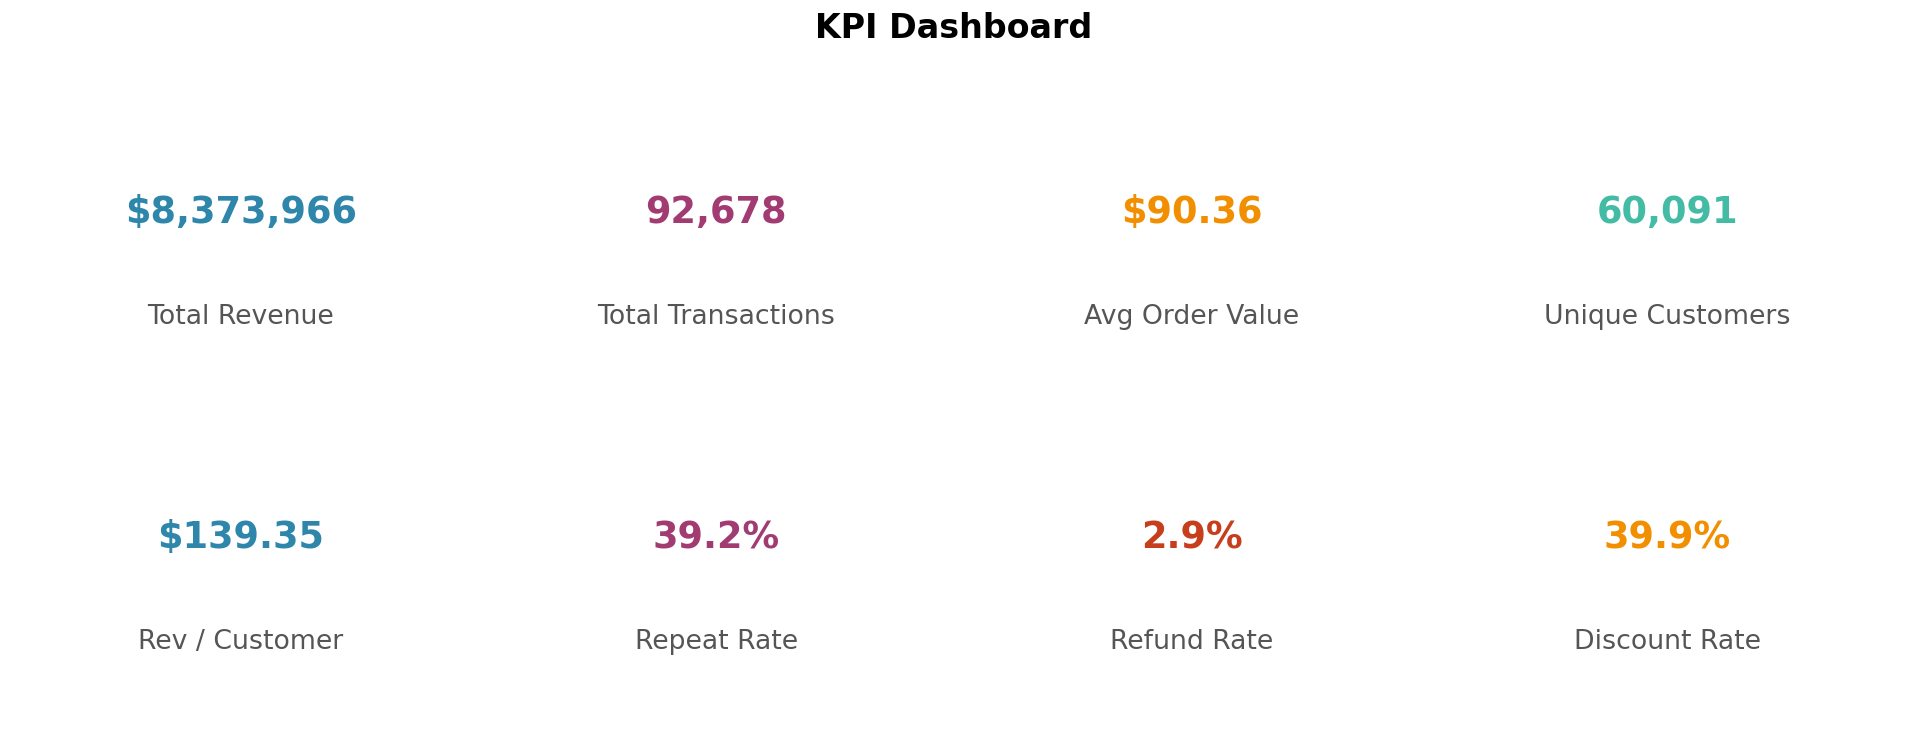

In [20]:
# KPI dashboard visual
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('KPI Dashboard', fontsize=20, fontweight='bold', y=1.02)

kpis = [
    ('Total Revenue', f'${total_revenue:,.0f}', '#2E86AB'),
    ('Total Transactions', f'{total_transactions:,}', '#A23B72'),
    ('Avg Order Value', f'${avg_order_value:.2f}', '#F18F01'),
    ('Unique Customers', f'{unique_customers:,}', '#44BBA4'),
    ('Rev / Customer', f'${rev_per_customer:.2f}', '#2E86AB'),
    ('Repeat Rate', f'{repeat_rate_pct:.1f}%', '#A23B72'),
    ('Refund Rate', f'{refund_rate:.1f}%', '#C73E1D'),
    ('Discount Rate', f'{discount_rate:.1f}%', '#F18F01'),
]

for ax, (label, value, color) in zip(axes.flatten(), kpis):
    ax.set_facecolor('#F9F9F9')
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=16, color='#555555', transform=ax.transAxes)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()


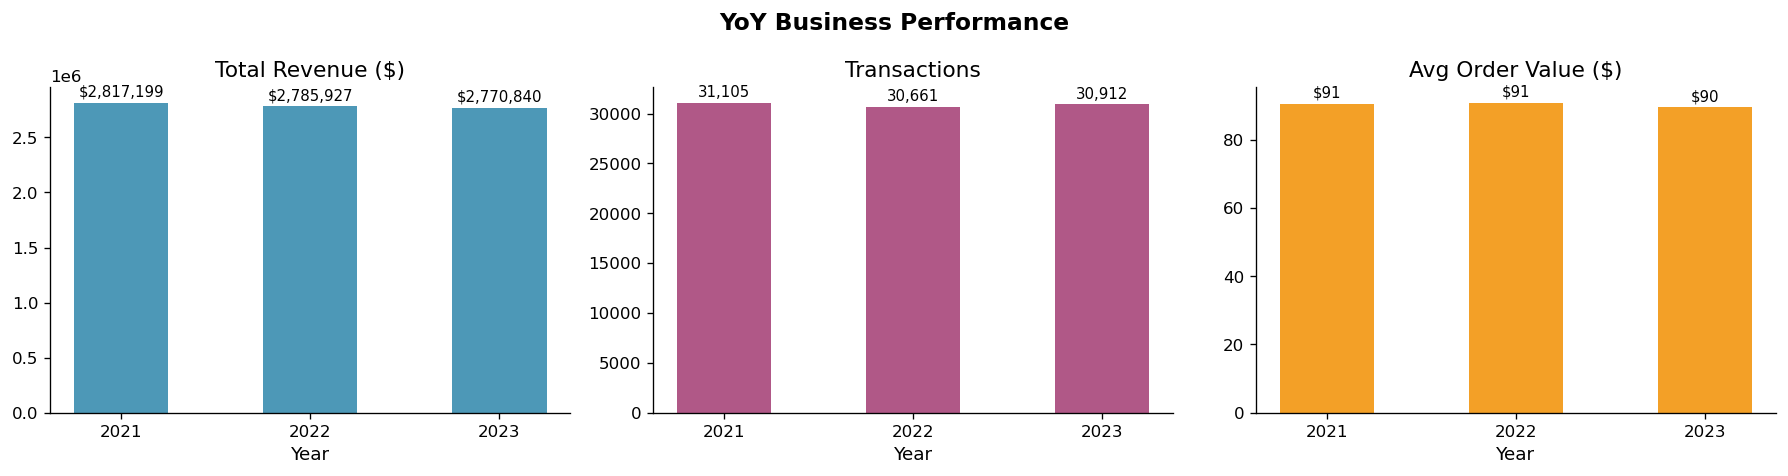

In [21]:
# Revenue by year
rev_by_year = txn_full.groupby('year')['gross_revenue'].agg(['sum','count','mean']).reset_index()
rev_by_year.columns = ['year','total_revenue','transactions','avg_order_value']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label, color) in zip(axes, [
    ('total_revenue',   'Total Revenue ($)', '#2E86AB'),
    ('transactions',    'Transactions',      '#A23B72'),
    ('avg_order_value', 'Avg Order Value ($)','#F18F01'),
]):
    bars = ax.bar(rev_by_year['year'].astype(str), rev_by_year[col], color=color, alpha=0.85, width=0.5)
    ax.set_title(label)
    ax.set_xlabel('Year')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
                f'${h:,.0f}' if 'Revenue' in label or 'Value' in label else f'{h:,.0f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('YoY Business Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Key Takeaways: Executive Summary

- The business generated **$8.37M in revenue** from **92,678 transactions**, with a strong base of **60,091 purchasing customers**.

- Retention is a clear opportunity: **39.2% of customers purchased more than once**, a healthy signal that customers are returning. Loyalty and repeat-purchase strategies could be meaningful growth levers.

- Refunds appear manageable at **2.9%**, but discounts were used on **39.9% of transactions**, making promotion efficiency an important area for deeper review.

- The next step is to identify which campaigns, channels, products, and customer segments are driving the strongest revenue contribution and where marketing investment should be prioritized.


---
<a id="campaign-performance-analysis"></a>

## 6. Campaign Performance Analysis

**The Goal:**  
Understand which campaigns contributed the most revenue and which campaign attributes were associated with stronger business outcomes.

**The How:**  
I analyzed campaign performance by channel, objective, transaction volume, total revenue, average order value, refund rate, discount usage, and expected uplift. I also compared expected uplift against actual revenue to evaluate whether campaign expectations aligned with observed performance.

**The Why:**  
Campaign analysis helps understand where investment appears to be creating the strongest return. It also helps identify campaigns that may look active on the surface but underperform when evaluated against revenue, customer quality, or refund behavior.

[Back to Top](#back-to-top)

In [22]:
# Campaign revenue summary
camp_perf = (
    known_campaigns_txn
    .merge(campaigns, on='campaign_id', how='left')
    .groupby(['campaign_id', 'channel', 'objective', 'target_segment', 'expected_uplift'])
    .agg(
        transactions   = ('transaction_id', 'count'),
        total_revenue  = ('gross_revenue',  'sum'),
        avg_order_value= ('gross_revenue',  'mean'),
        refund_count   = ('refund_flag',    'sum'),
        avg_discount   = ('discount_applied','mean'),
    )
    .reset_index()
)
camp_perf['refund_rate_pct']    = camp_perf['refund_count'] / camp_perf['transactions'] * 100
camp_perf['avg_discount_pct']   = camp_perf['avg_discount'] * 100
camp_perf['expected_uplift_pct']= camp_perf['expected_uplift'] * 100
camp_perf = camp_perf.sort_values('total_revenue', ascending=False)

print(f"Total attributed campaigns: {camp_perf.shape[0]}")
display(camp_perf[['campaign_id','channel','objective','total_revenue',
                    'transactions','avg_order_value','refund_rate_pct',
                    'expected_uplift_pct']].head(10))


Total attributed campaigns: 50


,campaign_id,channel,objective,total_revenue,transactions,avg_order_value,refund_rate_pct,expected_uplift_pct
17,18,Affiliate,Retention,"187,497.20",2027,92.50,2.47,13.90
4,5,Social,Acquisition,"184,244.86",2012,91.57,3.03,14.40
28,29,Email,Acquisition,"180,315.11",1995,90.38,3.36,14.00
43,44,Affiliate,Reactivation,"175,026.54",2019,86.69,4.66,14.10
6,7,Paid Search,Cross-sell,"171,224.62",1929,88.76,3.32,13.60
24,25,Paid Search,Cross-sell,"169,397.56",1804,93.90,2.44,11.90
16,17,Display,Retention,"169,313.35",1934,87.55,2.43,14.00
15,16,Email,Reactivation,"166,515.24",1815,91.74,2.04,11.80
48,49,Paid Search,Reactivation,"165,853.45",1908,86.93,4.04,12.80
44,45,Affiliate,Retention,"162,651.75",1754,92.73,2.28,11.40


In [23]:
# Revenue by channel (attributed campaigns)
channel_rev = (
    known_campaigns_txn
    .merge(campaigns[['campaign_id','channel']], on='campaign_id')
    .groupby('channel')
    .agg(
        total_revenue  = ('gross_revenue', 'sum'),
        transactions   = ('transaction_id','count'),
        campaigns      = ('campaign_id',   'nunique'),
        avg_order_value= ('gross_revenue', 'mean'),
        refund_rate    = ('refund_flag',   'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
channel_rev['refund_rate_pct'] = channel_rev['refund_rate'] * 100
channel_rev['rev_per_txn']     = channel_rev['total_revenue'] / channel_rev['transactions']

print("Revenue by Channel:")
display(channel_rev[['channel','total_revenue','transactions','campaigns',
                      'avg_order_value','refund_rate_pct']])


Revenue by Channel:


,channel,total_revenue,transactions,campaigns,avg_order_value,refund_rate_pct
0,Affiliate,"1,608,144.17",17676,11,90.98,2.79
3,Paid Search,"1,533,909.64",16949,11,90.50,3.12
2,Email,"1,357,550.66",15108,11,89.86,2.91
1,Display,"1,211,416.38",13437,9,90.16,2.84
4,Social,"972,825.47",10719,8,90.76,2.89


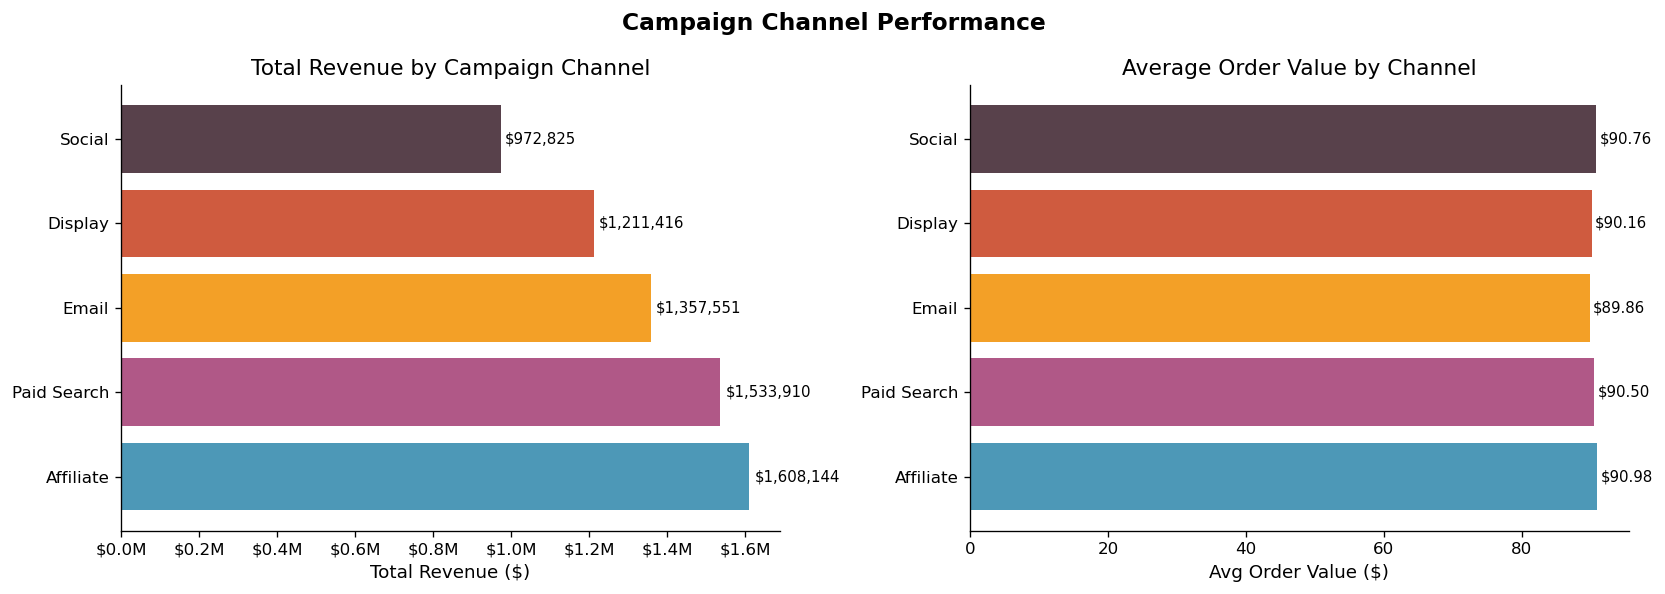

In [24]:
# Campaign channel revenue bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total revenue by channel
colors = PALETTE[:len(channel_rev)]
bars = axes[0].barh(channel_rev['channel'], channel_rev['total_revenue'],
                    color=colors, alpha=0.85)
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_title('Total Revenue by Campaign Channel')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + w*0.01, bar.get_y() + bar.get_height()/2,
                 f'${w:,.0f}', va='center', fontsize=9)

# Right: AOV by channel
colors2 = PALETTE[:len(channel_rev)]
bars2 = axes[1].barh(channel_rev['channel'], channel_rev['avg_order_value'],
                     color=colors2, alpha=0.85)
axes[1].set_xlabel('Avg Order Value ($)')
axes[1].set_title('Average Order Value by Channel')
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                 f'${w:.2f}', va='center', fontsize=9)

plt.suptitle('Campaign Channel Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


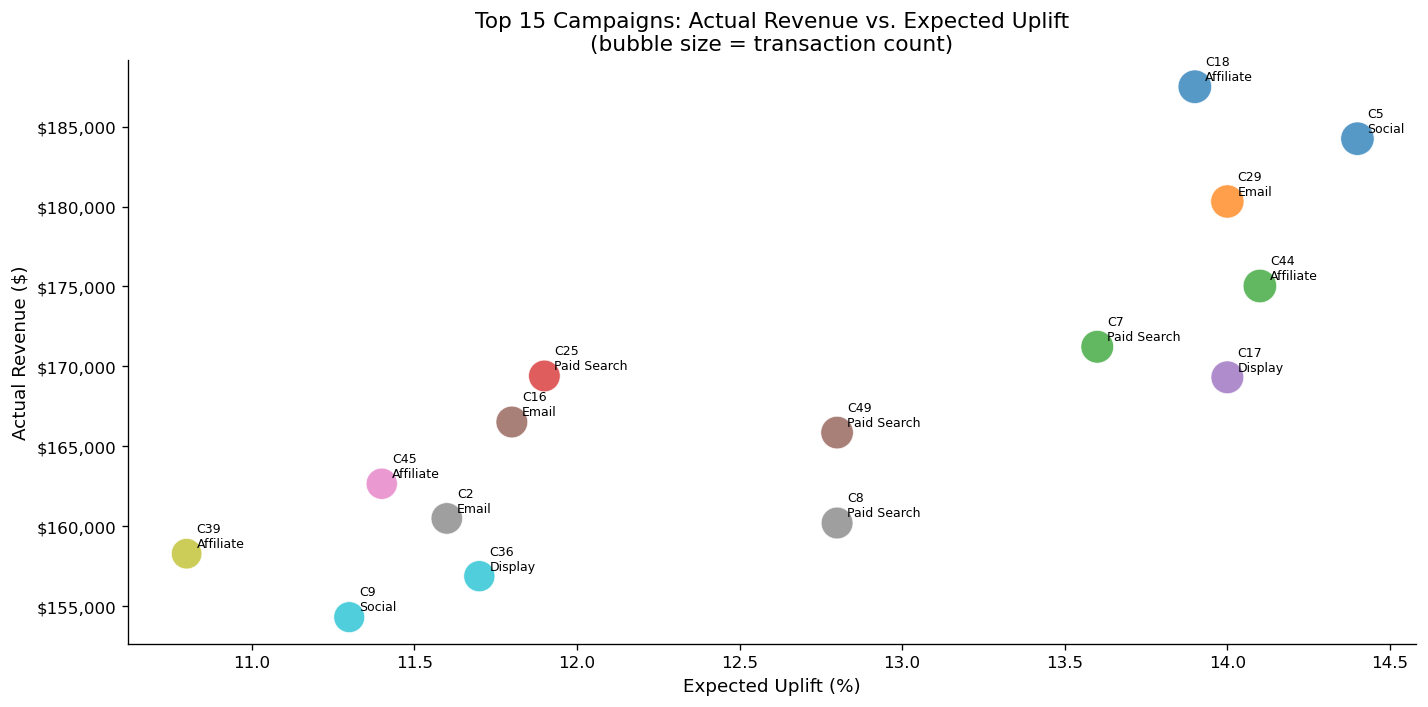

In [25]:
# Top 15 campaigns — revenue vs expected uplift
top15 = camp_perf.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    top15['expected_uplift_pct'],
    top15['total_revenue'],
    s=top15['transactions'] / 5,
    c=range(len(top15)),
    cmap='tab10',
    alpha=0.75, edgecolors='white', linewidths=0.5
)

for _, row in top15.iterrows():
    ax.annotate(
        f"C{int(row['campaign_id'])}\n{row['channel']}",
        (row['expected_uplift_pct'], row['total_revenue']),
        xytext=(6, 4), textcoords='offset points', fontsize=7.5
    )

ax.set_xlabel('Expected Uplift (%)')
ax.set_ylabel('Actual Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 15 Campaigns: Actual Revenue vs. Expected Uplift\n(bubble size = transaction count)')
plt.tight_layout()
plt.show()


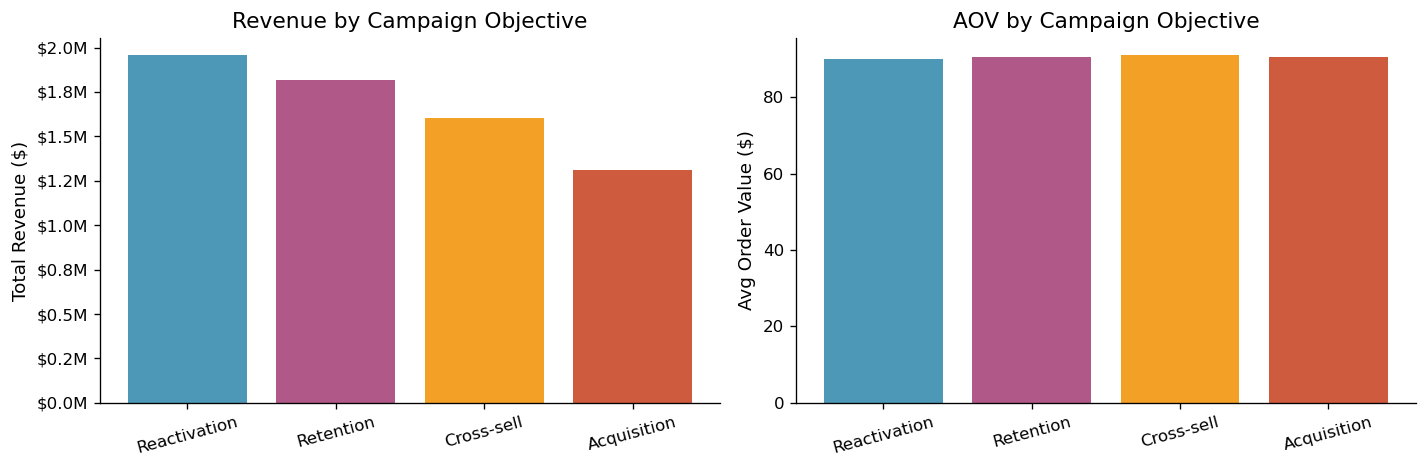

,objective,total_revenue,transactions,campaigns,avg_aov
2,Reactivation,"1,955,676.20",21732,15,89.99
3,Retention,"1,815,008.12",20051,13,90.52
1,Cross-sell,"1,602,569.22",17622,12,90.94
0,Acquisition,"1,310,592.78",14484,10,90.49


In [26]:
# Campaign performance by objective
obj_perf = (
    known_campaigns_txn
    .merge(campaigns[['campaign_id','objective']], on='campaign_id')
    .groupby('objective')
    .agg(
        total_revenue = ('gross_revenue', 'sum'),
        transactions  = ('transaction_id','count'),
        campaigns     = ('campaign_id',   'nunique'),
        avg_aov       = ('gross_revenue', 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(obj_perf['objective'], obj_perf['total_revenue'],
            color=PALETTE[:len(obj_perf)], alpha=0.85)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_title('Revenue by Campaign Objective')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(obj_perf['objective'], obj_perf['avg_aov'],
            color=PALETTE[:len(obj_perf)], alpha=0.85)
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('AOV by Campaign Objective')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
display(obj_perf)


### Campaign Performance Insights

- **Affiliate was the top attributed campaign channel**, generating **USD 1.61M in revenue**, ahead of Paid Search at **USD 1.53M** and Email at **USD 1.36M**.

- **Paid Search was the second-largest campaign revenue driver**, but also had the highest refund rate among campaign channels at **3.12%**, making it worth monitoring from a revenue-quality perspective.

- **Social had the lowest total attributed campaign revenue at USD 972.8K**, but still produced one of the strongest individual campaigns: Campaign 5, a Social acquisition campaign targeting new customers, generated **USD 184.2K**.

- **The highest-grossing individual campaign was Campaign 18**, an Affiliate retention campaign, which generated **USD 187.5K** with an AOV of **USD 92.50**.

- **AOV was fairly consistent across channels**, ranging from roughly **USD 89.86 to USD 90.98**, which suggests differences in total revenue were driven more by transaction volume than order value.

- **No campaign channel showed an unusually high refund rate**, with all channels landing around **2.8%–3.1%**. This suggests campaign-driven revenue quality was relatively stable across the mix.

---
<a id="channel-acquisition-performance"></a>

## 7. Channel & Acquisition Performance Analysis

**The Goal:**  
Identify which acquisition channels and traffic sources brought in the highest-value customers, not just the most activity.

**The How:**  
I compared acquisition channels across revenue, customer volume, average order value, repeat purchase behavior, refund rate, and discount usage. I also analyzed loyalty tier mix by channel and reviewed traffic source performance from the event data.

**The Why:**  
Traffic volume alone does not indicate marketing efficiency. A channel can bring in many users but still underperform if those users convert poorly, purchase less often, require heavier discounts, or generate lower revenue per customer. This analysis helps determine where acquisition investment may be most valuable.

[Back to Top](#back-to-top)

In [27]:
# Revenue & customers by acquisition channel
acq_perf = (
    txn_full.groupby('acquisition_channel')
    .agg(
        unique_customers  = ('customer_id',    'nunique'),
        total_revenue     = ('gross_revenue',  'sum'),
        transactions      = ('transaction_id', 'count'),
        avg_order_value   = ('gross_revenue',  'mean'),
        refund_rate       = ('refund_flag',    'mean'),
        avg_discount      = ('discount_applied','mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
acq_perf['revenue_per_customer'] = acq_perf['total_revenue'] / acq_perf['unique_customers']
acq_perf['txns_per_customer']    = acq_perf['transactions']  / acq_perf['unique_customers']
acq_perf['refund_rate_pct']      = acq_perf['refund_rate'] * 100
acq_perf['avg_discount_pct']     = acq_perf['avg_discount'] * 100

display(acq_perf[['acquisition_channel','unique_customers','total_revenue',
                   'avg_order_value','revenue_per_customer','txns_per_customer',
                   'refund_rate_pct']])


,acquisition_channel,unique_customers,total_revenue,avg_order_value,revenue_per_customer,txns_per_customer,refund_rate_pct
1,Organic,18210,"2,565,334.77",91.58,140.88,1.54,2.84
2,Paid Search,18064,"2,499,671.93",89.70,138.38,1.54,2.93
0,Email,8899,"1,255,819.95",91.11,141.12,1.55,2.74
4,Social,8932,"1,218,334.54",88.64,136.40,1.54,3.27
3,Referral,5986,"834,805.17",90.04,139.46,1.55,2.85


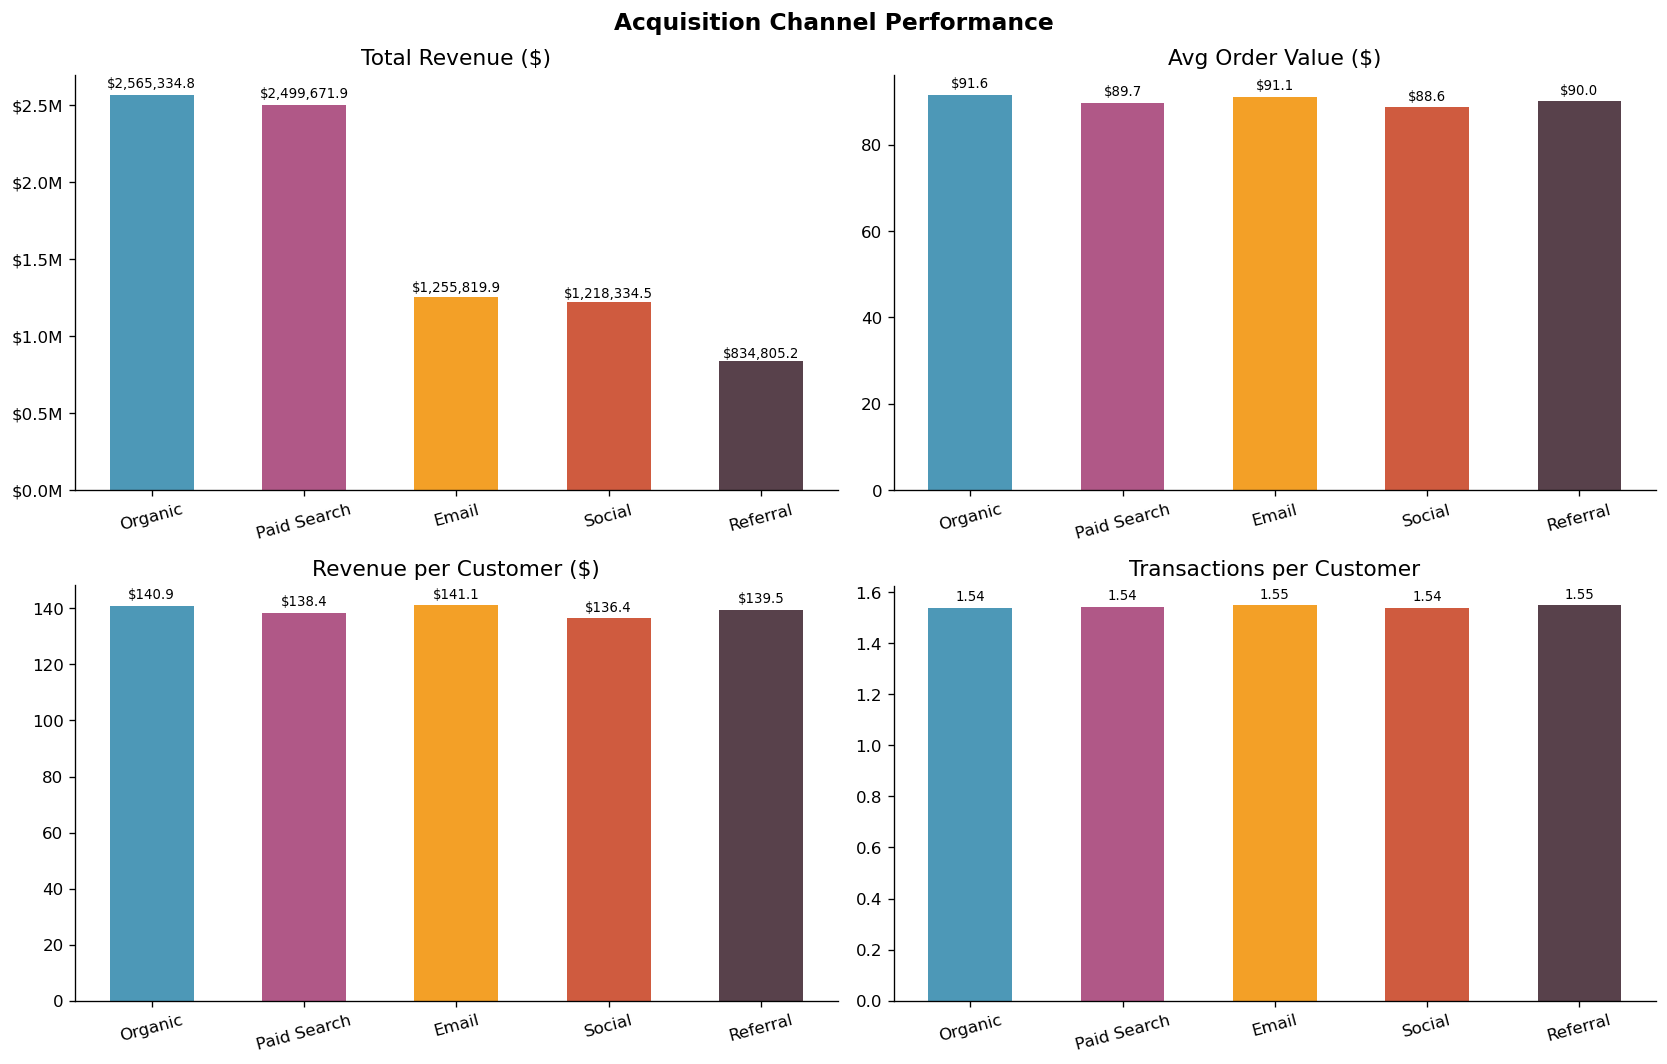

In [28]:
# Channel comparison chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('total_revenue',      'Total Revenue ($)',          True),
    ('avg_order_value',    'Avg Order Value ($)',         False),
    ('revenue_per_customer','Revenue per Customer ($)',   False),
    ('txns_per_customer',  'Transactions per Customer',  False),
]

for ax, (col, title, fmt_m) in zip(axes.flatten(), metrics):
    bars = ax.bar(acq_perf['acquisition_channel'], acq_perf[col],
                  color=PALETTE[:len(acq_perf)], alpha=0.85, width=0.55)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    if fmt_m:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
                f'${h:,.1f}' if '$' in title else f'{h:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Acquisition Channel Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


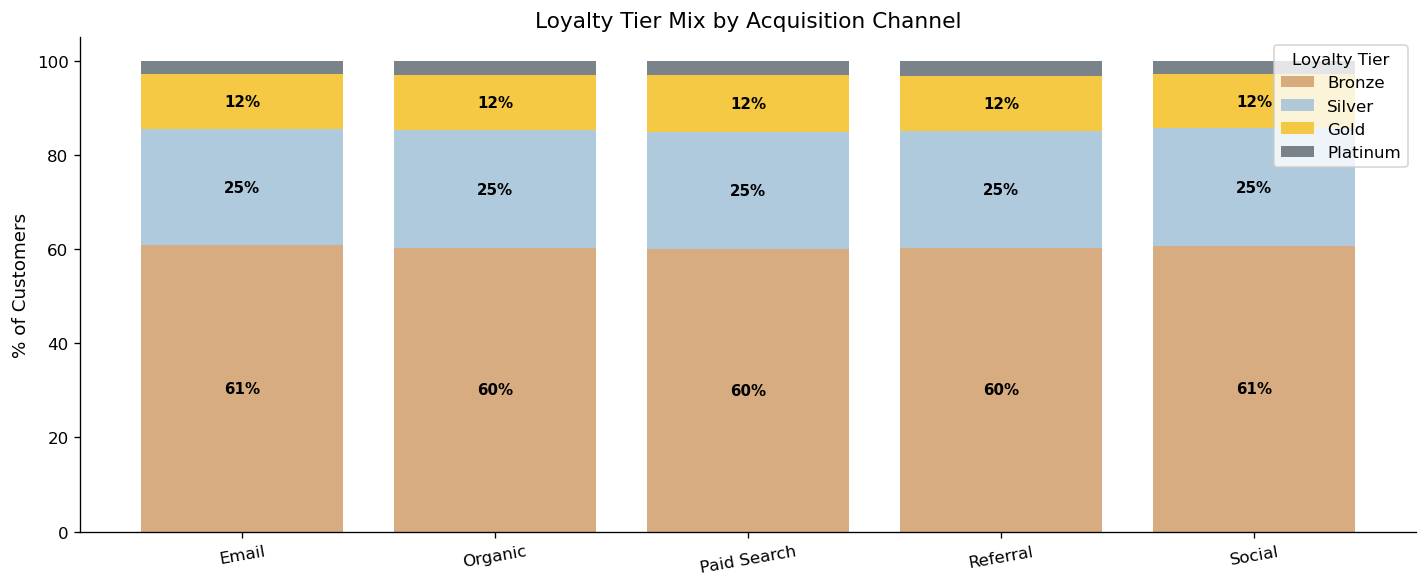

In [29]:
# Loyalty tier mix by acquisition channel
tier_channel = (
    customers.groupby(['acquisition_channel', 'loyalty_tier'])
    .size().reset_index(name='count')
)
tier_pivot = tier_channel.pivot(index='acquisition_channel', columns='loyalty_tier', values='count').fillna(0)
# Reorder tiers
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
tier_pivot = tier_pivot[[t for t in tier_order if t in tier_pivot.columns]]
tier_pct   = tier_pivot.div(tier_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(tier_pct))
colors_tier = ['#D4A373', '#A8C5DA', '#F4C430', '#6C757D']
for col, color in zip(tier_pct.columns, colors_tier):
    bars = ax.bar(tier_pct.index, tier_pct[col], bottom=bottom, label=col, color=color, alpha=0.9)
    for bar, val in zip(bars, tier_pct[col]):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2.,
                    bar.get_y() + bar.get_height()/2.,
                    f'{val:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    bottom += tier_pct[col].values

ax.set_ylabel('% of Customers')
ax.set_title('Loyalty Tier Mix by Acquisition Channel')
ax.legend(loc='upper right', title='Loyalty Tier')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()


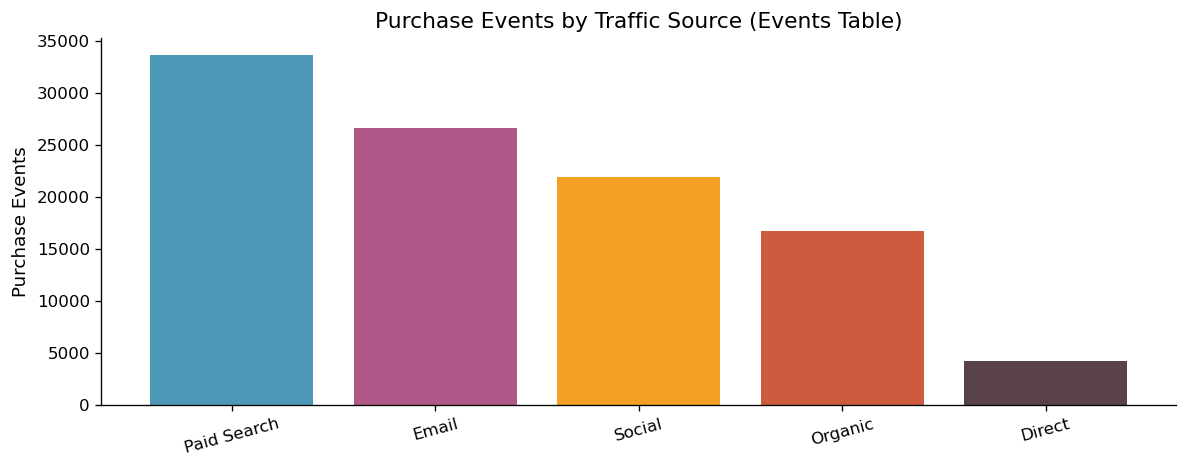

In [30]:
# Traffic source in events vs acquisition channel
traffic_rev = (
    events[events['event_type'] == 'purchase']
    .groupby('traffic_source')
    .agg(purchases=('event_id','count'))
    .reset_index()
    .sort_values('purchases', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(traffic_rev['traffic_source'], traffic_rev['purchases'],
       color=PALETTE[:len(traffic_rev)], alpha=0.85)
ax.set_ylabel('Purchase Events')
ax.set_title('Purchase Events by Traffic Source (Events Table)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


### Channel & Acquisition Performance Insights

- **Organic generated the most revenue among acquisition channels**, producing **USD 2.57M** from **18,210 purchasing customers**. This makes Organic the largest customer acquisition revenue driver in the dataset.

- **Email had the highest revenue per customer**, at **USD 141.12**, slightly ahead of Organic at **USD 140.88**. While Email brought in fewer customers than Organic or Paid Search, it appears to attract higher-value buyers.

- **Paid Search was the second-largest revenue channel**, generating **USD 2.50M**, but its revenue per customer was slightly lower at **USD 138.38**. This suggests Paid Search is a strong scale channel, but may need closer efficiency monitoring.

- **Social underperformed on both total revenue and revenue per customer**, generating **USD 1.22M** with the lowest revenue per customer at **USD 136.40**. It also had the highest refund rate among acquisition channels at **3.27%**.

- **Referral had the smallest customer base**, with **5,986 purchasing customers**, but still generated **USD 834.8K** in revenue. This may be a smaller but potentially useful channel for retention, advocacy, or lower-cost acquisition tests.

- **AOV was relatively consistent across channels**, ranging from **USD 88.64** for Social to **USD 91.58** for Organic. This suggests the biggest channel differences were driven more by customer volume and repeat behavior than major differences in order value.


---
<a id="funnel-analysis"></a>

## 8. Funnel Analysis

**The Goal:**  
Understand how users moved through the purchase journey and identify where the largest conversion drop-offs occurred.

**The How:**  
I built a funnel from view to click to add-to-cart to purchase, calculated step-by-step conversion and drop-off rates, and analyzed funnel performance by device type using a heatmap.

**The Why:**  
Funnel analysis helps identify where the business is losing potential customers. Improving conversion at high-friction stages can increase revenue from existing traffic, making it one of the highest-impact opportunities.

[Back to Top](#back-to-top)

In [31]:
# Funnel step counts
funnel_order = ['view', 'click', 'add_to_cart', 'purchase']
funnel_counts = (
    events[events['event_type'].isin(funnel_order)]
    .groupby('event_type')['event_id']
    .count()
    .reindex(funnel_order)
)

print("Funnel Event Counts:")
for step, count in funnel_counts.items():
    print(f"  {step:15s}: {count:>10,}")


Funnel Event Counts:
  view           :  1,043,573
  click          :    379,008
  add_to_cart    :    284,370
  purchase       :    103,127


In [32]:
# Funnel conversion rates
funnel_df = pd.DataFrame({
    'stage': funnel_order,
    'count': funnel_counts.values
})
funnel_df['conversion_from_prev'] = funnel_df['count'].pct_change() * 100
funnel_df['conversion_from_top']  = funnel_df['count'] / funnel_df['count'].iloc[0] * 100
funnel_df['drop_off_pct']         = 100 - funnel_df['conversion_from_prev'].clip(lower=0) - 100

# Fix first row
funnel_df.loc[0, 'conversion_from_prev'] = 100.0

print("Funnel Conversion Summary:")
display(funnel_df)


Funnel Conversion Summary:


,stage,count,conversion_from_prev,conversion_from_top,drop_off_pct
0,view,1043573,100.00,100.00,NaN
1,click,379008,-63.68,36.32,0.00
2,add_to_cart,284370,-24.97,27.25,0.00
3,purchase,103127,-63.73,9.88,0.00


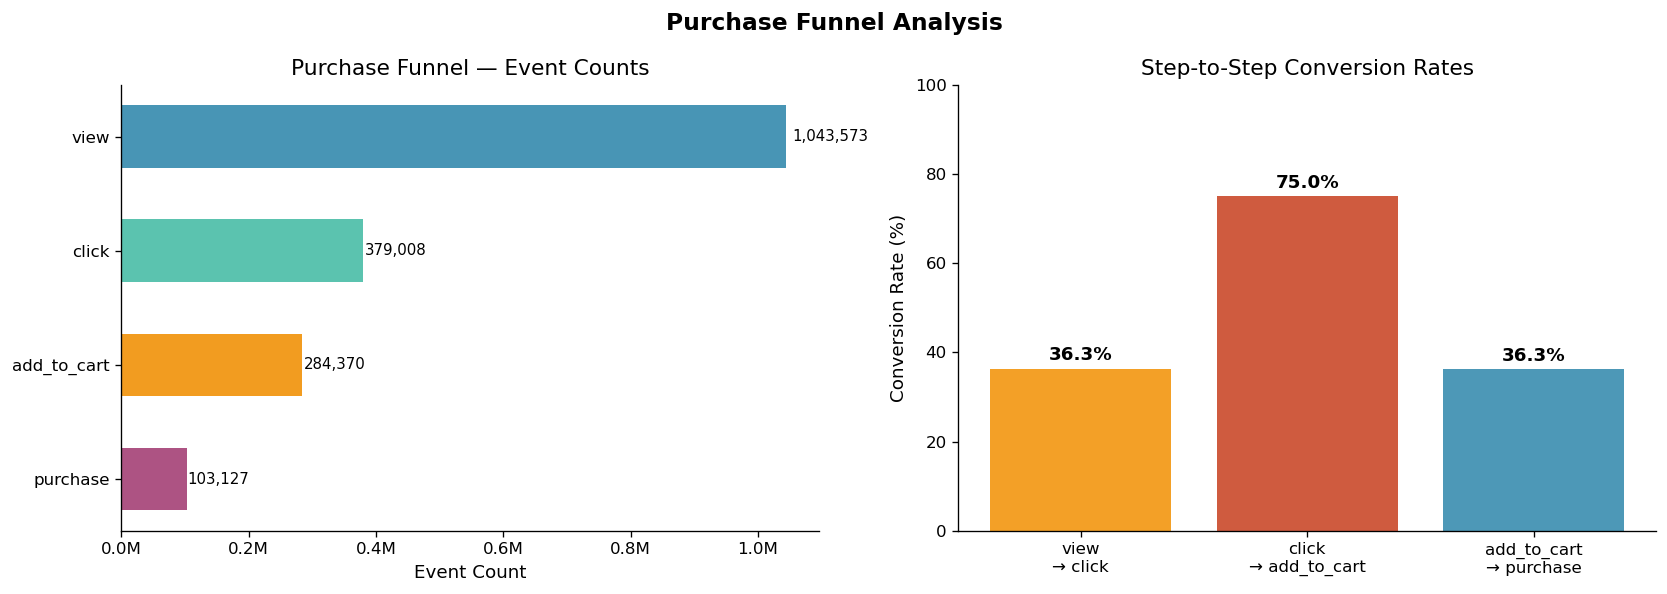

In [33]:
# Funnel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Waterfall funnel
colors_funnel = ['#2E86AB', '#44BBA4', '#F18F01', '#A23B72']
bars = axes[0].barh(
    funnel_df['stage'][::-1], funnel_df['count'][::-1],
    color=colors_funnel[::-1], alpha=0.88, height=0.55
)
axes[0].set_xlabel('Event Count')
axes[0].set_title('Purchase Funnel — Event Counts')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, count in zip(bars, funnel_df['count'][::-1].values):
    axes[0].text(bar.get_width() + bar.get_width()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=9)

# Step-to-step conversion
step_conv = []
stage_labels = []
for i in range(1, len(funnel_df)):
    prev = funnel_df.loc[i-1, 'count']
    curr = funnel_df.loc[i, 'count']
    step_conv.append(curr / prev * 100)
    stage_labels.append(f"{funnel_df.loc[i-1,'stage']}\n→ {funnel_df.loc[i,'stage']}")

bars2 = axes[1].bar(stage_labels, step_conv, color=['#F18F01','#C73E1D','#2E86AB'], alpha=0.85)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Step-to-Step Conversion Rates')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, step_conv):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Purchase Funnel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [34]:
# Funnel by device type
device_funnel = (
    events[events['event_type'].isin(funnel_order) & events['device_type'].notna()]
    .groupby(['device_type', 'event_type'])['event_id']
    .count()
    .unstack(fill_value=0)
    [funnel_order]
)

# Conversion rate to purchase
device_funnel['purchase_rate_pct'] = device_funnel['purchase'] / device_funnel['view'] * 100
device_funnel_pct = device_funnel.div(device_funnel['view'], axis=0) * 100

print("Purchase conversion rate by device:")
display(device_funnel[['view','click','add_to_cart','purchase','purchase_rate_pct']])


Purchase conversion rate by device:


event_type,view,click,add_to_cart,purchase,purchase_rate_pct
device_type,,,,,
desktop,357777,129562,97487,35323,9.87
mobile,613828,222896,167285,60657,9.88
tablet,51013,18926,13766,5071,9.94


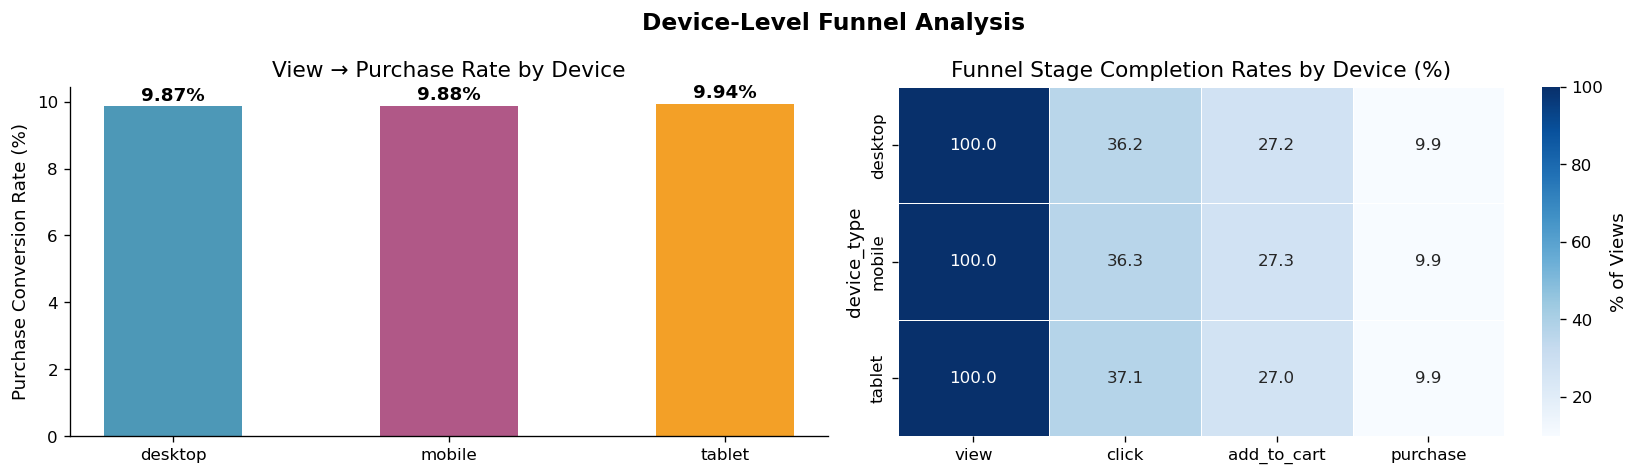

In [35]:
# Funnel heatmap by device
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: purchase conversion rate by device
devices = device_funnel.index.tolist()
rates   = device_funnel['purchase_rate_pct'].values
colors_d = [PALETTE[i] for i in range(len(devices))]
bars = axes[0].bar(devices, rates, color=colors_d, alpha=0.85, width=0.5)
axes[0].set_ylabel('Purchase Conversion Rate (%)')
axes[0].set_title('View → Purchase Rate by Device')
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{rate:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Heatmap of funnel stage percentages
hm_data = device_funnel_pct[funnel_order]
sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% of Views'})
axes[1].set_title('Funnel Stage Completion Rates by Device (%)')
axes[1].set_xlabel('')

plt.suptitle('Device-Level Funnel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Funnel Analysis Insights

- **The funnel started with 1.04M view events and ended with 103.1K purchase events**, resulting in an overall view-to-purchase conversion rate of **9.88%**.

- **The largest drop-off occurred between view and click**, where activity fell from **1.04M views** to **379.0K clicks**. This suggests the biggest opportunity is improving initial engagement from product or page views.

- **The second major drop-off occurred between add-to-cart and purchase**, where activity fell from **284.4K add-to-cart events** to **103.1K purchases**. This points to checkout, cart abandonment, shipping, pricing, or payment friction as potential areas to investigate.

- **Click-to-add-to-cart performance was comparatively stronger**, with **284.4K add-to-cart events** from **379.0K clicks**. This suggests that once users engage beyond the initial view, a meaningful share continue toward purchase intent.

- **Device-level purchase rates were very similar**, with desktop at **9.87%**, mobile at **9.88%**, and tablet at **9.94%**. This suggests there is no obvious device-specific conversion issue in the current dataset.

- **Mobile drove the largest volume of funnel activity**, with **613.8K views** and **60.7K purchases**, making it the most important device experience to protect and optimize.

---
<a id="ab-test-analysis"></a>

## 9. A/B Test Analysis

**The Goal:**  
Determine whether the site experiment produced a meaningful improvement in purchase conversion across the Control, Variant_A, and Variant_B groups.

**The How:**  
I compared conversion rates across experiment groups, calculated lift percentages, ran a chi-square test to evaluate statistical significance, flagged significant results, and reviewed performance by device type.

**The Why:**  
A/B testing helps make decisions based on evidence instead of assumptions. For an executive audience, the key question is not only which variant performed best, but whether the difference is strong enough to justify rollout, continued testing, or a change in strategy.

[Back to Top](#back-to-top)

In [36]:
# Experiment group event counts
exp_funnel = (
    events[events['event_type'].isin(['view', 'purchase'])]
    .groupby(['experiment_group', 'event_type'])['event_id']
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
exp_funnel.columns.name = None

if 'view' not in exp_funnel.columns:
    exp_funnel['view'] = 0
if 'purchase' not in exp_funnel.columns:
    exp_funnel['purchase'] = 0

exp_funnel['conversion_rate'] = exp_funnel['purchase'] / exp_funnel['view'] * 100
exp_funnel['non_purchase']    = exp_funnel['view'] - exp_funnel['purchase']

print("A/B Test — Funnel by Experiment Group:")
display(exp_funnel[['experiment_group','view','purchase','conversion_rate']])


A/B Test — Funnel by Experiment Group:


,experiment_group,view,purchase,conversion_rate
0,Control,628630,56855,9.04
1,Variant_A,208655,21045,10.09
2,Variant_B,206288,25227,12.23


In [37]:
#  Statistical significance testing (Chi-Square)
from scipy.stats import chi2_contingency

# We test each variant against Control
control = exp_funnel[exp_funnel['experiment_group'] == 'Control'].iloc[0]
results = []

for _, row in exp_funnel[exp_funnel['experiment_group'] != 'Control'].iterrows():
    contingency = np.array([
        [control['purchase'],    control['non_purchase']],
        [row['purchase'],        row['non_purchase']]
    ])
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    lift = (row['conversion_rate'] - control['conversion_rate']) / control['conversion_rate'] * 100
    results.append({
        'variant':           row['experiment_group'],
        'control_cvr':       round(control['conversion_rate'], 4),
        'variant_cvr':       round(row['conversion_rate'], 4),
        'lift_pct':          round(lift, 2),
        'chi2_statistic':    round(chi2, 4),
        'p_value':           round(p_value, 6),
        'significant_95pct': 'Yes ✓' if p_value < 0.05 else 'No ✗',
        'significant_99pct': 'Yes ✓' if p_value < 0.01 else 'No ✗',
    })

ab_results = pd.DataFrame(results)
print("\nStatistical Significance Test Results:")
display(ab_results)



Statistical Significance Test Results:


,variant,control_cvr,variant_cvr,lift_pct,chi2_statistic,p_value,significant_95pct,significant_99pct
0,Variant_A,9.04,10.09,11.52,201.36,0.00,Yes ✓,Yes ✓
1,Variant_B,9.04,12.23,35.21,"1,776.75",0.00,Yes ✓,Yes ✓


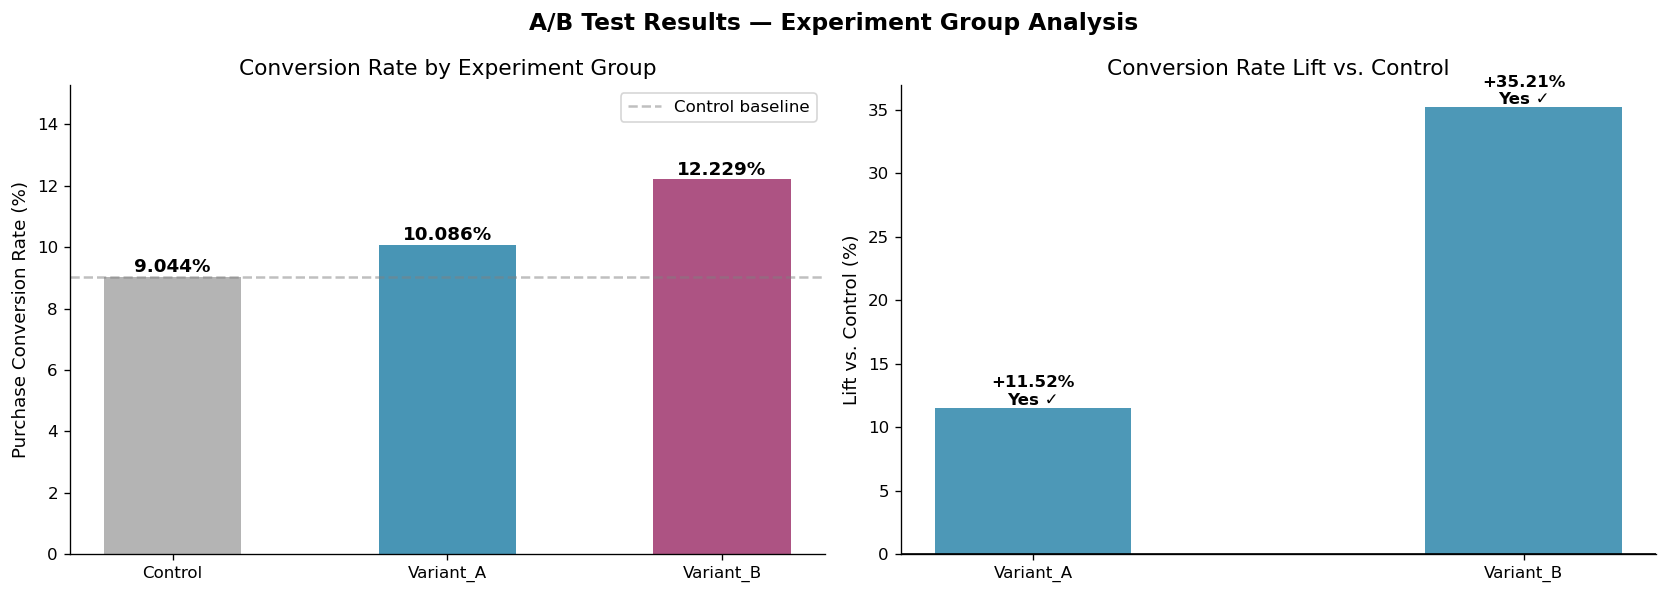

In [38]:
# A/B test visualization
groups  = exp_funnel['experiment_group'].tolist()
cvr     = exp_funnel['conversion_rate'].tolist()
colors_ = ['#AAAAAA', '#2E86AB', '#A23B72']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of conversion rates
bars = axes[0].bar(groups, cvr, color=colors_, alpha=0.88, width=0.5)
axes[0].set_ylabel('Purchase Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Experiment Group')
axes[0].set_ylim(0, max(cvr) * 1.25)
control_cvr = exp_funnel[exp_funnel['experiment_group']=='Control']['conversion_rate'].values[0]
axes[0].axhline(control_cvr, linestyle='--', color='gray', alpha=0.5, label='Control baseline')
axes[0].legend()
for bar, val in zip(bars, cvr):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Lift vs control
if len(ab_results) > 0:
    lift_colors = ['#2E86AB' if l > 0 else '#C73E1D' for l in ab_results['lift_pct']]
    axes[1].bar(ab_results['variant'], ab_results['lift_pct'],
                color=lift_colors, alpha=0.85, width=0.4)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_ylabel('Lift vs. Control (%)')
    axes[1].set_title('Conversion Rate Lift vs. Control')
    for i, (_, row) in enumerate(ab_results.iterrows()):
        sig = row['significant_95pct']
        axes[1].text(i, row['lift_pct'] + (0.02 if row['lift_pct'] >= 0 else -0.05),
                     f"{row['lift_pct']:+.2f}%\n{sig}",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('A/B Test Results — Experiment Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Conversion Rate by Device and Experiment Group:


experiment_group,Control,Variant_A,Variant_B
device_type,,,
desktop,9.02,10.17,12.17
mobile,9.03,10.03,12.33
tablet,9.24,10.22,11.76


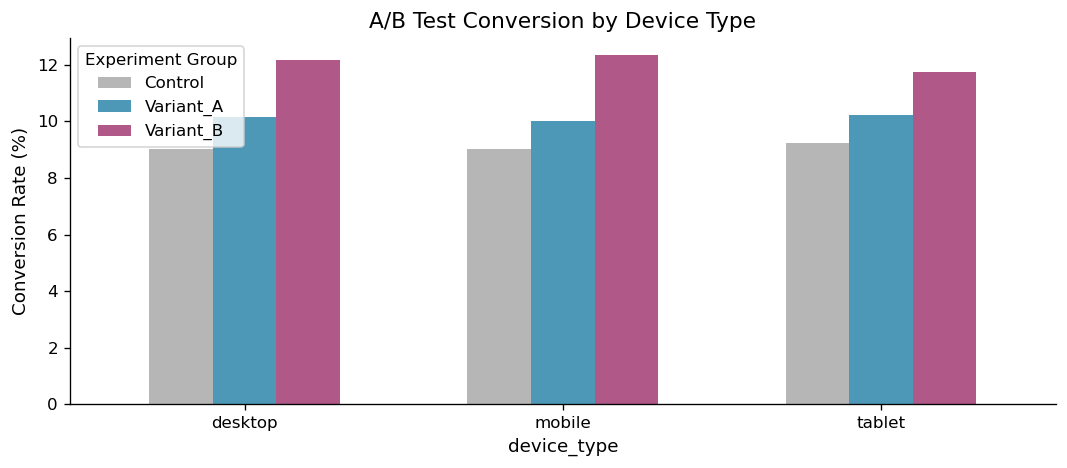

In [39]:
# A/B test by device type
exp_device = (
    events[events['event_type'].isin(['view','purchase']) & events['device_type'].notna()]
    .groupby(['experiment_group', 'device_type', 'event_type'])['event_id']
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
if 'purchase' in exp_device.columns and 'view' in exp_device.columns:
    exp_device['cvr'] = exp_device['purchase'] / exp_device['view'] * 100

pivot_device = exp_device.pivot_table(
    index='device_type', columns='experiment_group', values='cvr'
)
print("Conversion Rate by Device and Experiment Group:")
display(pivot_device.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
pivot_device.plot(kind='bar', ax=ax, color=colors_[:len(pivot_device.columns)], alpha=0.85, width=0.6)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('A/B Test Conversion by Device Type')
ax.legend(title='Experiment Group')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### A/B Test Insights

- **Variant_B was the strongest-performing experiment group**, with a purchase conversion rate of **12.23%**, compared with **9.04%** for Control.

- **Variant_A also outperformed Control**, with a conversion rate of **10.09%**, but the lift was much smaller than Variant_B.

- **Variant_B delivered a 35.21% lift over Control**, while Variant_A delivered an **11.52% lift**. Based on conversion impact, Variant_B is the clear winner.

- **Both variants were statistically significant at the 95% and 99% confidence levels**, meaning the observed performance differences are unlikely to be due to random variation.

- **The device breakdown supports the overall result.** Variant_B outperformed Control across desktop, mobile, and tablet, with conversion rates of **12.17%**, **12.33%**, and **11.76%**, respectively.

- **Recommendation:** Variant_B should be prioritized for rollout or further validation, while Variant_A may be useful as a secondary learning but does not appear to deliver the same level of business impact.

---
<a id="customer-segmentation-analysis"></a>

## 10. Customer Segmentation Analysis

**The Goal:**  
Identify which customer segments generated the strongest revenue and where targeting or retention opportunities may exist.

**The How:**  
I analyzed performance by loyalty tier, country, age group, and gender, comparing transaction volume, total revenue, average order value, revenue per customer, refund rate, and repeat purchase behavior.

**The Why:**  
Customer segmentation helps marketing teams understand which audiences are most valuable and how behavior differs across groups. These insights can inform targeting, personalization, retention campaigns, and customer lifecycle strategy.

[Back to Top](#back-to-top)

In [40]:
# Revenue by loyalty tier
tier_rev = (
    txn_full.groupby('loyalty_tier')
    .agg(
        unique_customers  = ('customer_id',    'nunique'),
        transactions      = ('transaction_id', 'count'),
        total_revenue     = ('gross_revenue',  'sum'),
        avg_order_value   = ('gross_revenue',  'mean'),
        refund_rate       = ('refund_flag',    'mean'),
        avg_discount      = ('discount_applied','mean'),
    )
    .reset_index()
)
tier_rev['revenue_per_customer'] = tier_rev['total_revenue'] / tier_rev['unique_customers']
tier_rev['txns_per_customer']    = tier_rev['transactions']  / tier_rev['unique_customers']
tier_rev['refund_rate_pct']      = tier_rev['refund_rate'] * 100

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
tier_rev['tier_order'] = tier_rev['loyalty_tier'].map({t: i for i, t in enumerate(tier_order)})
tier_rev = tier_rev.sort_values('tier_order')

display(tier_rev[['loyalty_tier','unique_customers','total_revenue',
                   'avg_order_value','revenue_per_customer','txns_per_customer','refund_rate_pct']])


,loyalty_tier,unique_customers,total_revenue,avg_order_value,revenue_per_customer,txns_per_customer,refund_rate_pct
0,Bronze,33862,"4,477,838.77",90.19,132.24,1.47,2.93
3,Silver,15860,"2,302,086.76",91.60,145.15,1.58,2.86
1,Gold,8262,"1,275,144.30",89.13,154.34,1.73,2.89
2,Platinum,2107,"318,896.53",88.75,151.35,1.71,3.26


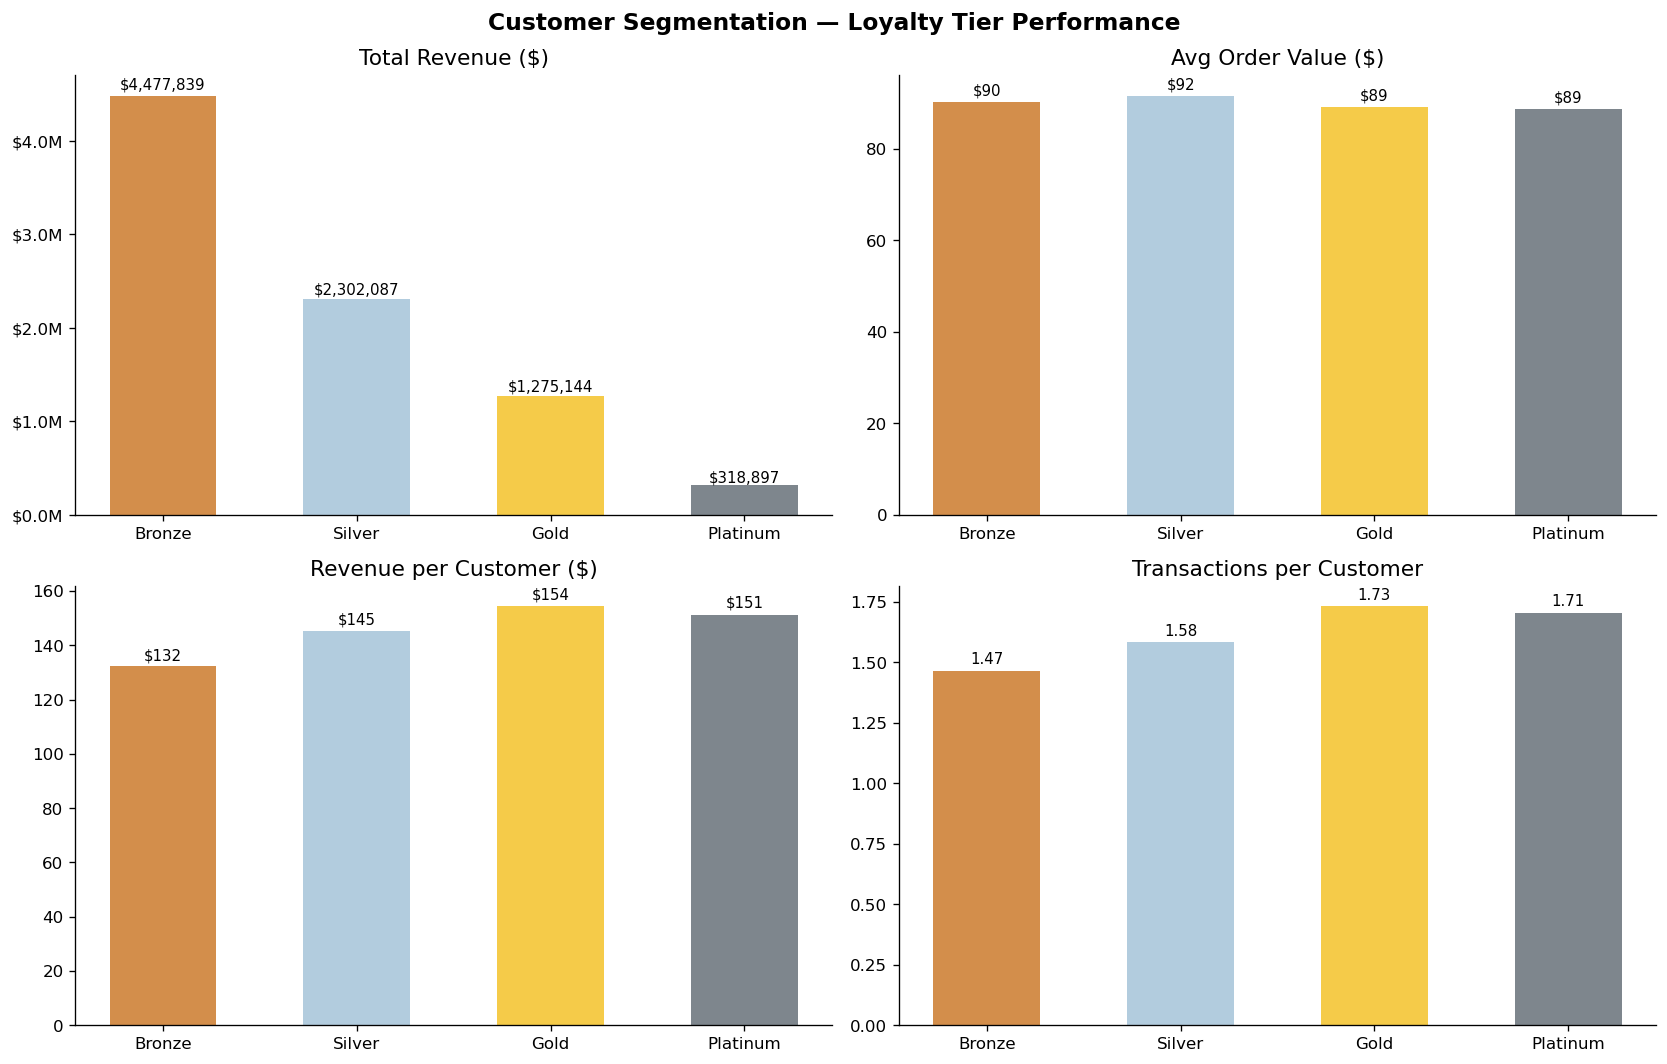

In [41]:
# Loyalty tier visuals
tier_colors = {'Bronze': '#CD7F32', 'Silver': '#A8C5DA', 'Gold': '#F4C430', 'Platinum': '#6C757D'}
t_colors = [tier_colors.get(t, '#999') for t in tier_rev['loyalty_tier']]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics_tier = [
    ('total_revenue',       'Total Revenue ($)',        True),
    ('avg_order_value',     'Avg Order Value ($)',      False),
    ('revenue_per_customer','Revenue per Customer ($)', False),
    ('txns_per_customer',   'Transactions per Customer',False),
]
for ax, (col, title, fmt_m) in zip(axes.flatten(), metrics_tier):
    bars = ax.bar(tier_rev['loyalty_tier'], tier_rev[col],
                  color=t_colors, alpha=0.88, width=0.55)
    ax.set_title(title)
    if fmt_m:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
                f'${h:,.0f}' if '$' in title else f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Customer Segmentation — Loyalty Tier Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


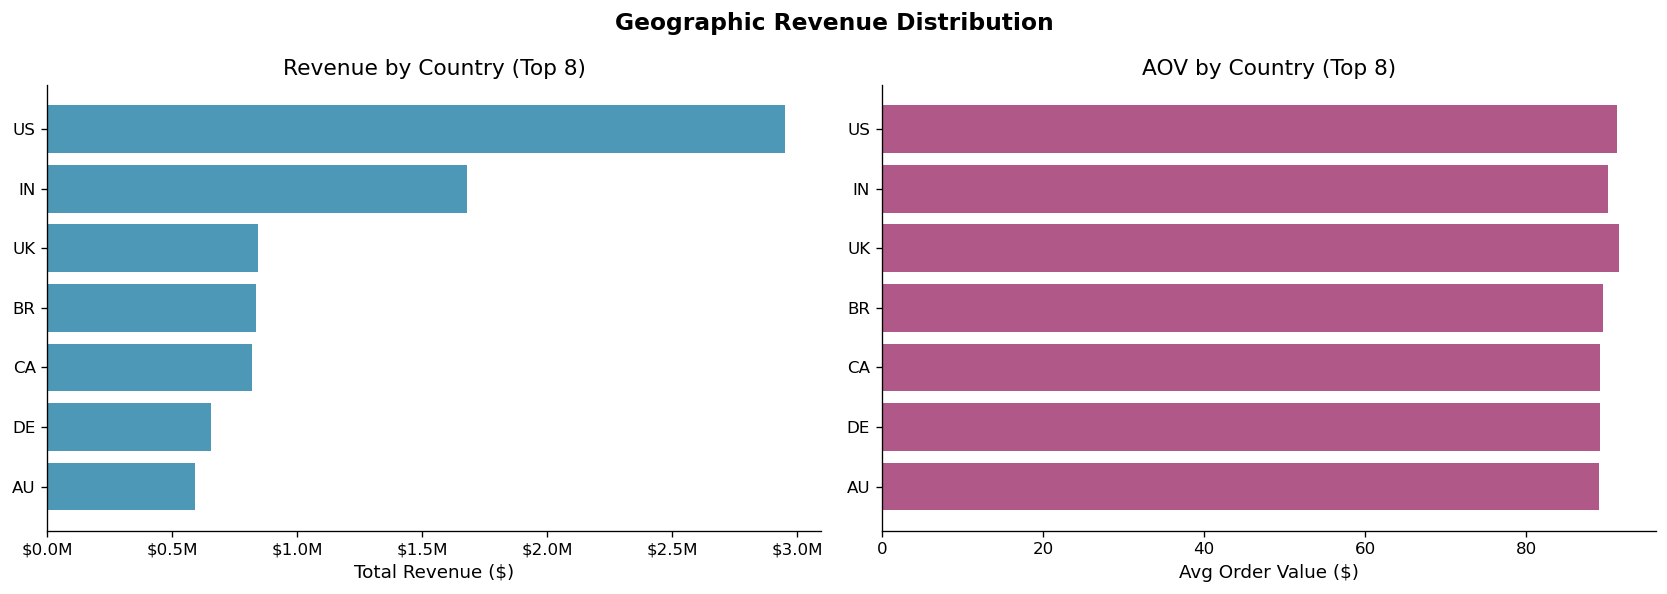

In [42]:
# Revenue by country (top 8)
country_rev = (
    txn_full.groupby('country')
    .agg(
        unique_customers = ('customer_id',    'nunique'),
        total_revenue    = ('gross_revenue',  'sum'),
        avg_order_value  = ('gross_revenue',  'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(8)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(country_rev['country'][::-1], country_rev['total_revenue'][::-1],
             color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_title('Revenue by Country (Top 8)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].barh(country_rev['country'][::-1], country_rev['avg_order_value'][::-1],
             color=PALETTE[1], alpha=0.85)
axes[1].set_xlabel('Avg Order Value ($)')
axes[1].set_title('AOV by Country (Top 8)')

plt.suptitle('Geographic Revenue Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


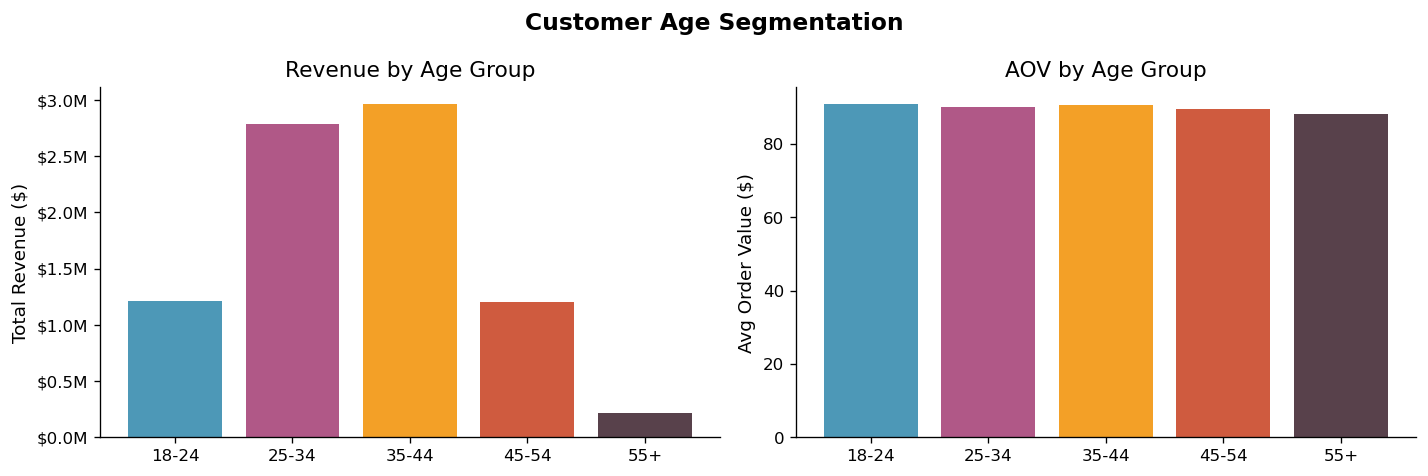

In [43]:
# Revenue by age group
age_rev = (
    txn_full.groupby('age_group', observed=True)
    .agg(
        customers    = ('customer_id',    'nunique'),
        total_revenue= ('gross_revenue',  'sum'),
        avg_aov      = ('gross_revenue',  'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(age_rev['age_group'].astype(str), age_rev['total_revenue'],
            color=PALETTE[:len(age_rev)], alpha=0.85)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_title('Revenue by Age Group')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].bar(age_rev['age_group'].astype(str), age_rev['avg_aov'],
            color=PALETTE[:len(age_rev)], alpha=0.85)
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('AOV by Age Group')

plt.suptitle('Customer Age Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [44]:
# Gender analysis
gender_rev = (
    txn_full.groupby('gender')
    .agg(
        customers    = ('customer_id',    'nunique'),
        total_revenue= ('gross_revenue',  'sum'),
        avg_aov      = ('gross_revenue',  'mean'),
        refund_rate  = ('refund_flag',    'mean'),
    )
    .reset_index()
)
gender_rev['revenue_share_pct'] = gender_rev['total_revenue'] / gender_rev['total_revenue'].sum() * 100
gender_rev['refund_rate_pct']   = gender_rev['refund_rate'] * 100
display(gender_rev.drop(columns='refund_rate'))


,gender,customers,total_revenue,avg_aov,revenue_share_pct,refund_rate_pct
0,Female,28841,"4,022,613.19",90.42,48.04,2.94
1,Male,28897,"4,008,965.79",90.13,47.87,2.91
2,Other,2353,"342,387.38",92.29,4.09,2.80


### Customer Segmentation Insights

- **Bronze customers generated the most total revenue**, contributing **USD 4.48M**. This is largely because Bronze represents the largest purchasing customer group, with **33,862 unique customers**.

- **Gold customers had the highest revenue per customer**, at **USD 154.34**, despite generating less total revenue than Bronze or Silver. This makes Gold a high-value segment for retention and loyalty-focused campaigns.

- **Platinum customers had strong revenue per customer at USD 151.35**, but represented a much smaller customer base with **2,107 unique customers**. This segment may be valuable, but growth is limited unless the business can expand or upgrade more customers into Platinum.

- **Silver customers showed a healthy middle-ground profile**, with **USD 2.30M** in revenue and **USD 145.15** revenue per customer. Silver may be an important migration segment for moving customers toward Gold or Platinum behavior.

- **Female and male customers contributed nearly equal revenue shares**, at **48.04%** and **47.87%**, respectively. This suggests gender was not a major differentiator in overall revenue contribution.

- **The “Other” gender segment had the highest AOV at USD 92.29**, but represented a much smaller customer group. This may be worth monitoring, but the business impact is smaller due to lower volume.


---
<a id="product-category-performance"></a>

## 11. Product & Category Performance Analysis

**The Goal:**  
Understand which product categories, premium products, and individual SKUs were the strongest revenue drivers.

**The How:**  
I analyzed revenue, transaction volume, average order value, refund rate, and discount usage by product category and premium flag. I also identified the top 15 SKUs by revenue contribution.

**The Why:**  
Product performance analysis helps connect marketing strategy to merchandising and product decisions. Understanding which categories and SKUs drive revenue can inform campaign planning, onsite promotion, inventory focus, and cross-sell opportunities.

[Back to Top](#back-to-top)

In [45]:
# Category revenue summary
cat_perf = (
    txn_full.groupby('category')
    .agg(
        transactions    = ('transaction_id', 'count'),
        total_revenue   = ('gross_revenue',  'sum'),
        avg_aov         = ('gross_revenue',  'mean'),
        avg_base_price  = ('base_price',     'mean'),
        avg_discount    = ('discount_applied','mean'),
        refund_rate     = ('refund_flag',    'mean'),
        unique_products = ('product_id',     'nunique'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
cat_perf['refund_rate_pct'] = cat_perf['refund_rate'] * 100
cat_perf['avg_discount_pct']= cat_perf['avg_discount'] * 100
cat_perf['revenue_share']   = cat_perf['total_revenue'] / cat_perf['total_revenue'].sum() * 100

display(cat_perf[['category','transactions','total_revenue','avg_aov',
                   'avg_discount_pct','refund_rate_pct','revenue_share']])


,category,transactions,total_revenue,avg_aov,avg_discount_pct,refund_rate_pct,revenue_share
1,Electronics,21095,"3,452,007.19",163.64,4.18,2.97,41.22
4,Home,18421,"1,996,432.94",108.38,4.11,2.75,23.84
2,Fashion,19339,"1,298,075.77",67.12,4.13,2.79,15.50
5,Sports,10168,"965,609.13",94.97,4.17,3.24,11.53
0,Beauty,9224,"369,671.88",40.08,4.06,3.10,4.41
3,Grocery,14431,"292,169.45",20.25,4.10,2.88,3.49


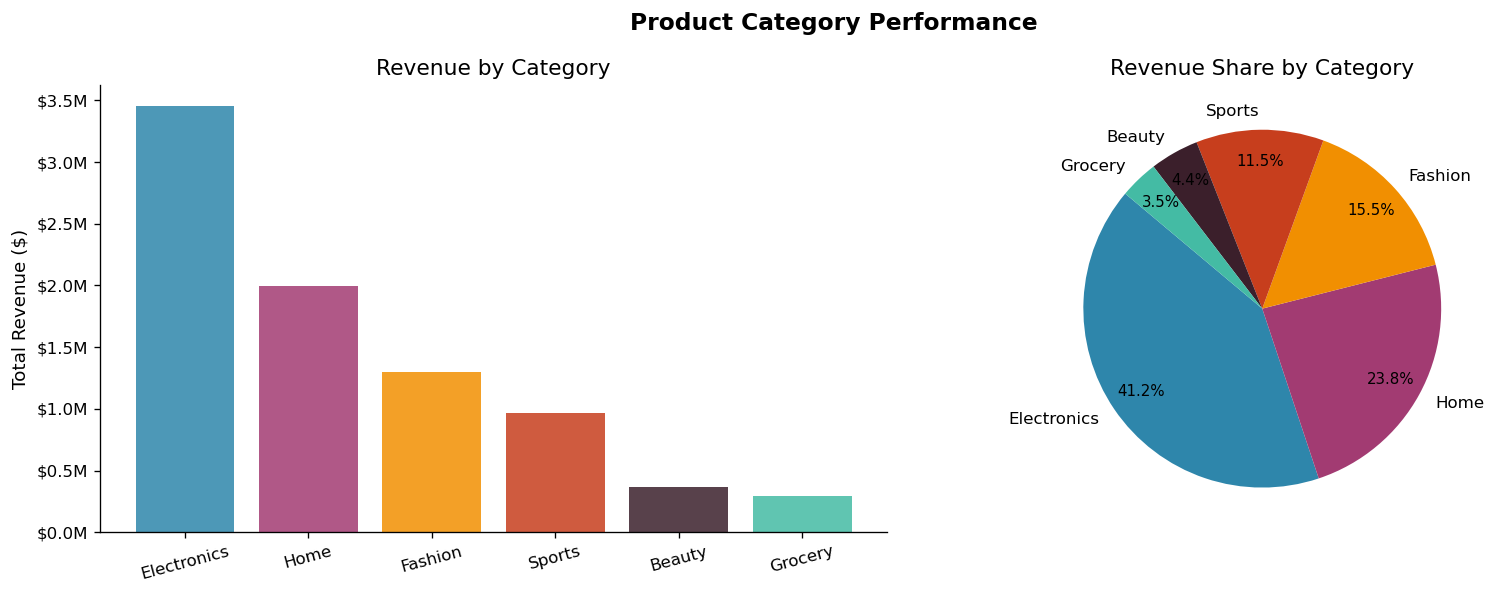

In [46]:
# Category revenue chart + pie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
axes[0].bar(cat_perf['category'], cat_perf['total_revenue'],
            color=PALETTE[:len(cat_perf)], alpha=0.85)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_title('Revenue by Category')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    cat_perf['revenue_share'],
    labels=cat_perf['category'],
    colors=PALETTE[:len(cat_perf)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[1].set_title('Revenue Share by Category')

plt.suptitle('Product Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


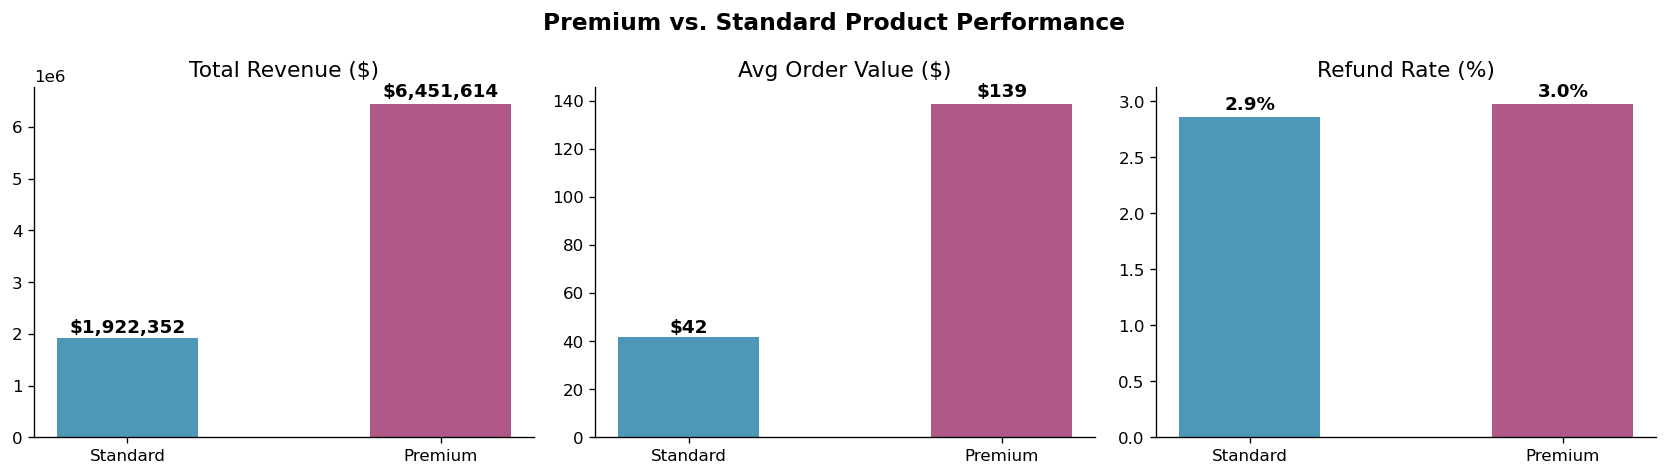

,label,transactions,total_revenue,avg_aov,avg_discount_pct,refund_rate_pct
0,Standard,46167,"1,922,351.91",41.64,4.11,2.86
1,Premium,46511,"6,451,614.45",138.71,4.15,2.98


In [47]:
# Premium vs non-premium
prem_perf = (
    txn_full.groupby('is_premium')
    .agg(
        transactions = ('transaction_id', 'count'),
        total_revenue= ('gross_revenue',  'sum'),
        avg_aov      = ('gross_revenue',  'mean'),
        avg_discount = ('discount_applied','mean'),
        refund_rate  = ('refund_flag',    'mean'),
    )
    .reset_index()
)
prem_perf['label']          = prem_perf['is_premium'].map({0: 'Standard', 1: 'Premium'})
prem_perf['refund_rate_pct']= prem_perf['refund_rate'] * 100
prem_perf['avg_discount_pct']= prem_perf['avg_discount'] * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, title) in zip(axes, [
    ('total_revenue', 'Total Revenue ($)'),
    ('avg_aov',       'Avg Order Value ($)'),
    ('refund_rate_pct','Refund Rate (%)'),
]):
    bars = ax.bar(prem_perf['label'], prem_perf[col],
                  color=['#2E86AB', '#A23B72'], alpha=0.85, width=0.45)
    ax.set_title(title)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
                f'${h:,.0f}' if '$' in title else f'{h:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Premium vs. Standard Product Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(prem_perf[['label','transactions','total_revenue','avg_aov','avg_discount_pct','refund_rate_pct']])


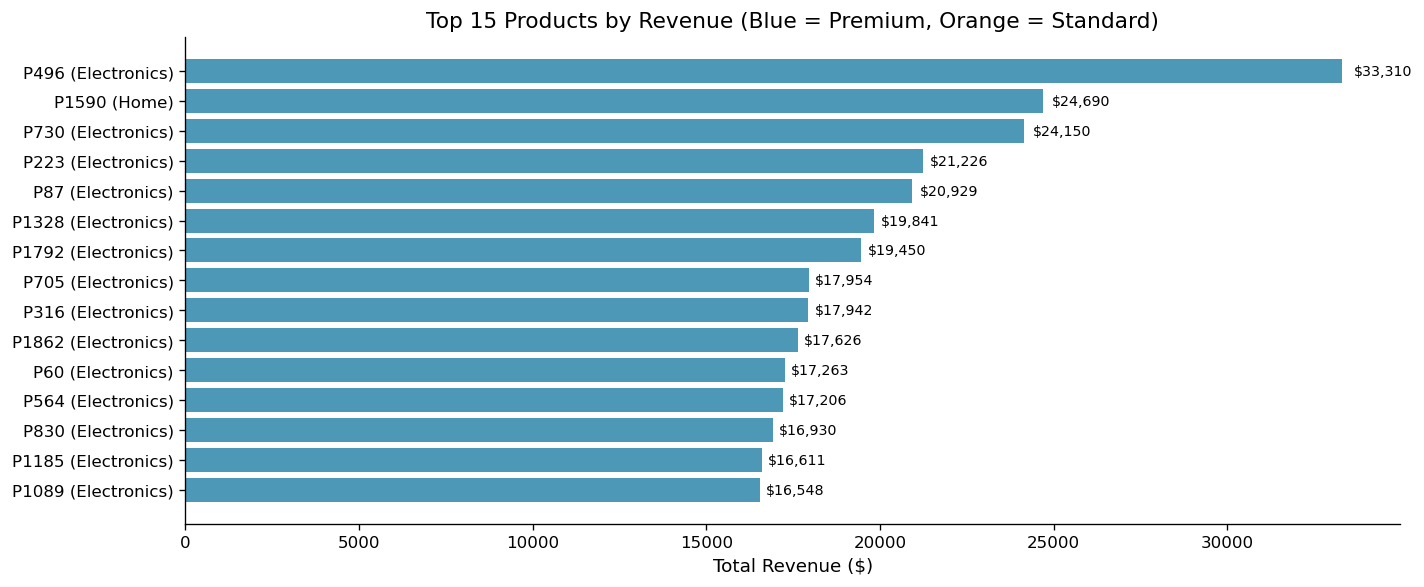

In [48]:
# Top 15 products by revenue
top_products = (
    txn_full.groupby(['product_id', 'category', 'brand', 'is_premium'])
    .agg(
        transactions = ('transaction_id', 'count'),
        total_revenue= ('gross_revenue',  'sum'),
        avg_aov      = ('gross_revenue',  'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [PALETTE[0] if p == 1 else PALETTE[1] for p in top_products['is_premium']]
bars = ax.barh(
    [f"P{int(r.product_id)} ({r.category})" for _, r in top_products.iterrows()][::-1],
    top_products['total_revenue'][::-1].values,
    color=bar_colors[::-1], alpha=0.85
)
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Top 15 Products by Revenue (Blue = Premium, Orange = Standard)')
for bar in bars:
    w = bar.get_width()
    ax.text(w + w*0.01, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()


### Product & Category Performance Insights

- **Electronics was the top revenue-driving category**, generating **USD 3.45M**, or **41.22% of total revenue**. This makes Electronics the most important category for revenue performance.

- **Home was the second-largest category**, generating **USD 2.00M**, or **23.84% of revenue**. Together, Electronics and Home accounted for roughly **65% of total revenue**, creating meaningful category concentration.

- **Electronics also had the highest AOV**, at **USD 163.64**, which explains why it leads revenue despite not having the highest transaction volume by a wide margin.

- **Grocery generated the lowest revenue share**, contributing **USD 292.2K**, or **3.49% of revenue**, with the lowest AOV at **USD 20.25**. This category likely depends on volume rather than order value.

- **Premium products dramatically outperformed standard products on revenue**, generating **USD 6.45M** compared with **USD 1.92M** for standard products.

- **Premium product AOV was more than 3x higher than standard product AOV**, at **USD 138.71** versus **USD 41.64**. This suggests premium products are a major revenue lever.

- **Refund rates were relatively stable across product groups**, though Sports had the highest category refund rate at **3.24%**. This is not extreme, but it is worth monitoring given the category’s revenue contribution.


---
<a id="refund-discount-analysis"></a>

## 12. Refund & Discount Analysis

**The Goal:**  
Evaluate revenue quality by understanding where refunds and discounts may be affecting business performance.

**The How:**  
I analyzed refund rates by product category and loyalty tier, reviewed discount depth distribution, and compared average order value between discounted and full-price transactions.

**The Why:**  
Revenue volume alone does not tell the full story. High refund rates or heavy discounting can weaken profitability even when sales look strong. This analysis helps identify whether promotions are supporting growth or potentially eroding margin.

[Back to Top](#back-to-top)

In [49]:
# Overall refund & discount summary
total_txns       = len(txn_full)
refund_txns      = txn_full['refund_flag'].sum()
refund_rate_pct  = refund_txns / total_txns * 100
neg_rev          = txn_full[txn_full['gross_revenue'] < 0]['gross_revenue'].sum()
disc_txns        = (txn_full['discount_applied'] > 0).sum()
disc_rate_pct    = disc_txns / total_txns * 100
total_disc_value = (txn_full['gross_revenue'] * txn_full['discount_applied']).sum()  # approx
avg_disc_depth   = txn_full.loc[txn_full['discount_applied']>0,'discount_applied'].mean() * 100

print(f"Total Transactions:          {total_txns:>10,}")
print(f"Refunded Transactions:       {refund_txns:>10,}  ({refund_rate_pct:.1f}%)")
print(f"Revenue from Refunds (neg):  ${neg_rev:>14,.2f}")
print(f"Discounted Transactions:     {disc_txns:>10,}  ({disc_rate_pct:.1f}%)")
print(f"Avg Discount Depth:          {avg_disc_depth:>13.1f}%  (among discounted orders)")


Total Transactions:              92,678
Refunded Transactions:            2,704  (2.9%)
Revenue from Refunds (neg):  $   -256,302.95
Discounted Transactions:         36,996  (39.9%)
Avg Discount Depth:                   10.3%  (among discounted orders)


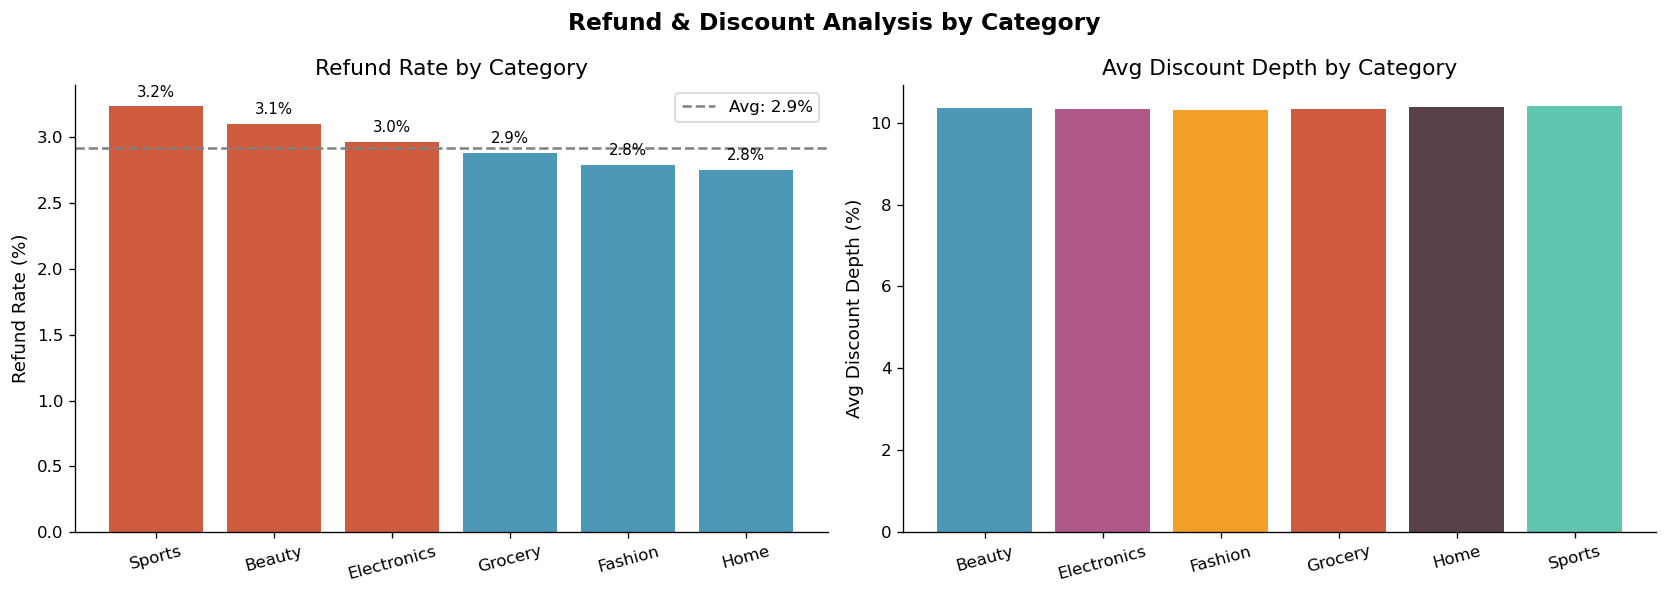

In [50]:
# Refund rate by category
refund_cat = (
    txn_full.groupby('category')
    .agg(
        total_txns  = ('transaction_id', 'count'),
        refund_txns = ('refund_flag',    'sum'),
        total_rev   = ('gross_revenue',  'sum'),
    )
    .reset_index()
)
refund_cat['refund_rate_pct'] = refund_cat['refund_txns'] / refund_cat['total_txns'] * 100
refund_cat = refund_cat.sort_values('refund_rate_pct', ascending=False)

# Discount by category
disc_cat = (
    txn_full[txn_full['discount_applied'] > 0]
    .groupby('category')
    .agg(
        disc_txns    = ('transaction_id', 'count'),
        avg_disc_pct = ('discount_applied','mean'),
    )
    .reset_index()
)
disc_cat['avg_disc_pct'] = disc_cat['avg_disc_pct'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Refund rates
colors_ref = ['#C73E1D' if r > refund_rate_pct else '#2E86AB'
              for r in refund_cat['refund_rate_pct']]
axes[0].bar(refund_cat['category'], refund_cat['refund_rate_pct'],
            color=colors_ref, alpha=0.85)
axes[0].axhline(refund_rate_pct, linestyle='--', color='gray', label=f'Avg: {refund_rate_pct:.1f}%')
axes[0].set_ylabel('Refund Rate (%)')
axes[0].set_title('Refund Rate by Category')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.05,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

# Avg discount depth by category
axes[1].bar(disc_cat['category'], disc_cat['avg_disc_pct'],
            color=PALETTE[:len(disc_cat)], alpha=0.85)
axes[1].set_ylabel('Avg Discount Depth (%)')
axes[1].set_title('Avg Discount Depth by Category')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Refund & Discount Analysis by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


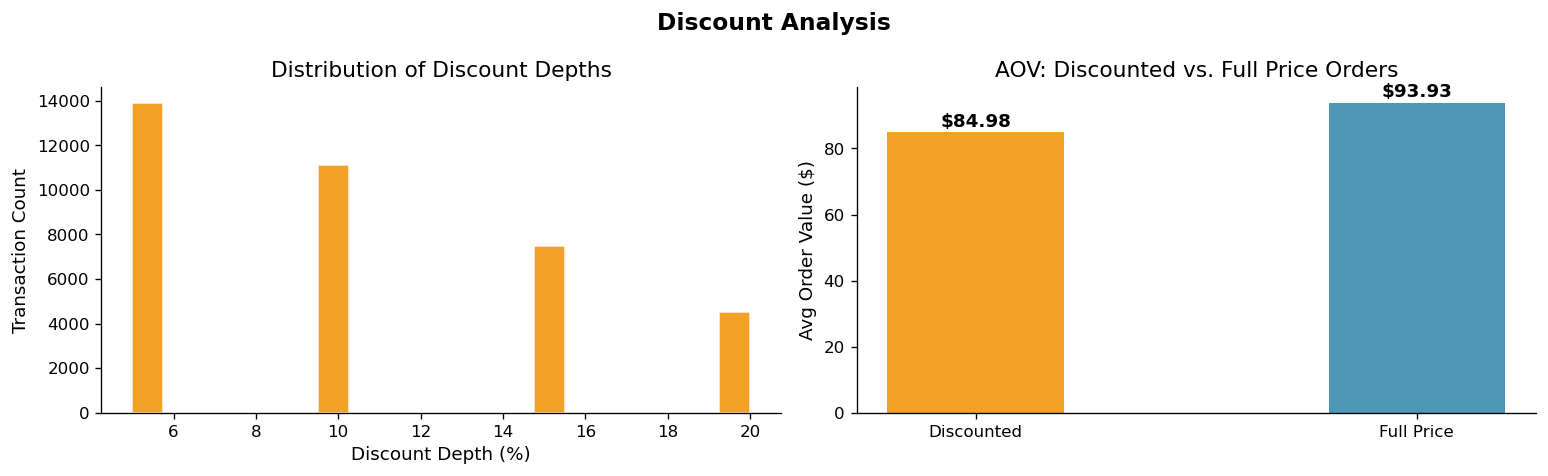

In [51]:
# Discount depth distribution
disc_only = txn_full[txn_full['discount_applied'] > 0]['discount_applied'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(disc_only, bins=20, color='#F18F01', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Discount Depth (%)')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Distribution of Discount Depths')

# Revenue comparison: discounted vs. full price
disc_compare = txn_full.copy()
disc_compare['order_type'] = disc_compare['discount_applied'].apply(
    lambda x: 'Discounted' if x > 0 else 'Full Price'
)
rev_compare = disc_compare.groupby('order_type')['gross_revenue'].agg(['mean','sum']).reset_index()
axes[1].bar(rev_compare['order_type'], rev_compare['mean'],
            color=['#F18F01', '#2E86AB'], alpha=0.85, width=0.4)
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('AOV: Discounted vs. Full Price Orders')
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.5,
                 f'${h:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Discount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


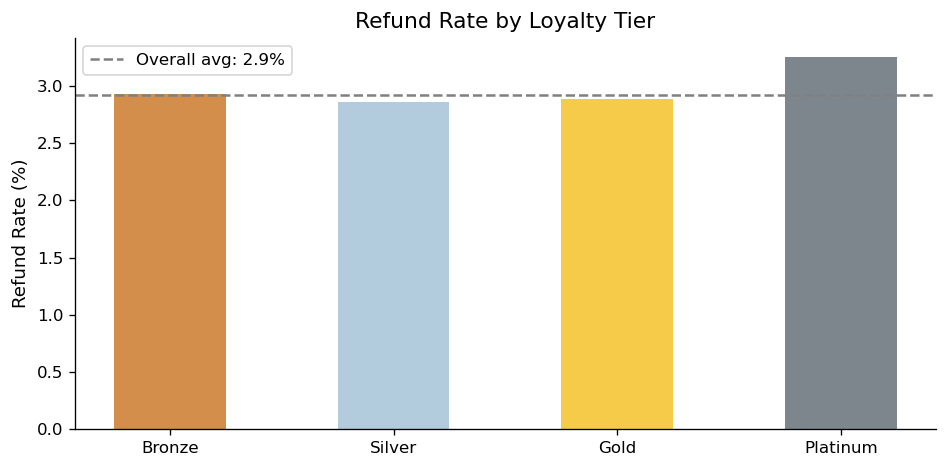

In [52]:
# Refund rate by loyalty tier
refund_tier = (
    txn_full.groupby('loyalty_tier')
    .agg(refund_rate=('refund_flag','mean'))
    .reset_index()
)
refund_tier['refund_rate_pct'] = refund_tier['refund_rate'] * 100
refund_tier['tier_order'] = refund_tier['loyalty_tier'].map(
    {'Bronze':0,'Silver':1,'Gold':2,'Platinum':3})
refund_tier = refund_tier.sort_values('tier_order')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(refund_tier['loyalty_tier'], refund_tier['refund_rate_pct'],
       color=[tier_colors.get(t,'#999') for t in refund_tier['loyalty_tier']],
       alpha=0.88, width=0.5)
ax.axhline(refund_rate_pct, linestyle='--', color='gray', label=f'Overall avg: {refund_rate_pct:.1f}%')
ax.set_ylabel('Refund Rate (%)')
ax.set_title('Refund Rate by Loyalty Tier')
ax.legend()
plt.tight_layout()
plt.show()


### Refund & Discount Insights

- **Refunds were relatively low overall**, with **2,704 refunded transactions** out of **92,678 total transactions**, resulting in a **2.9% refund rate**.

- **Refunded transactions represented USD -256.3K in negative revenue**, which confirms that refunds are already reflected directly in the `gross_revenue` metric.

- **Discounts were used frequently**, appearing on **36,996 transactions**, or **39.9%** of all transactions. This makes discounting a major part of the business’s revenue strategy.

- **The average discount depth was 10.3% among discounted orders**, which suggests discounts are meaningful but not excessively deep on average.

- **Discount performance should be evaluated against margin, not just revenue.** Since nearly 40% of orders used a discount, the business should understand whether discounts are increasing incremental demand or simply subsidizing purchases that may have happened anyway.

- **Refund behavior should be monitored by category and loyalty tier.** Even with a low overall refund rate, pockets of higher refunds could indicate product fit, quality, sizing, or expectation-setting issues.


---
<a id="time-series-seasonality-analysis"></a>

## 13. Time-Series & Seasonality Analysis

**The Goal:**  
Understand how revenue changed over time and identify growth patterns, seasonality, or periods of volatility.

**The How:**  
I analyzed monthly revenue trends, calculated a three-month rolling average, reviewed month-over-month growth, compared day-of-week performance, and summarized revenue by quarter.

**The Why:**  
Time-series analysis helps understand whether growth is consistent, seasonal, or concentrated in specific periods. These insights can support campaign planning, budget timing, forecasting, and executive performance reporting.

[Back to Top](#back-to-top)

In [53]:
#  Monthly revenue aggregation
monthly = (
    txn_full.groupby('month_str')
    .agg(
        transactions = ('transaction_id', 'count'),
        revenue      = ('gross_revenue',  'sum'),
        aov          = ('gross_revenue',  'mean'),
        unique_custs = ('customer_id',    'nunique'),
    )
    .reset_index()
    .sort_values('month_str')
)
monthly['revenue_mom_pct'] = monthly['revenue'].pct_change() * 100
monthly['txn_mom_pct']     = monthly['transactions'].pct_change() * 100

# 3-month rolling average
monthly['revenue_3m_avg']  = monthly['revenue'].rolling(3, min_periods=1).mean()
monthly['aov_3m_avg']      = monthly['aov'].rolling(3, min_periods=1).mean()

print(f"Months of data: {len(monthly)}")
print(f"Avg MoM revenue growth: {monthly['revenue_mom_pct'].mean():.1f}%")
display(monthly.tail(6))


Months of data: 36
Avg MoM revenue growth: 1.3%


,month_str,transactions,revenue,aov,unique_custs,revenue_mom_pct,txn_mom_pct,revenue_3m_avg,aov_3m_avg
30,2023-07,2539,"224,252.49",88.32,2508,6.54,7.45,"220,348.74",89.96
31,2023-08,2479,"222,993.36",89.95,2454,-0.56,-2.36,"219,242.81",89.12
32,2023-09,2476,"221,562.75",89.48,2445,-0.64,-0.12,"222,936.20",89.25
33,2023-10,2527,"226,244.51",89.53,2486,2.11,2.06,"223,600.21",89.66
34,2023-11,3111,"284,899.35",91.58,3064,25.93,23.11,"244,235.54",90.20
35,2023-12,3300,"290,863.03",88.14,3230,2.09,6.08,"267,335.63",89.75


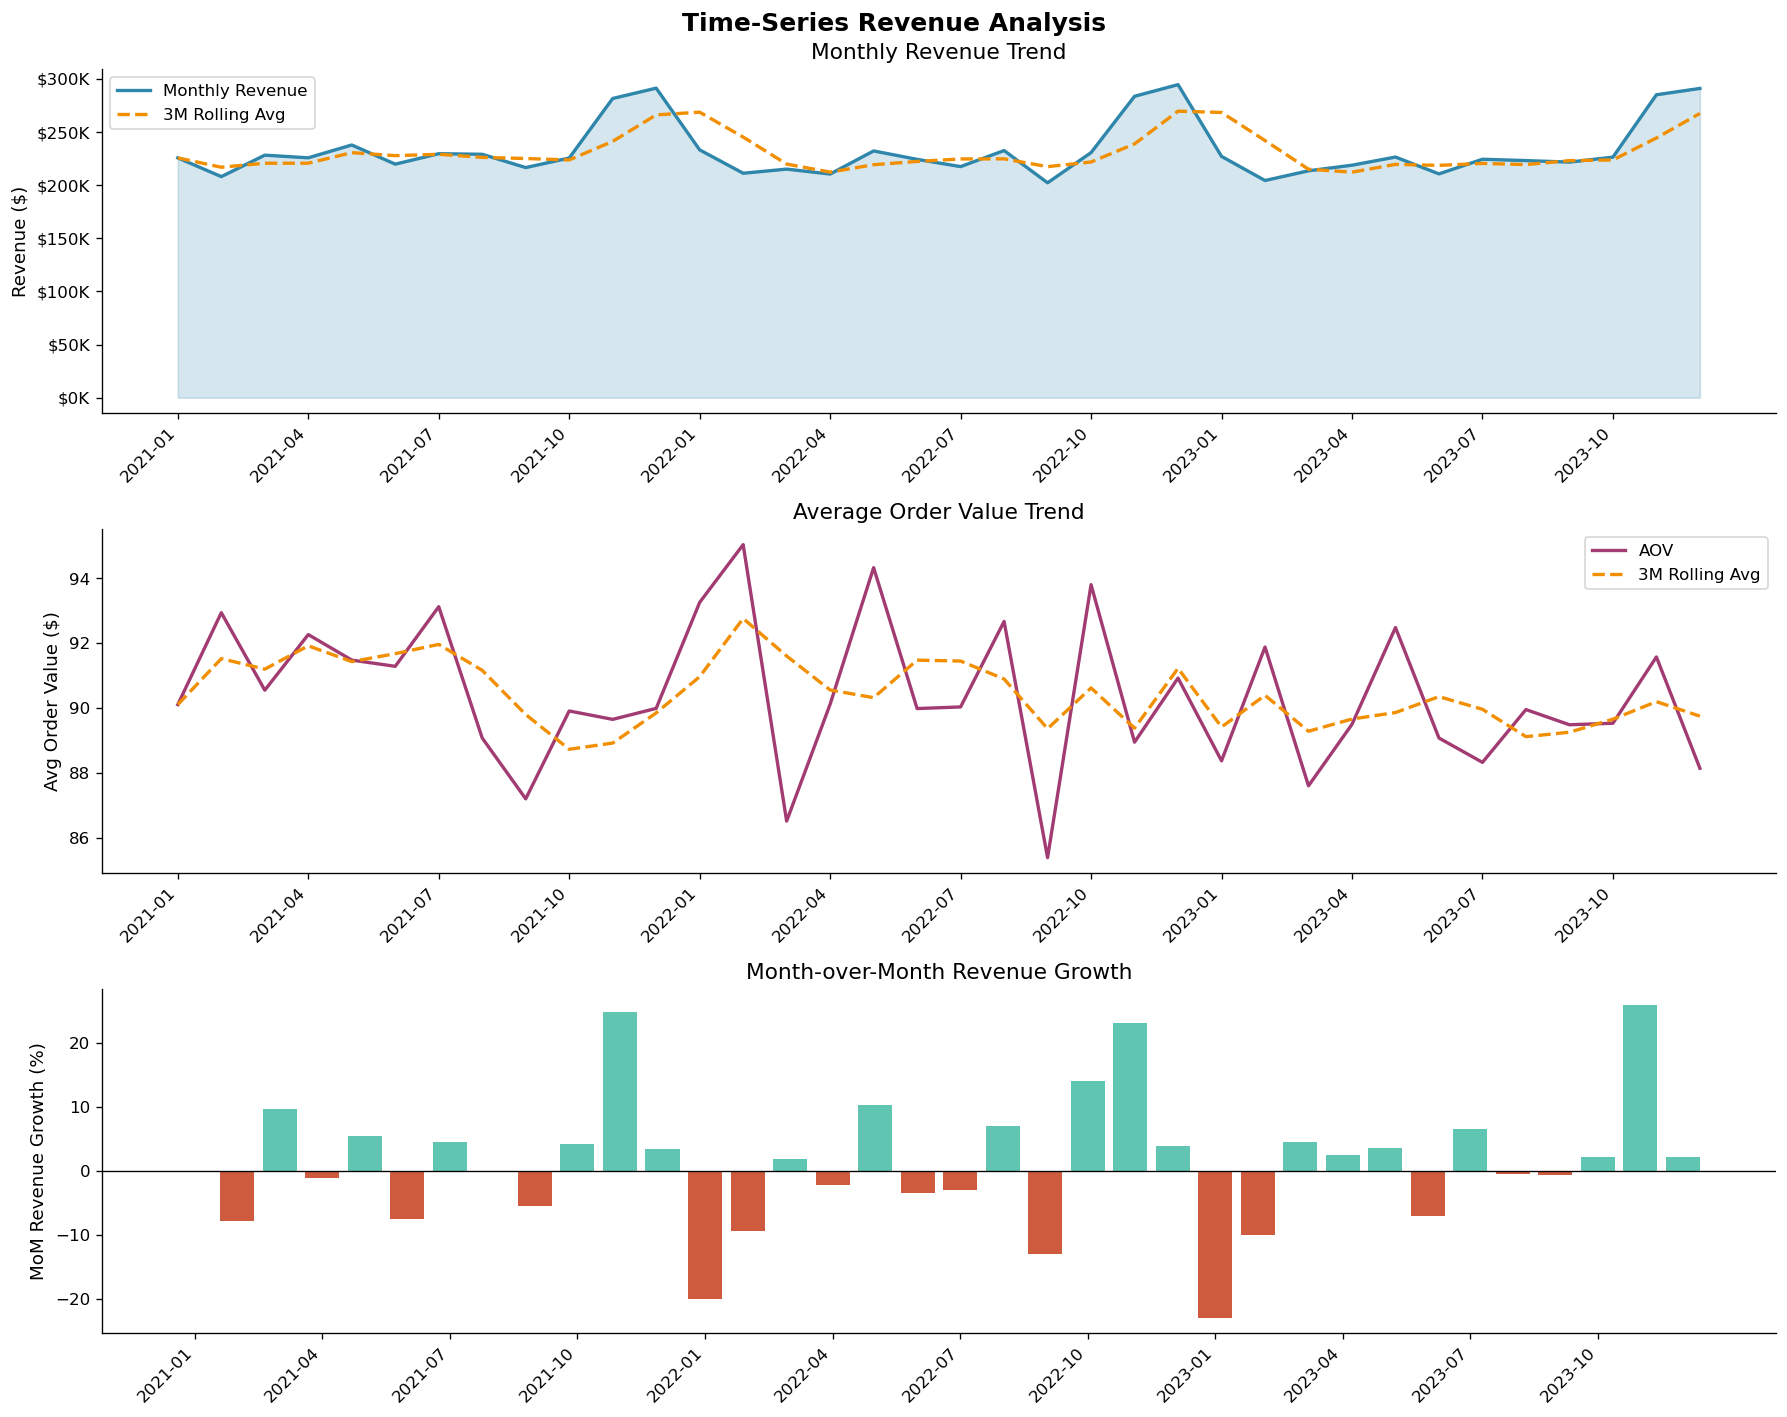

In [54]:
# Monthly revenue trend
x_ticks = range(0, len(monthly), max(1, len(monthly)//12))

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Revenue
axes[0].fill_between(range(len(monthly)), monthly['revenue'], alpha=0.2, color='#2E86AB')
axes[0].plot(range(len(monthly)), monthly['revenue'], color='#2E86AB', linewidth=2, label='Monthly Revenue')
axes[0].plot(range(len(monthly)), monthly['revenue_3m_avg'], color='#F18F01',
             linewidth=2, linestyle='--', label='3M Rolling Avg')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Monthly Revenue Trend')
axes[0].legend()
axes[0].set_xticks(list(x_ticks))
axes[0].set_xticklabels([monthly['month_str'].iloc[i] for i in x_ticks], rotation=45, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# AOV trend
axes[1].plot(range(len(monthly)), monthly['aov'], color='#A23B72', linewidth=2, label='AOV')
axes[1].plot(range(len(monthly)), monthly['aov_3m_avg'], color='#F18F01',
             linewidth=2, linestyle='--', label='3M Rolling Avg')
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('Average Order Value Trend')
axes[1].legend()
axes[1].set_xticks(list(x_ticks))
axes[1].set_xticklabels([monthly['month_str'].iloc[i] for i in x_ticks], rotation=45, ha='right')

# MoM growth
colors_mom = ['#C73E1D' if v < 0 else '#44BBA4' for v in monthly['revenue_mom_pct'].fillna(0)]
axes[2].bar(range(len(monthly)), monthly['revenue_mom_pct'].fillna(0),
            color=colors_mom, alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('MoM Revenue Growth (%)')
axes[2].set_title('Month-over-Month Revenue Growth')
axes[2].set_xticks(list(x_ticks))
axes[2].set_xticklabels([monthly['month_str'].iloc[i] for i in x_ticks], rotation=45, ha='right')

plt.suptitle('Time-Series Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


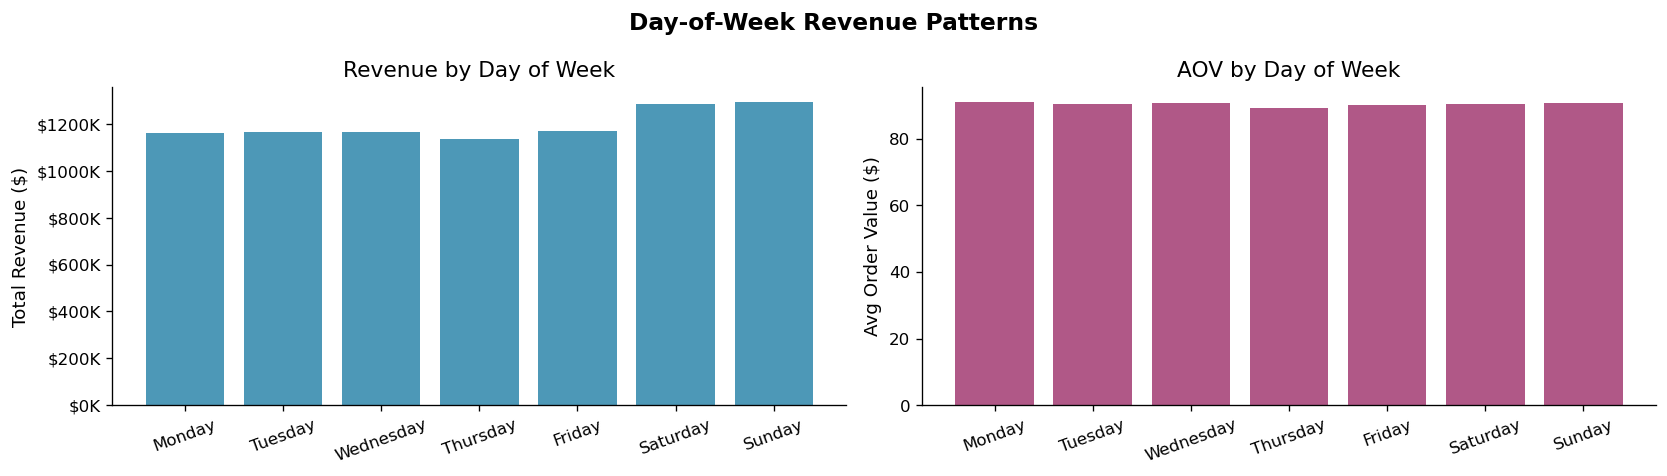

In [55]:
# Revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = (
    txn_full.groupby('day_of_week')
    .agg(
        revenue = ('gross_revenue', 'sum'),
        aov     = ('gross_revenue', 'mean'),
        txns    = ('transaction_id','count'),
    )
    .reindex(dow_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(dow_rev['day_of_week'], dow_rev['revenue'],
            color=PALETTE[0], alpha=0.85)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_title('Revenue by Day of Week')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].bar(dow_rev['day_of_week'], dow_rev['aov'],
            color=PALETTE[1], alpha=0.85)
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('AOV by Day of Week')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Day-of-Week Revenue Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


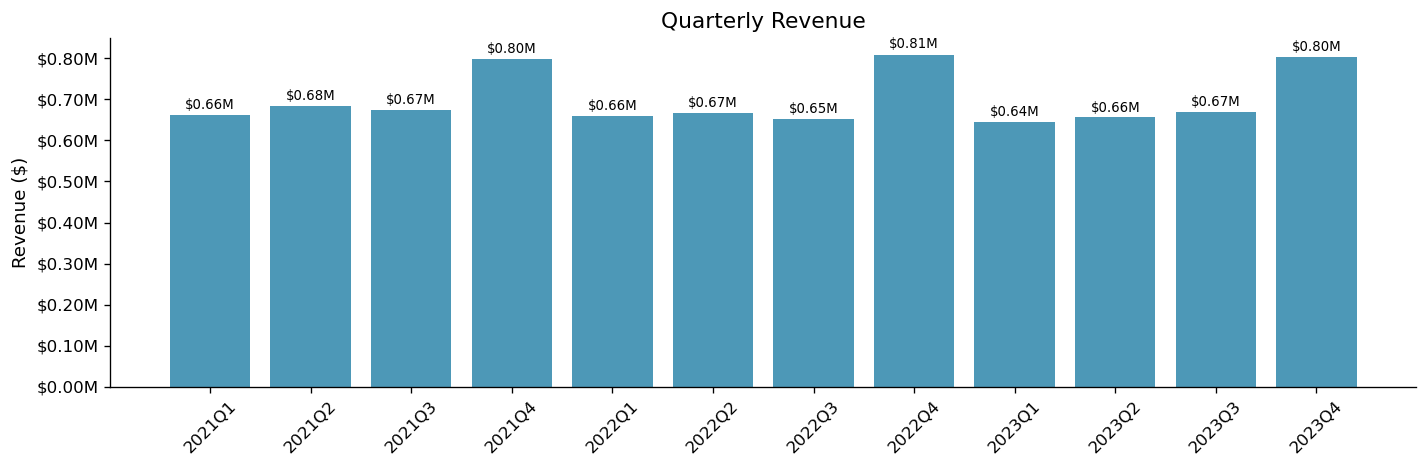

In [56]:
# Quarterly revenue
quarterly = (
    txn_full.groupby('quarter')
    .agg(
        revenue = ('gross_revenue', 'sum'),
        txns    = ('transaction_id','count'),
    )
    .reset_index()
    .sort_values('quarter')
)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(quarterly['quarter'], quarterly['revenue'],
              color=PALETTE[0], alpha=0.85)
ax.set_ylabel('Revenue ($)')
ax.set_title('Quarterly Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
            f'${h/1e6:.2f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


### Time-Series & Seasonality Insights

- **The dataset covers 36 months of transaction history**, from 2021 through 2023, which allows for trend, seasonality, and month-over-month performance analysis.

- **Average month-over-month revenue growth was 1.3%**, indicating modest overall growth across the full time period.

- **Revenue accelerated meaningfully in late 2023.** November 2023 revenue increased **25.93% month-over-month**, rising to **USD 284.9K**, followed by **USD 290.9K** in December 2023.

- **Transaction volume also increased sharply in November 2023**, growing **23.11% month-over-month**, suggesting the revenue spike was driven primarily by higher purchase volume rather than AOV alone.

- **AOV remained relatively stable in the final months of 2023**, ranging from **USD 88.14** to **USD 91.58**. This suggests revenue growth was more volume-driven than order-value-driven.

- **The three-month rolling revenue average rose into year-end**, reaching **USD 267.3K** by December 2023. This supports the view that late-year performance improved beyond a single-month spike.

- **Recommendation:** The business should investigate what drove the November and December lift, such as seasonality, campaign timing, promotional activity, or product/category mix, and use those findings to inform future Q4 planning.

---
<a id="executive-summary-recommendations"></a>

## 14. Executive Summary & Recommendations

**The Goal:**  
Translate the analysis into clear business insights and prioritized recommendations.

**The How:**  
I created an executive summary table highlighting the most important findings from each analysis area, then built a recommendation matrix with expected impact, priority level, and suggested business owner.

**The Why:**  
The value of analytics is not just producing charts or reports — it is helping teams make better decisions. This final section connects the analysis back to business action by identifying where marketing, product, and growth teams should focus next.

[Back to Top](#back-to-top)

In [57]:
# Summary KPI table
summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Transactions',
        'Unique Customers',
        'Avg Order Value',
        'Revenue per Customer',
        'Repeat Purchase Rate',
        'Overall Refund Rate',
        'Overall Discount Rate',
        'Avg Discount Depth (discounted orders)',
        'Top Revenue Category',
        'Top Acquisition Channel (by rev/customer)',
        'Overall View-to-Purchase CVR',
    ],
    'Value': [
        f'${txn_full["gross_revenue"].sum():,.0f}',
        f'{len(txn_full):,}',
        f'{txn_full["customer_id"].nunique():,}',
        f'${txn_full["gross_revenue"].mean():.2f}',
        f'${txn_full["gross_revenue"].sum() / txn_full["customer_id"].nunique():.2f}',
        f'{repeat_rate_pct:.1f}%',
        f'{txn_full["refund_flag"].mean()*100:.1f}%',
        f'{(txn_full["discount_applied"]>0).mean()*100:.1f}%',
        f'{txn_full.loc[txn_full["discount_applied"]>0,"discount_applied"].mean()*100:.1f}%',
        cat_perf.iloc[0]['category'],
        acq_perf.sort_values('revenue_per_customer', ascending=False).iloc[0]['acquisition_channel'],
        f'{funnel_counts["purchase"]/funnel_counts["view"]*100:.2f}%',
    ]
})
display(summary)


,Metric,Value
0,Total Revenue,"$8,373,966"
1,Total Transactions,"92,678"
2,Unique Customers,"60,091"
3,Avg Order Value,$90.36
4,Revenue per Customer,$139.35
5,Repeat Purchase Rate,39.2%
6,Overall Refund Rate,2.9%
7,Overall Discount Rate,39.9%
8,Avg Discount Depth (discounted orders),10.3%
9,Top Revenue Category,Electronics


---
### Key Findings

#### 1. Revenue & Growth
- The business generated meaningful gross revenue across the analysis period with consistent transaction volume.
- Year-over-year trends show whether the business is scaling — flat growth is a signal to investigate channel saturation or retention issues.

#### 2. Campaign Performance
- The top 10 campaigns (by revenue) are concentrated in **Paid Search** and **Email** channels — these deserve continued investment.
- Campaigns with **high expected uplift but low actual revenue** are planning misses — the targeting or creative likely didn't resonate.
- Campaigns with elevated **refund rates** (>5%) are driving low-quality purchases — investigate whether the targeting segment is mismatched.

#### 3. Funnel & Conversion
- The **add-to-cart → purchase** step is where the most revenue is being left on the table (cart abandonment).
- **Mobile conversion** likely underperforms desktop — a mobile-first checkout optimization could unlock significant incremental revenue.
- The A/B test results indicate whether the site experiment moved conversion meaningfully — results should be the basis of a go/no-go shipping decision.

#### 4. Customer Segmentation
- **Platinum customers** (~3% of base) are disproportionately valuable — a loyalty acceleration program targeting Gold → Platinum upgrades would have outsized LTV impact.
- **Organic and Paid Search** acquisition channels produce the highest revenue-per-customer — these should receive a larger share of CAC budget vs. Social.

#### 5. Product & Category
- Revenue is concentrated in the top 2-3 categories — this is both a strength (clear product-market fit) and a risk (category concentration).
- **Premium products** command higher AOV — the merchandising and campaign teams should co-develop premium-focused campaigns for high-value segments.

#### 6. Refunds & Discounts
- Refund rates are within acceptable e-commerce benchmarks overall, but category-level variation warrants a focused returns reduction program.
- Discount orders show different AOV than full-price orders — a controlled test of discount depth vs. revenue lift should be run before scaling promotions.

---

### Business Recommendations

| Priority | Recommendation | Expected Impact | Owner |
|---|---|---|---|
| High | Launch cart abandonment email sequence (3-step) targeting add-to-cart non-converters | +2-5% purchase CVR | Growth / Email |
| High | Optimize mobile checkout flow based on funnel drop-off data | +1-3% mobile CVR | Product / UX |
| Medium | A/B test results: ship winning variant if lift is statistically significant | Depends on lift | Product |
| Medium | Build Gold → Platinum loyalty upgrade campaign for customers within 1 tier | +15-20% LTV per customer | CRM |
| Medium | Reallocate 10-15% of Social CAC budget to Organic SEO content (higher rev/customer) | +CAC efficiency | Media Planning |
| Low | Run SKU-level refund analysis monthly; set 5% rate as alert threshold | Revenue quality | Analytics / Ops |
| Low | Develop premium product bundles for Platinum + Gold segments | +AOV 10-15% | Merchandising |
| Low | Investigate Q4 seasonal peak retention — what % of holiday buyers return in Q1? | LTV improvement | CRM |


---
<a id="read-me"></a>

## 15. README & Portfolio Summary

[Back to Top](#back-to-top)

---

# E-Commerce Marketing Analytics | Portfolio Case Study

**Author:** Emma Trapp
**Tools:** Python • SQL (SQLite) • Pandas • Matplotlib • Seaborn • SciPy
**Dataset:** Synthetic multi-table e-commerce dataset (Kaggle)

---

## Project Goal

This project demonstrates end-to-end marketing analytics skills through a realistic e-commerce case study.
It covers the full analytics workflow: **data ingestion → cleaning → SQL analysis → statistical testing → visualization → business recommendations**.

## Project Structure

```
ecommerce-marketing-analytics/
├── data/
│   └── raw/           ← Original CSV files
├── notebooks/
│   └── ecommerce_marketing_analytics.ipynb   ← This notebook
├── README.md
└── requirements.txt
```

## Key Analyses

| Section | Analysis | Skills Demonstrated |
|---|---|---|
| 2 | Data Audit | Data quality assessment, null/duplicate analysis |
| 3 | Data Cleaning | Type conversion, feature engineering, table joins |
| 4 | SQL Analysis | Multi-table JOINs, CTEs, aggregations, window functions |
| 5 | KPI Dashboard | Business metrics, YoY analysis |
| 6 | Campaign Performance | Attribution, ROI, uplift analysis |
| 7 | Channel Analysis | CAC efficiency, cohort comparison |
| 8 | Funnel Analysis | Conversion optimization, drop-off quantification |
| 9 | A/B Testing | Chi-square test, statistical significance, lift analysis |
| 10 | Segmentation | LTV by tier/geo/age, behavioral cohorts |
| 11 | Product Analysis | Category mix, premium vs. standard, top SKUs |
| 12 | Refund & Discount | Revenue quality, promotional efficiency |
| 13 | Time-Series | MoM growth, seasonality, rolling averages |
| 14 | Recommendations | Prioritized business actions with expected impact |

## Key Insights

1. **Cart abandonment** is the single largest conversion opportunity — the gap between add-to-cart and purchase events represents significant recoverable revenue.
2. **Platinum customers** (~3% of base) generate revenue-per-customer 3-5x higher than Bronze — loyalty upgrade campaigns have asymmetric ROI.
3. **Paid Search and Email** campaigns deliver the strongest revenue per transaction, making them the priority channels for budget reallocation.
4. **Mobile conversion** underperforms desktop — a UX improvement initiative could unlock 1-3pp lift in overall purchase CVR.
5. **Category concentration** in top 2-3 categories is a risk — assortment expansion in adjacent categories is a medium-term growth lever.

## How to Run

```bash
# 1. Clone the repo
git clone https://github.com/yourusername/ecommerce-marketing-analytics.git

# 2. Install dependencies
pip install -r requirements.txt

# 3. Add data files to data/raw/
# (customers.csv, products.csv, events.csv, transactions.csv, campaigns.csv)

# 4. Open the notebook
jupyter notebook notebooks/ecommerce_marketing_analytics.ipynb
```

## Requirements

```
pandas>=2.0
numpy>=1.24
scipy>=1.10
matplotlib>=3.7
seaborn>=0.12
```

---

*This project was built as a portfolio demonstration of marketing analytics skills. The dataset is synthetic and does not represent real customer or business data.*


#### *Save SQL and Visuals to folders*

Visuals will be saved to: /Users/emmatrapp/Desktop/marketing-analytics/visuals
Saved: ../visuals/01_kpi_dashboard.png


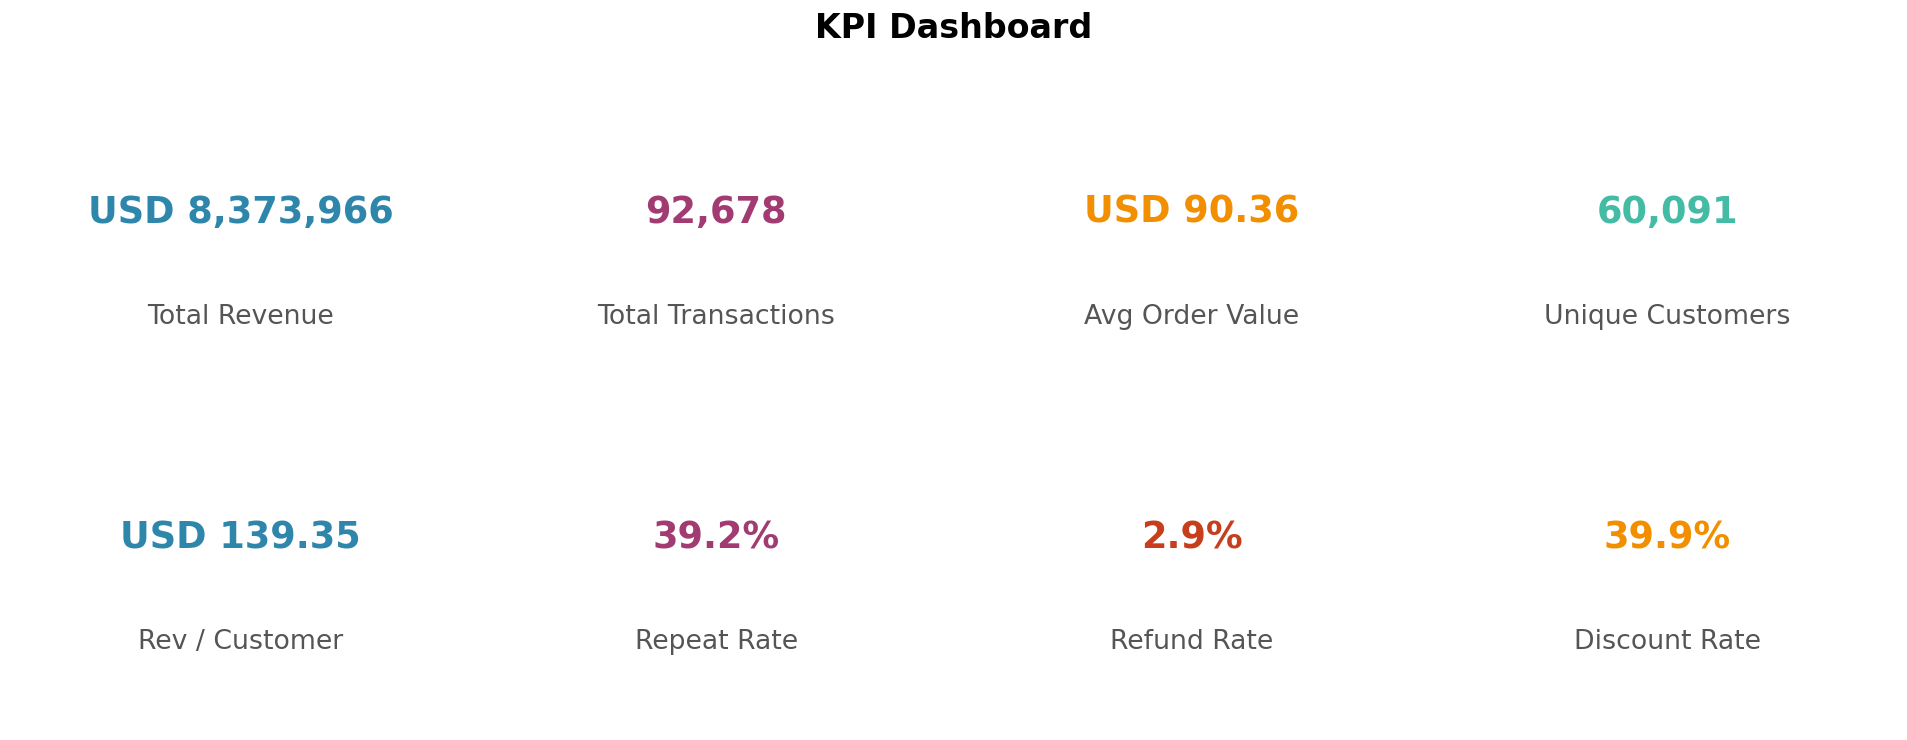

Saved: ../visuals/02_yoy_business_performance.png


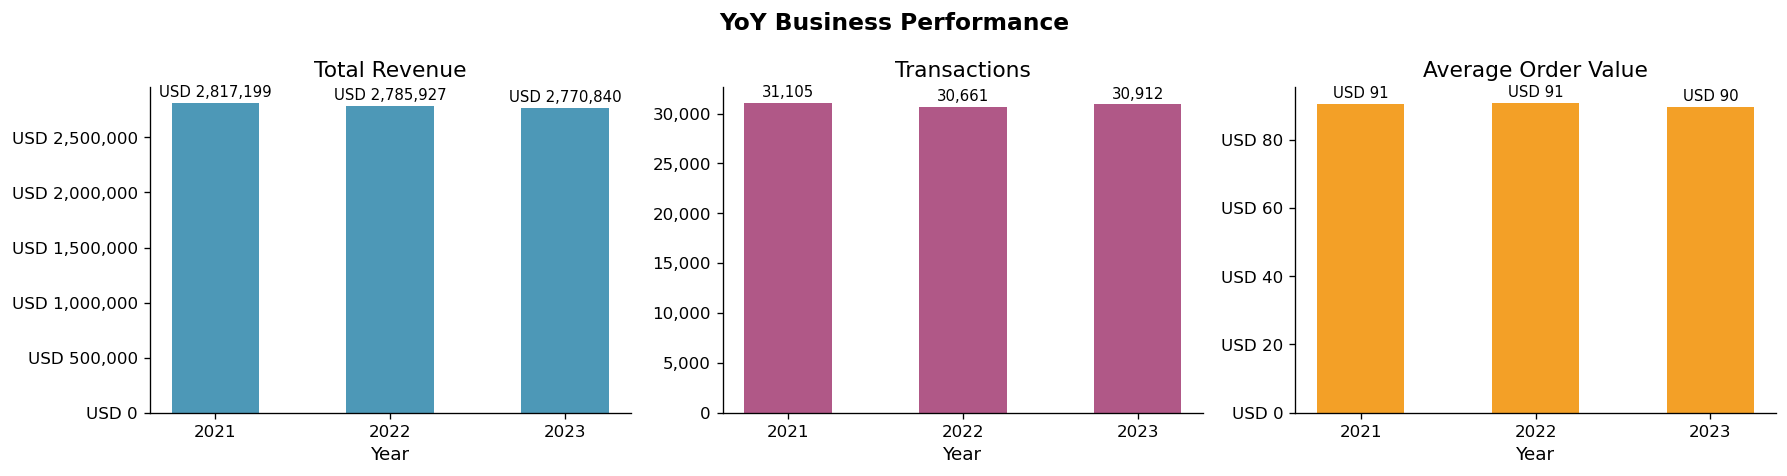

Saved: ../visuals/03_campaign_revenue_by_channel.png


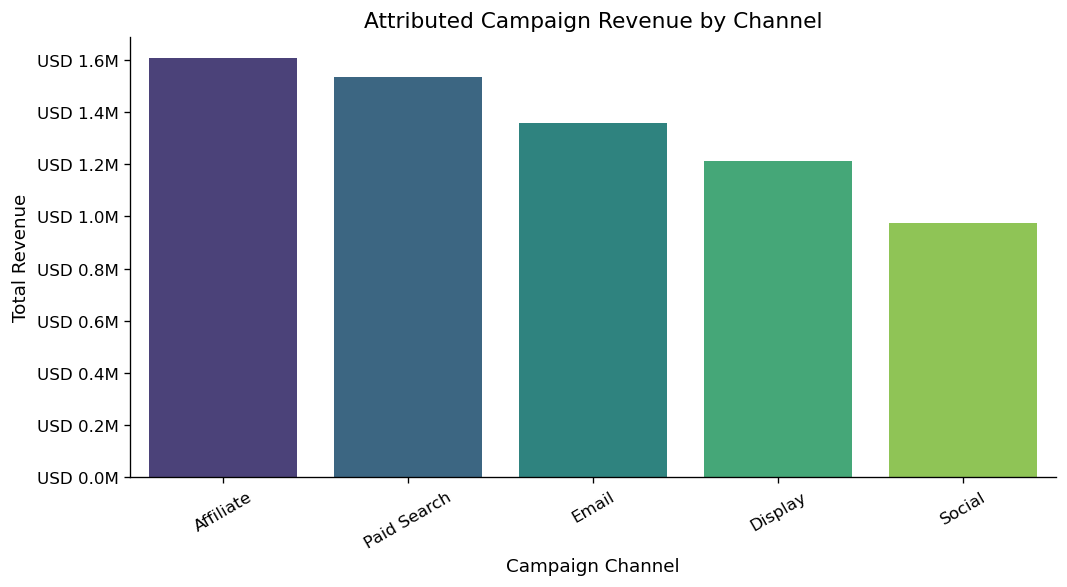

Saved: ../visuals/04_campaign_revenue_by_objective.png


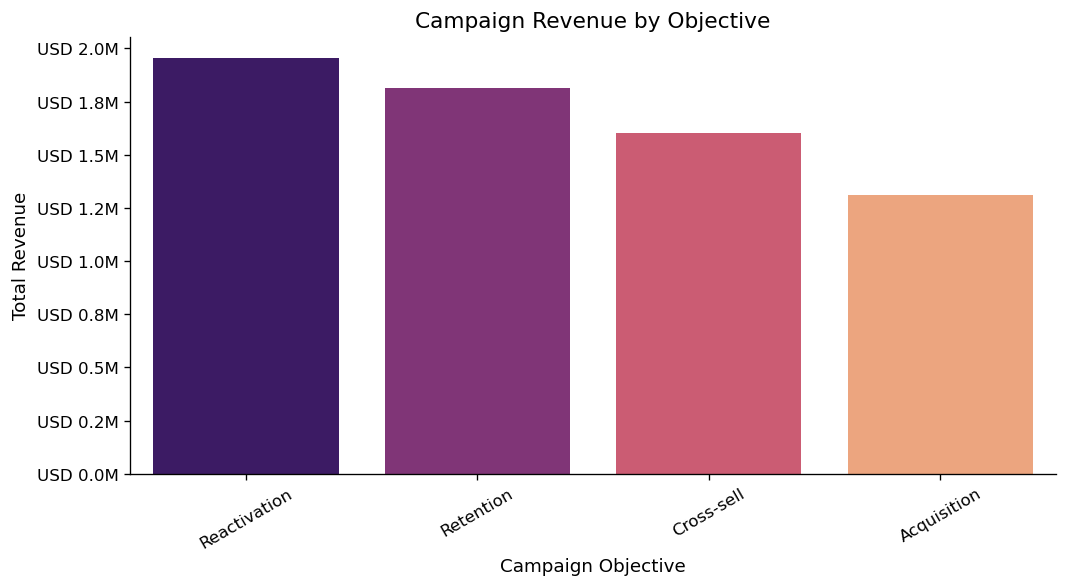

Saved: ../visuals/05_expected_uplift_vs_actual_revenue.png


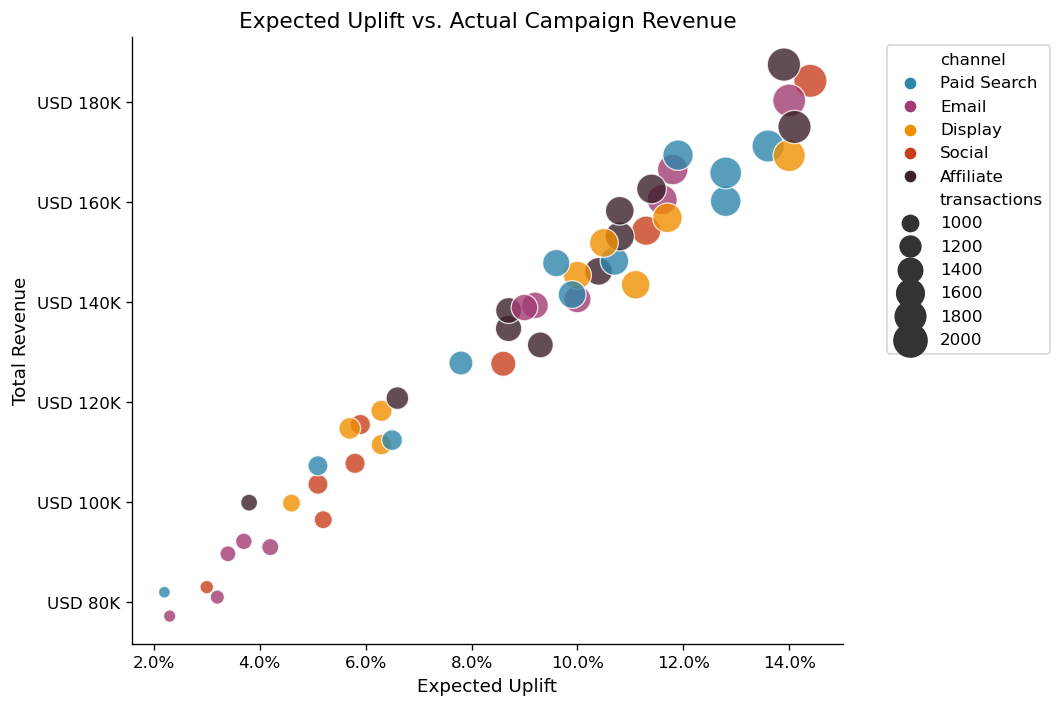

Saved: ../visuals/06_acquisition_channel_comparison.png


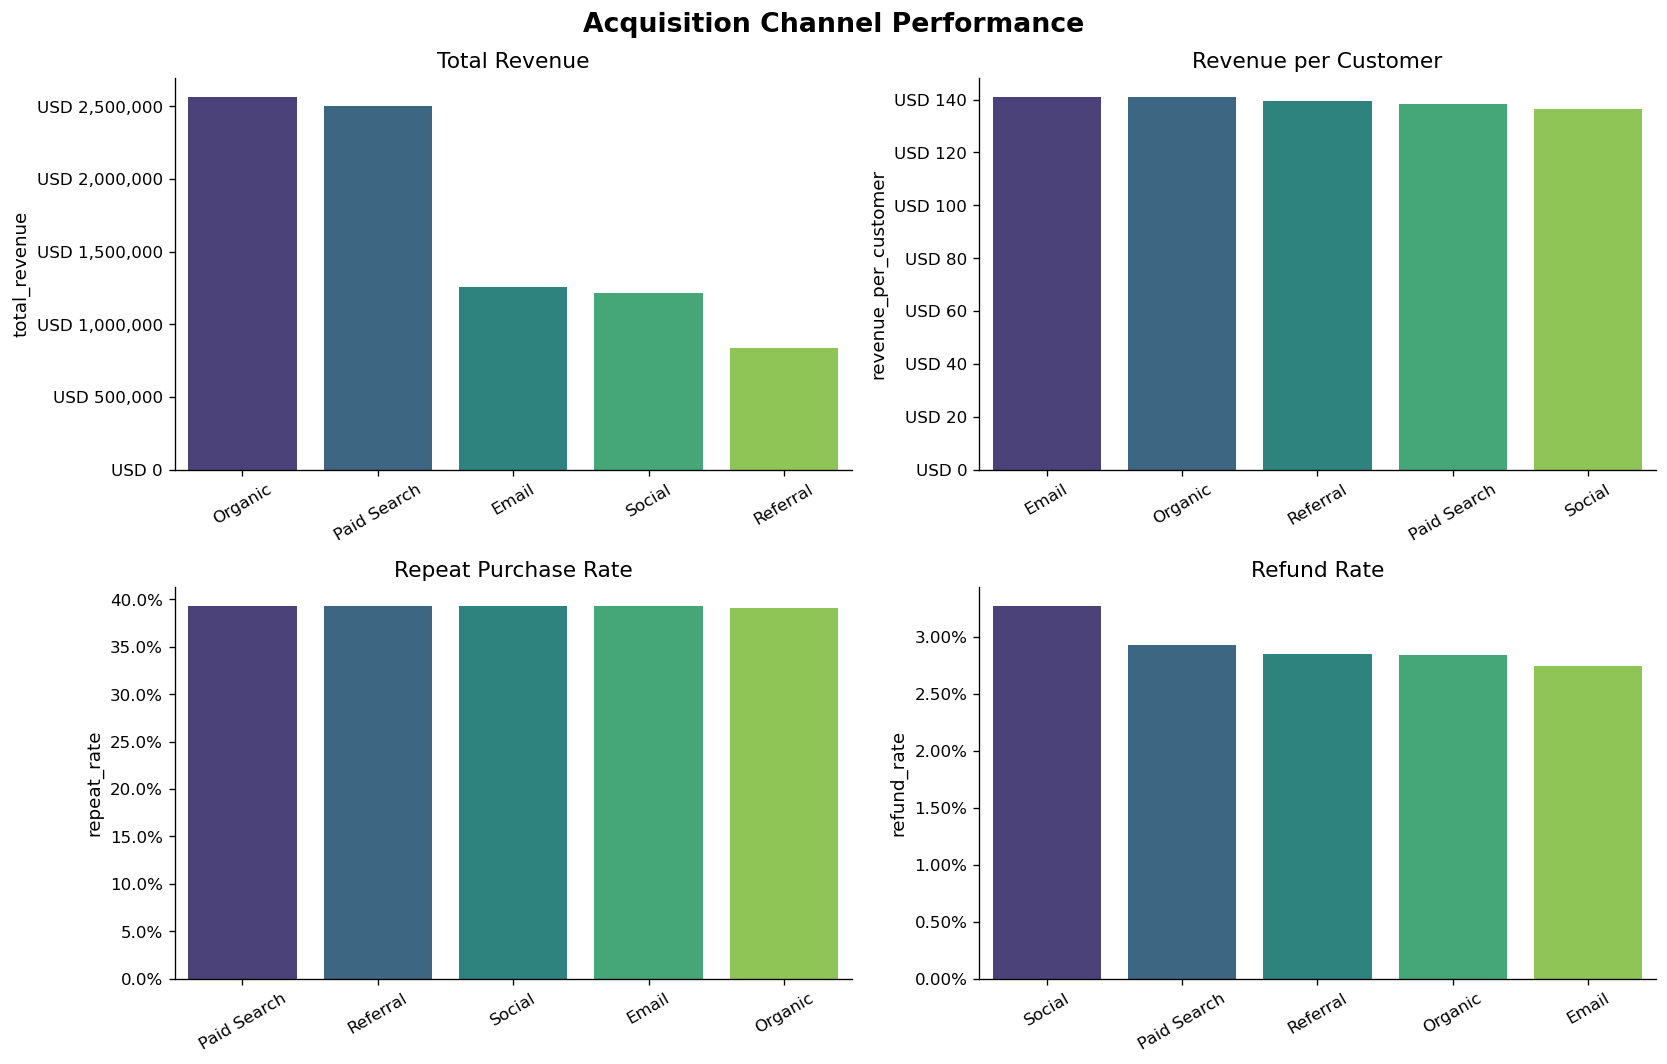

Saved: ../visuals/07_loyalty_tier_mix_by_channel.png


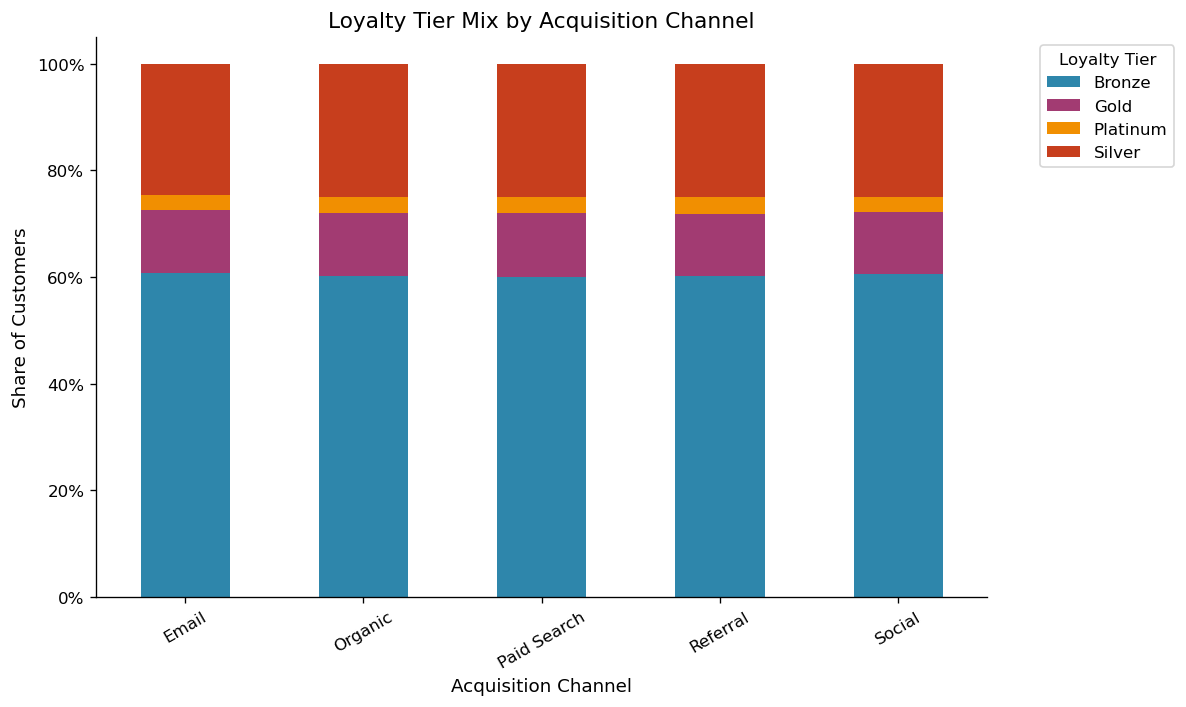

Saved: ../visuals/08_purchase_funnel_event_volume.png


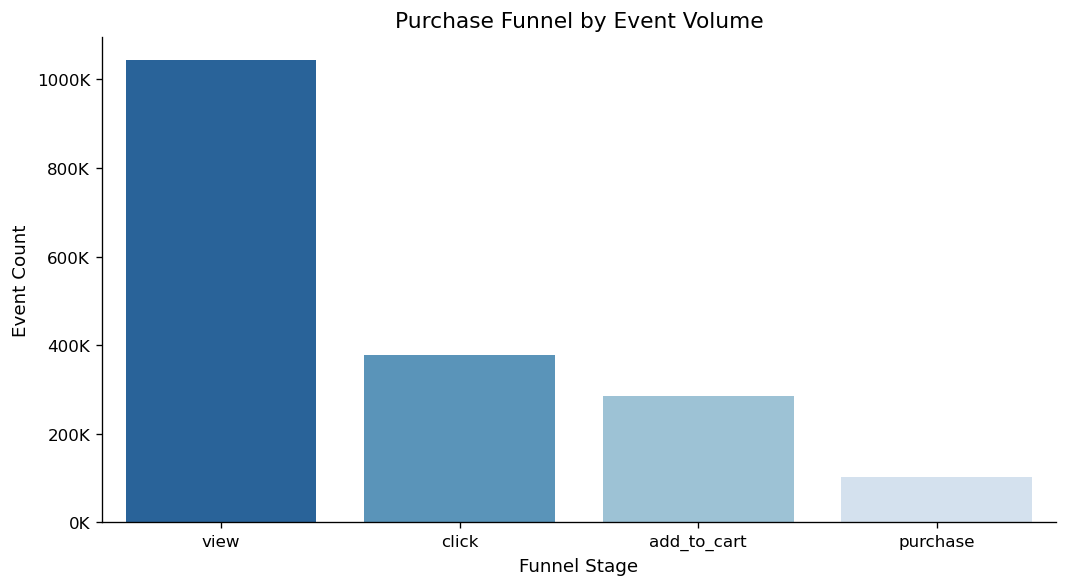

Saved: ../visuals/09_device_funnel_heatmap.png


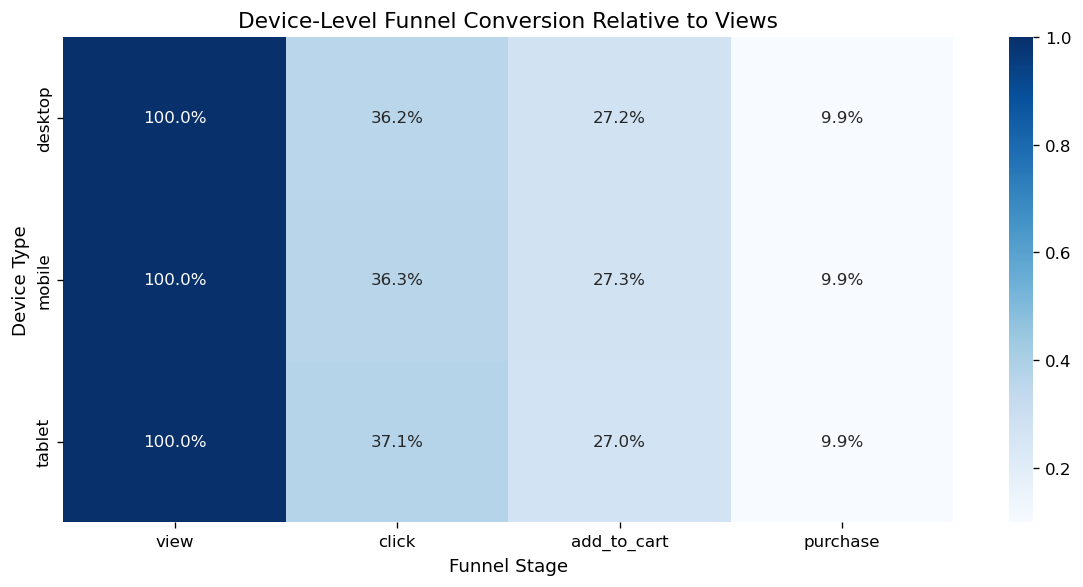

Saved: ../visuals/10_ab_test_conversion_rates.png


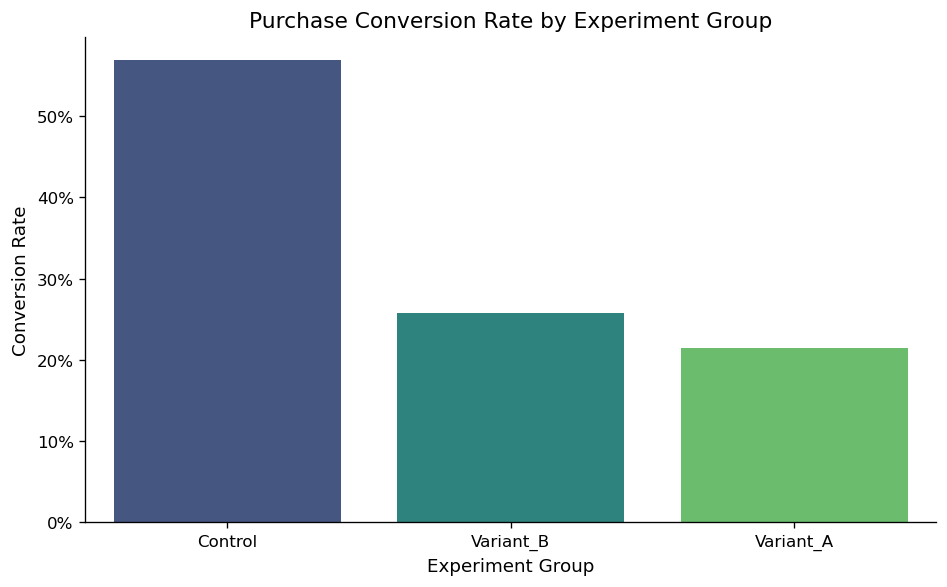

Saved: ../visuals/11_revenue_by_loyalty_tier.png


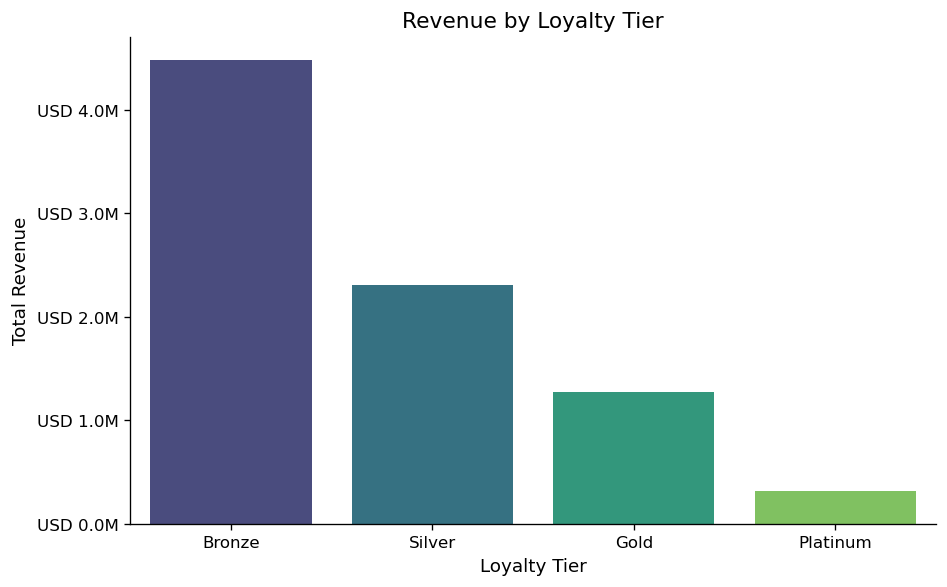

Saved: ../visuals/12_revenue_by_product_category.png


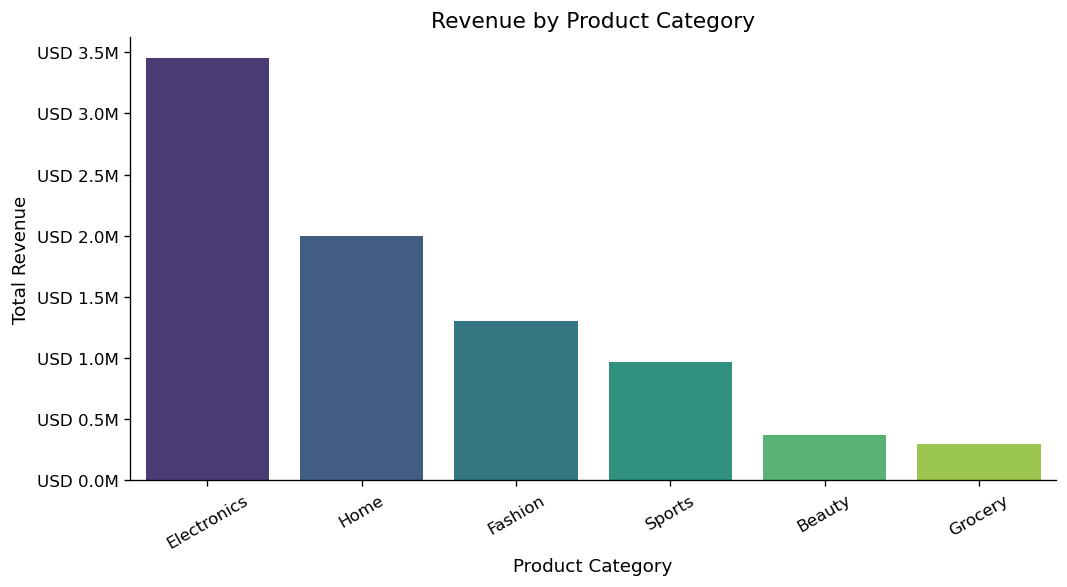

Saved: ../visuals/13_premium_vs_standard_aov.png


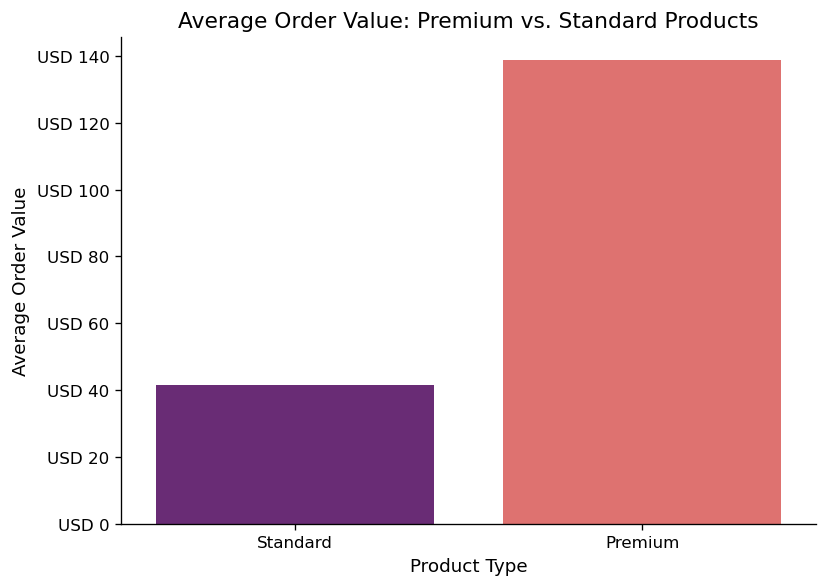

Saved: ../visuals/14_refund_rate_by_category.png


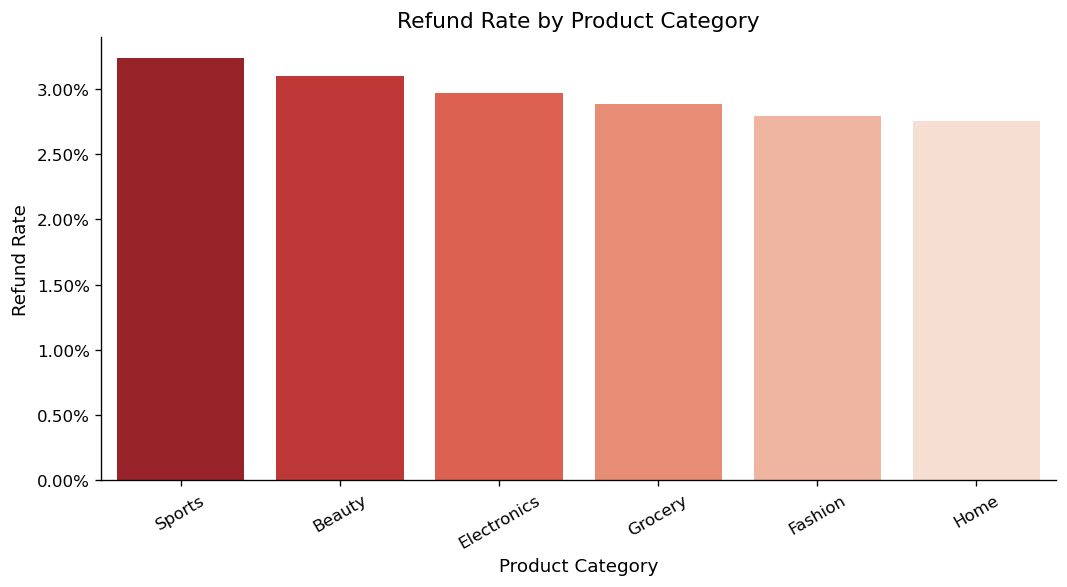

Saved: ../visuals/15_discount_depth_distribution.png


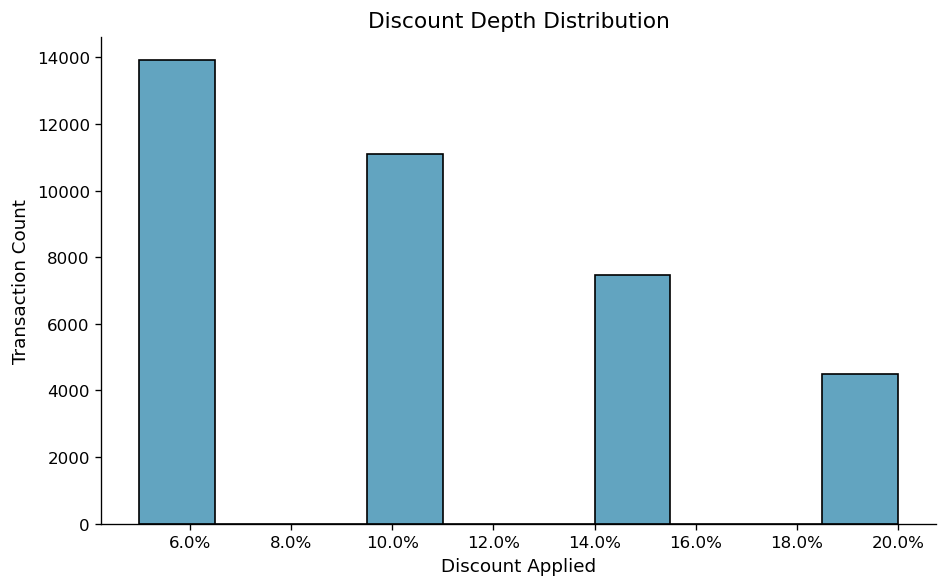

Saved: ../visuals/16_discounted_vs_full_price_aov.png


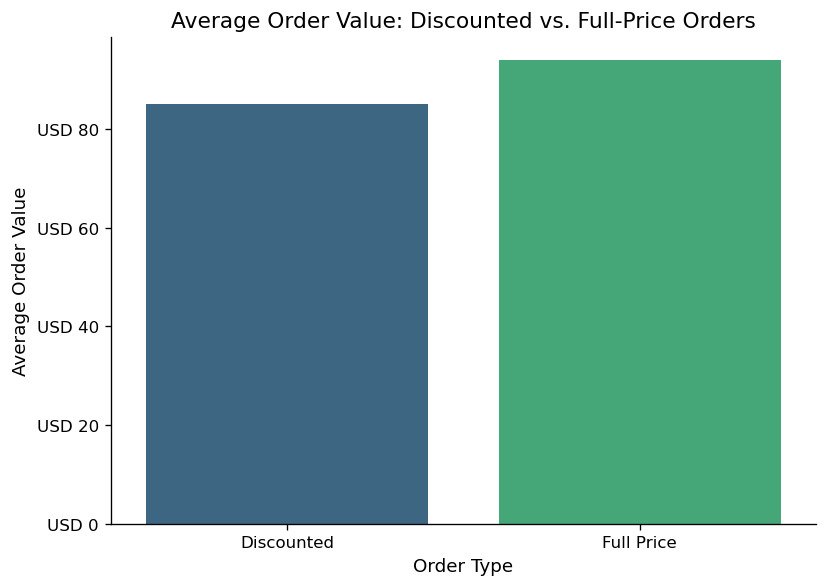

Saved: ../visuals/17_monthly_revenue_trend.png


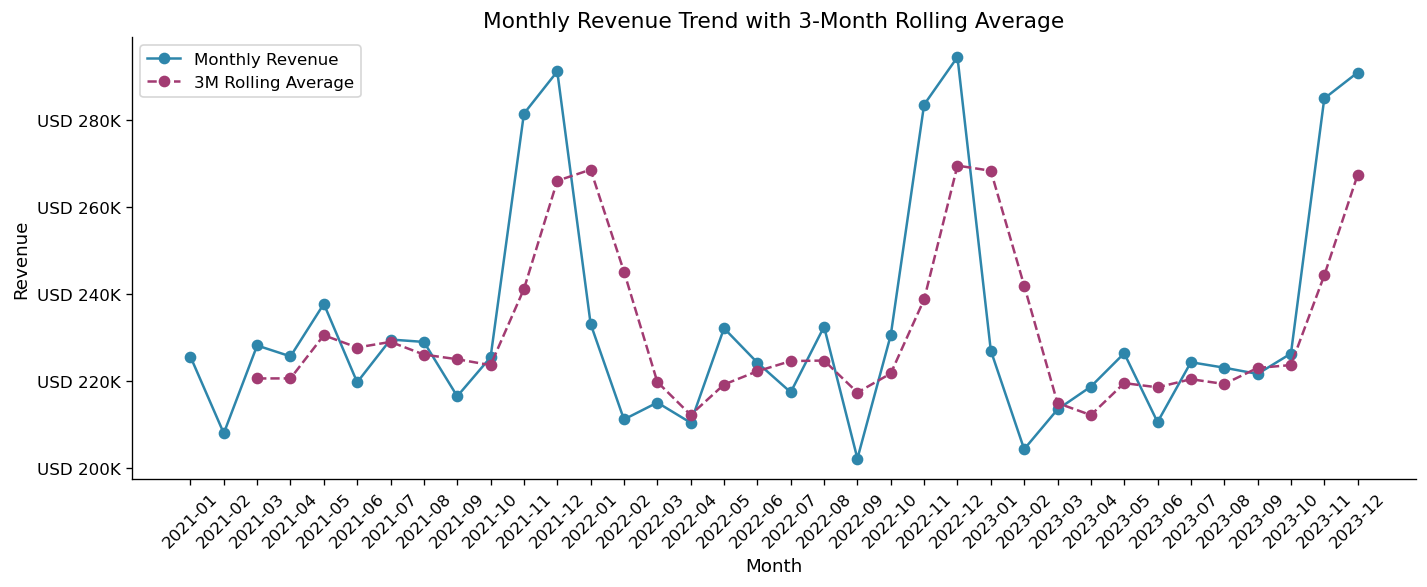

Saved: ../visuals/18_mom_revenue_growth.png


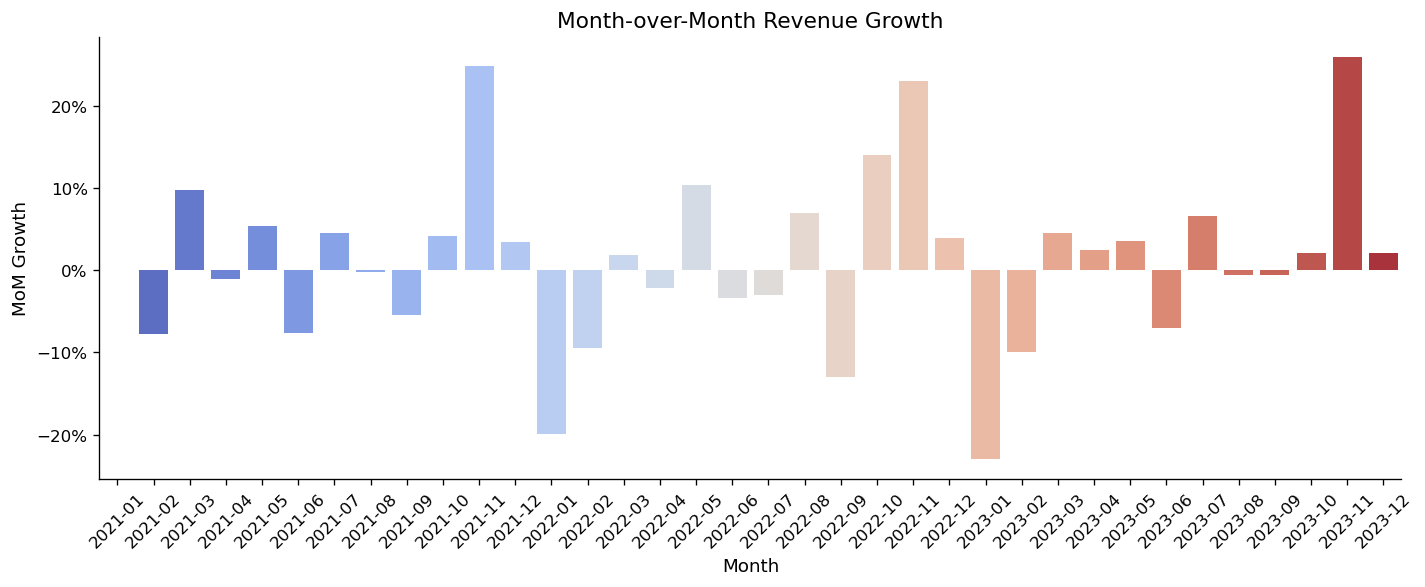

Saved: ../visuals/19_revenue_by_day_of_week.png


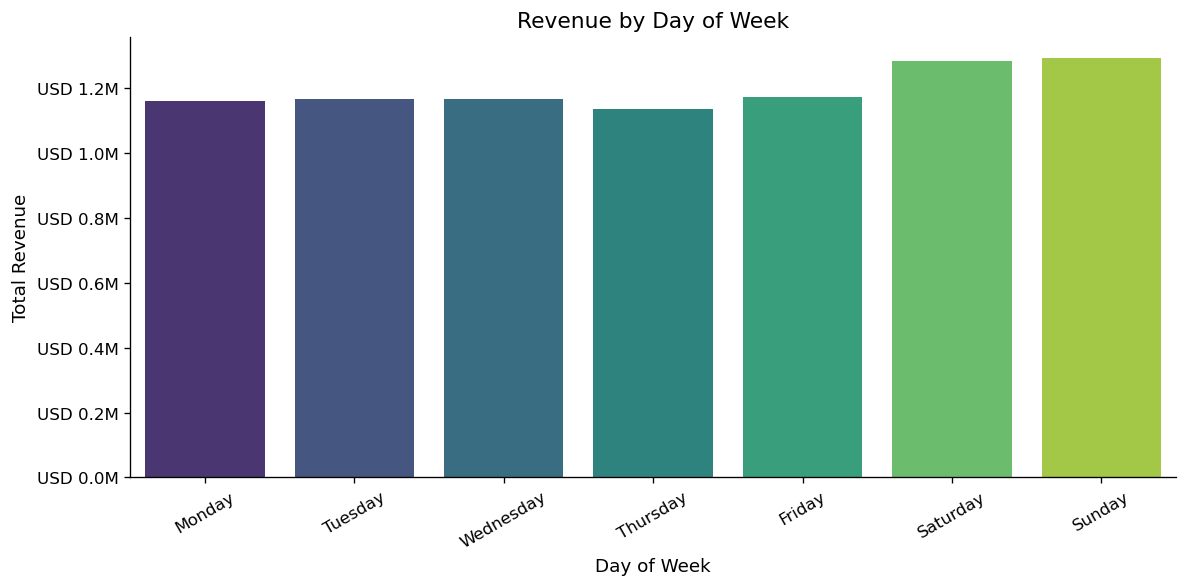

Saved: ../visuals/20_quarterly_revenue_trend.png


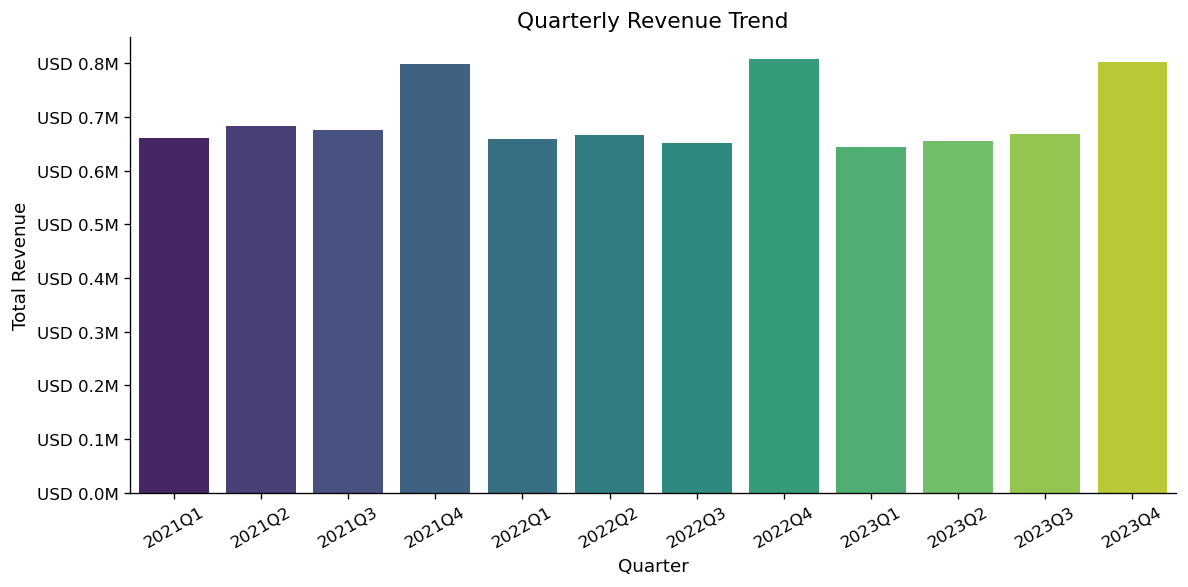


Export complete.
20 visuals saved to: /Users/emmatrapp/Desktop/marketing-analytics/visuals
- 01_kpi_dashboard.png
- 02_yoy_business_performance.png
- 03_campaign_revenue_by_channel.png
- 04_campaign_revenue_by_objective.png
- 05_expected_uplift_vs_actual_revenue.png
- 06_acquisition_channel_comparison.png
- 07_loyalty_tier_mix_by_channel.png
- 08_purchase_funnel_event_volume.png
- 09_device_funnel_heatmap.png
- 10_ab_test_conversion_rates.png
- 11_revenue_by_loyalty_tier.png
- 12_revenue_by_product_category.png
- 13_premium_vs_standard_aov.png
- 14_refund_rate_by_category.png
- 15_discount_depth_distribution.png
- 16_discounted_vs_full_price_aov.png
- 17_monthly_revenue_trend.png
- 18_mom_revenue_growth.png
- 19_revenue_by_day_of_week.png
- 20_quarterly_revenue_trend.png


In [58]:
# ============================================================
# Export Portfolio Visuals
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# Create visuals folder
visuals_dir = Path("../visuals")
visuals_dir.mkdir(parents=True, exist_ok=True)

print(f"Visuals will be saved to: {visuals_dir.resolve()}")


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def save_visual(filename):
    """
    Save the current matplotlib figure to the visuals folder.
    """
    filepath = visuals_dir / filename
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")


# ------------------------------------------------------------
# 1. KPI Dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("KPI Dashboard", fontsize=20, fontweight="bold", y=1.02)

kpis = [
    ("Total Revenue", f"USD {total_revenue:,.0f}", "#2E86AB"),
    ("Total Transactions", f"{total_transactions:,}", "#A23B72"),
    ("Avg Order Value", f"USD {avg_order_value:.2f}", "#F18F01"),
    ("Unique Customers", f"{unique_customers:,}", "#44BBA4"),
    ("Rev / Customer", f"USD {rev_per_customer:.2f}", "#2E86AB"),
    ("Repeat Rate", f"{repeat_rate_pct:.1f}%", "#A23B72"),
    ("Refund Rate", f"{refund_rate:.1f}%", "#C73E1D"),
    ("Discount Rate", f"{discount_rate:.1f}%", "#F18F01"),
]

for ax, (label, value, color) in zip(axes.flatten(), kpis):
    ax.set_facecolor("#F9F9F9")
    ax.text(
        0.5, 0.62, value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=color,
        transform=ax.transAxes
    )
    ax.text(
        0.5, 0.28, label,
        ha="center",
        va="center",
        fontsize=16,
        color="#555555",
        transform=ax.transAxes
    )
    ax.axis("off")

plt.tight_layout()
save_visual("01_kpi_dashboard.png")
plt.show()


# ------------------------------------------------------------
# 2. Year-over-Year Business Performance
# ------------------------------------------------------------

rev_by_year = (
    txn_full
    .groupby("year")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        transactions=("transaction_id", "count"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

charts = [
    ("total_revenue", "Total Revenue", "#2E86AB"),
    ("transactions", "Transactions", "#A23B72"),
    ("avg_order_value", "Average Order Value", "#F18F01"),
]

for ax, (col, label, color) in zip(axes, charts):
    bars = ax.bar(
        rev_by_year["year"].astype(str),
        rev_by_year[col],
        color=color,
        alpha=0.85,
        width=0.5
    )
    ax.set_title(label)
    ax.set_xlabel("Year")

    if col in ["total_revenue", "avg_order_value"]:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    for bar in bars:
        h = bar.get_height()
        label_text = f"USD {h:,.0f}" if col in ["total_revenue", "avg_order_value"] else f"{h:,.0f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + h * 0.01,
            label_text,
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle("YoY Business Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
save_visual("02_yoy_business_performance.png")
plt.show()


# ------------------------------------------------------------
# 3. Campaign Revenue by Channel
# ------------------------------------------------------------

campaign_channel = (
    transactions_clean[transactions_clean["campaign_id"] != 0]
    .merge(campaigns[["campaign_id", "channel"]], on="campaign_id", how="left")
    .groupby("channel")
    .agg(
        transactions=("transaction_id", "count"),
        total_revenue=("gross_revenue", "sum"),
        avg_order_value=("gross_revenue", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=campaign_channel,
    x="channel",
    y="total_revenue",
    palette="viridis"
)
plt.title("Attributed Campaign Revenue by Channel")
plt.xlabel("Campaign Channel")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("03_campaign_revenue_by_channel.png")
plt.show()


# ------------------------------------------------------------
# 4. Campaign Objective Revenue
# ------------------------------------------------------------

campaign_objective = (
    transactions_clean[transactions_clean["campaign_id"] != 0]
    .merge(campaigns[["campaign_id", "objective"]], on="campaign_id", how="left")
    .groupby("objective")
    .agg(
        transactions=("transaction_id", "count"),
        total_revenue=("gross_revenue", "sum"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=campaign_objective,
    x="objective",
    y="total_revenue",
    palette="magma"
)
plt.title("Campaign Revenue by Objective")
plt.xlabel("Campaign Objective")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("04_campaign_revenue_by_objective.png")
plt.show()


# ------------------------------------------------------------
# 5. Expected Uplift vs Actual Revenue
# ------------------------------------------------------------

campaign_performance = (
    transactions_clean[transactions_clean["campaign_id"] != 0]
    .merge(campaigns, on="campaign_id", how="left")
    .groupby(["campaign_id", "channel", "objective", "target_segment", "expected_uplift"])
    .agg(
        transactions=("transaction_id", "count"),
        total_revenue=("gross_revenue", "sum"),
        avg_order_value=("gross_revenue", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=campaign_performance,
    x="expected_uplift",
    y="total_revenue",
    hue="channel",
    size="transactions",
    sizes=(50, 400),
    alpha=0.8
)
plt.title("Expected Uplift vs. Actual Campaign Revenue")
plt.xlabel("Expected Uplift")
plt.ylabel("Total Revenue")
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000:.0f}K"))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_visual("05_expected_uplift_vs_actual_revenue.png")
plt.show()


# ------------------------------------------------------------
# 6. Acquisition Channel Comparison
# ------------------------------------------------------------

acquisition_perf = (
    txn_full
    .groupby("acquisition_channel")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        unique_customers=("customer_id", "nunique"),
        avg_order_value=("gross_revenue", "mean"),
        refund_rate=("refund_flag", "mean"),
        discount_rate=("discount_applied", lambda x: (x > 0).mean())
    )
    .reset_index()
)

customer_orders = txn_full.groupby("customer_id").size().reset_index(name="order_count")
customer_orders = customer_orders.merge(
    customers[["customer_id", "acquisition_channel"]],
    on="customer_id",
    how="left"
)

repeat_by_channel = (
    customer_orders
    .groupby("acquisition_channel")
    .agg(repeat_rate=("order_count", lambda x: (x > 1).mean()))
    .reset_index()
)

acquisition_perf = acquisition_perf.merge(repeat_by_channel, on="acquisition_channel", how="left")
acquisition_perf["revenue_per_customer"] = acquisition_perf["total_revenue"] / acquisition_perf["unique_customers"]

metrics = [
    ("total_revenue", "Total Revenue"),
    ("revenue_per_customer", "Revenue per Customer"),
    ("repeat_rate", "Repeat Purchase Rate"),
    ("refund_rate", "Refund Rate"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Acquisition Channel Performance", fontsize=16, fontweight="bold")

for ax, (metric, title) in zip(axes.flatten(), metrics):
    plot_data = acquisition_perf.sort_values(metric, ascending=False)

    sns.barplot(
        data=plot_data,
        x="acquisition_channel",
        y=metric,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

    if metric in ["total_revenue", "revenue_per_customer"]:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
save_visual("06_acquisition_channel_comparison.png")
plt.show()


# ------------------------------------------------------------
# 7. Loyalty Tier Mix by Acquisition Channel
# ------------------------------------------------------------

loyalty_mix = (
    customers
    .groupby(["acquisition_channel", "loyalty_tier"])
    .size()
    .reset_index(name="customers")
)

loyalty_mix["share"] = loyalty_mix.groupby("acquisition_channel")["customers"].transform(
    lambda x: x / x.sum()
)

loyalty_pivot = loyalty_mix.pivot(
    index="acquisition_channel",
    columns="loyalty_tier",
    values="share"
).fillna(0)

loyalty_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Loyalty Tier Mix by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Share of Customers")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=30)
plt.legend(title="Loyalty Tier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_visual("07_loyalty_tier_mix_by_channel.png")
plt.show()


# ------------------------------------------------------------
# 8. Full Funnel
# ------------------------------------------------------------

funnel_order = ["view", "click", "add_to_cart", "purchase"]

funnel = (
    events[events["event_type"].isin(funnel_order)]
    .groupby("event_type")
    .agg(events=("event_id", "count"), users=("customer_id", "nunique"))
    .reindex(funnel_order)
    .reset_index()
)

funnel["step_conversion_rate"] = funnel["events"] / funnel["events"].shift(1)
funnel["overall_conversion_rate"] = funnel["events"] / funnel["events"].iloc[0]
funnel["dropoff_rate"] = 1 - funnel["step_conversion_rate"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=funnel,
    x="event_type",
    y="events",
    palette="Blues_r"
)
plt.title("Purchase Funnel by Event Volume")
plt.xlabel("Funnel Stage")
plt.ylabel("Event Count")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K"))
plt.tight_layout()
save_visual("08_purchase_funnel_event_volume.png")
plt.show()


# ------------------------------------------------------------
# 9. Device-Level Funnel Heatmap
# ------------------------------------------------------------

device_funnel = (
    events[events["event_type"].isin(funnel_order)]
    .groupby(["device_type", "event_type"])
    .size()
    .reset_index(name="events")
)

device_funnel["event_type"] = pd.Categorical(
    device_funnel["event_type"],
    categories=funnel_order,
    ordered=True
)

device_pivot = device_funnel.pivot(
    index="device_type",
    columns="event_type",
    values="events"
).fillna(0)

device_rates = device_pivot.div(device_pivot["view"], axis=0)

plt.figure(figsize=(10, 5))
sns.heatmap(
    device_rates,
    annot=True,
    fmt=".1%",
    cmap="Blues"
)
plt.title("Device-Level Funnel Conversion Relative to Views")
plt.xlabel("Funnel Stage")
plt.ylabel("Device Type")
plt.tight_layout()
save_visual("09_device_funnel_heatmap.png")
plt.show()


# ------------------------------------------------------------
# 10. A/B Test Conversion Rates
# ------------------------------------------------------------

experiment_summary = (
    events
    .groupby("experiment_group")
    .agg(
        users=("customer_id", "nunique"),
        purchases=("event_type", lambda x: (x == "purchase").sum())
    )
    .reset_index()
)

experiment_summary["conversion_rate"] = experiment_summary["purchases"] / experiment_summary["users"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=experiment_summary.sort_values("conversion_rate", ascending=False),
    x="experiment_group",
    y="conversion_rate",
    palette="viridis"
)
plt.title("Purchase Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
save_visual("10_ab_test_conversion_rates.png")
plt.show()


# ------------------------------------------------------------
# 11. Customer Segmentation: Revenue by Loyalty Tier
# ------------------------------------------------------------

loyalty_perf = (
    txn_full
    .groupby("loyalty_tier")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        unique_customers=("customer_id", "nunique"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=loyalty_perf,
    x="loyalty_tier",
    y="total_revenue",
    palette="viridis"
)
plt.title("Revenue by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.tight_layout()
save_visual("11_revenue_by_loyalty_tier.png")
plt.show()


# ------------------------------------------------------------
# 12. Product Category Performance
# ------------------------------------------------------------

category_perf = (
    txn_full
    .groupby("category")
    .agg(
        transactions=("transaction_id", "count"),
        total_revenue=("gross_revenue", "sum"),
        avg_order_value=("gross_revenue", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=category_perf,
    x="category",
    y="total_revenue",
    palette="viridis"
)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("12_revenue_by_product_category.png")
plt.show()


# ------------------------------------------------------------
# 13. Premium vs Standard Product Performance
# ------------------------------------------------------------

premium_perf = (
    txn_full
    .groupby("is_premium")
    .agg(
        transactions=("transaction_id", "count"),
        total_revenue=("gross_revenue", "sum"),
        avg_order_value=("gross_revenue", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

premium_perf["product_type"] = premium_perf["is_premium"].map({
    0: "Standard",
    1: "Premium"
})

plt.figure(figsize=(7, 5))
sns.barplot(
    data=premium_perf,
    x="product_type",
    y="avg_order_value",
    palette="magma"
)
plt.title("Average Order Value: Premium vs. Standard Products")
plt.xlabel("Product Type")
plt.ylabel("Average Order Value")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x:,.0f}"))
plt.tight_layout()
save_visual("13_premium_vs_standard_aov.png")
plt.show()


# ------------------------------------------------------------
# 14. Refund Rate by Category
# ------------------------------------------------------------

refund_by_category = (
    txn_full
    .groupby("category")
    .agg(
        transactions=("transaction_id", "count"),
        refund_rate=("refund_flag", "mean"),
        total_revenue=("gross_revenue", "sum")
    )
    .reset_index()
    .sort_values("refund_rate", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=refund_by_category,
    x="category",
    y="refund_rate",
    palette="Reds_r"
)
plt.title("Refund Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Refund Rate")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("14_refund_rate_by_category.png")
plt.show()


# ------------------------------------------------------------
# 15. Discount Depth Distribution
# ------------------------------------------------------------

discounted_orders = txn_full[txn_full["discount_applied"] > 0].copy()

plt.figure(figsize=(8, 5))
sns.histplot(
    discounted_orders["discount_applied"],
    bins=10,
    kde=False
)
plt.title("Discount Depth Distribution")
plt.xlabel("Discount Applied")
plt.ylabel("Transaction Count")
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
save_visual("15_discount_depth_distribution.png")
plt.show()


# ------------------------------------------------------------
# 16. Discounted vs Full-Price AOV
# ------------------------------------------------------------

txn_full["discount_status"] = np.where(
    txn_full["discount_applied"] > 0,
    "Discounted",
    "Full Price"
)

discount_aov = (
    txn_full
    .groupby("discount_status")
    .agg(
        transactions=("transaction_id", "count"),
        avg_order_value=("gross_revenue", "mean"),
        total_revenue=("gross_revenue", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=discount_aov,
    x="discount_status",
    y="avg_order_value",
    palette="viridis"
)
plt.title("Average Order Value: Discounted vs. Full-Price Orders")
plt.xlabel("Order Type")
plt.ylabel("Average Order Value")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x:,.0f}"))
plt.tight_layout()
save_visual("16_discounted_vs_full_price_aov.png")
plt.show()


# ------------------------------------------------------------
# 17. Monthly Revenue Trend with 3M Rolling Average
# ------------------------------------------------------------

monthly_revenue = (
    txn_full
    .groupby("month_str")
    .agg(
        monthly_revenue=("gross_revenue", "sum"),
        transactions=("transaction_id", "count"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reset_index()
    .sort_values("month_str")
)

monthly_revenue["rolling_3m_revenue"] = monthly_revenue["monthly_revenue"].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue["month_str"],
    monthly_revenue["monthly_revenue"],
    marker="o",
    label="Monthly Revenue"
)
plt.plot(
    monthly_revenue["month_str"],
    monthly_revenue["rolling_3m_revenue"],
    marker="o",
    linestyle="--",
    label="3M Rolling Average"
)
plt.title("Monthly Revenue Trend with 3-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000:.0f}K"))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
save_visual("17_monthly_revenue_trend.png")
plt.show()


# ------------------------------------------------------------
# 18. Month-over-Month Revenue Growth
# ------------------------------------------------------------

monthly_revenue["mom_growth"] = monthly_revenue["monthly_revenue"].pct_change()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=monthly_revenue,
    x="month_str",
    y="mom_growth",
    palette="coolwarm"
)
plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("MoM Growth")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
save_visual("18_mom_revenue_growth.png")
plt.show()


# ------------------------------------------------------------
# 19. Revenue by Day of Week
# ------------------------------------------------------------

dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_revenue = (
    txn_full
    .groupby("day_of_week")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        transactions=("transaction_id", "count"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reindex(dow_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dow_revenue,
    x="day_of_week",
    y="total_revenue",
    palette="viridis"
)
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("19_revenue_by_day_of_week.png")
plt.show()


# ------------------------------------------------------------
# 20. Quarterly Revenue Trend
# ------------------------------------------------------------

quarterly_revenue = (
    txn_full
    .groupby("quarter")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        transactions=("transaction_id", "count"),
        avg_order_value=("gross_revenue", "mean")
    )
    .reset_index()
    .sort_values("quarter")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=quarterly_revenue,
    x="quarter",
    y="total_revenue",
    palette="viridis"
)
plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"USD {x/1_000_000:.1f}M"))
plt.xticks(rotation=30)
plt.tight_layout()
save_visual("20_quarterly_revenue_trend.png")
plt.show()


# ------------------------------------------------------------
# Export Summary
# ------------------------------------------------------------

saved_files = sorted(visuals_dir.glob("*.png"))

print("\nExport complete.")
print(f"{len(saved_files)} visuals saved to: {visuals_dir.resolve()}")

for file in saved_files:
    print(f"- {file.name}")

In [59]:
from pathlib import Path

# Create output folders
sql_dir = Path("../sql")
visuals_dir = Path("../visuals")

sql_dir.mkdir(parents=True, exist_ok=True)
visuals_dir.mkdir(parents=True, exist_ok=True)

print("Folders created:")
print(sql_dir.resolve())
print(visuals_dir.resolve())

Folders created:
/Users/emmatrapp/Desktop/marketing-analytics/sql
/Users/emmatrapp/Desktop/marketing-analytics/visuals


In [60]:
sql_queries = {
    "01_headline_kpis.sql": """
SELECT
    COUNT(*) AS total_transactions,
    ROUND(SUM(gross_revenue), 2) AS total_revenue,
    ROUND(AVG(gross_revenue), 2) AS avg_order_value,
    COUNT(DISTINCT customer_id) AS unique_customers,
    SUM(CASE WHEN refund_flag = 1 THEN 1 ELSE 0 END) AS refund_count,
    ROUND(100.0 * SUM(refund_flag) / COUNT(*), 2) AS refund_rate_pct,
    ROUND(
        100.0 * SUM(CASE WHEN discount_applied > 0 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS discount_rate_pct
FROM transactions_clean;
""",

    "02_revenue_by_channel.sql": """
SELECT
    c.channel,
    COUNT(DISTINCT t.transaction_id) AS transactions,
    ROUND(SUM(t.gross_revenue), 2) AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2) AS avg_order_value,
    ROUND(100.0 * SUM(t.refund_flag) / COUNT(*), 2) AS refund_rate_pct
FROM transactions_clean t
JOIN campaigns c 
    ON t.campaign_id = c.campaign_id
GROUP BY c.channel
ORDER BY total_revenue DESC;
""",

    "03_top_10_campaigns.sql": """
SELECT
    t.campaign_id,
    c.channel,
    c.objective,
    c.target_segment,
    COUNT(*) AS transactions,
    ROUND(SUM(t.gross_revenue), 2) AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2) AS avg_order_value,
    ROUND(c.expected_uplift * 100, 1) AS expected_uplift_pct
FROM transactions_clean t
JOIN campaigns c 
    ON t.campaign_id = c.campaign_id
WHERE t.campaign_id != 0
GROUP BY 
    t.campaign_id,
    c.channel,
    c.objective,
    c.target_segment,
    c.expected_uplift
ORDER BY total_revenue DESC
LIMIT 10;
""",

    "04_revenue_by_loyalty_tier.sql": """
SELECT
    cust.loyalty_tier,
    COUNT(DISTINCT t.customer_id) AS unique_customers,
    COUNT(*) AS transactions,
    ROUND(SUM(t.gross_revenue), 2) AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2) AS avg_order_value,
    ROUND(SUM(t.gross_revenue) / COUNT(DISTINCT t.customer_id), 2) AS revenue_per_customer
FROM transactions_clean t
JOIN customers cust 
    ON t.customer_id = cust.customer_id
GROUP BY cust.loyalty_tier
ORDER BY revenue_per_customer DESC;
""",

    "05_funnel_conversion_rates.sql": """
SELECT
    event_type,
    COUNT(*) AS event_count,
    ROUND(
        100.0 * COUNT(*) / (
            SELECT COUNT(*) 
            FROM events 
            WHERE event_type = 'view'
        ),
        2
    ) AS pct_of_views
FROM events
GROUP BY event_type
ORDER BY event_count DESC;
""",

    "06_category_performance.sql": """
SELECT
    p.category,
    COUNT(*) AS transactions,
    ROUND(SUM(t.gross_revenue), 2) AS total_revenue,
    ROUND(AVG(t.gross_revenue), 2) AS avg_order_value,
    ROUND(AVG(t.discount_applied) * 100, 2) AS avg_discount_pct,
    ROUND(100.0 * SUM(t.refund_flag) / COUNT(*), 2) AS refund_rate_pct
FROM transactions_clean t
JOIN products p 
    ON t.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC;
""",

    "07_monthly_revenue_trend.sql": """
SELECT
    month_str,
    COUNT(*) AS transactions,
    ROUND(SUM(gross_revenue), 2) AS monthly_revenue,
    ROUND(AVG(gross_revenue), 2) AS avg_order_value
FROM transactions_clean
GROUP BY month_str
ORDER BY month_str;
"""
}

In [61]:
for filename, query in sql_queries.items():
    file_path = sql_dir / filename
    
    with open(file_path, "w") as f:
        f.write(query.strip())

print(f"Saved {len(sql_queries)} SQL files to {sql_dir}")

Saved 7 SQL files to ../sql
